# Machine Learning - theory

### Czysta Teoria ML - techniczno-teoretyczna

Regresja liniowa – co to jest?

Regresja liniowa to metoda przewidywania jednej zmiennej (np. ceny auta) na podstawie innych zmiennych (np. wieku, przebiegu, marki).

Model ma postać: y = a + $b_1x_1$ + $b_2x_2$ + ... + $b_nx_n$

Czyli: prosta zależność liniowa między cechami a przewidywaną wartością.

-----------------------------

OLS:

1. Mamy punkty danych (np. przebieg vs cena auta).

2. Chcemy narysować linię, która najlepiej przechodzi przez punkty.

3. OLS liczy, jak duży jest błąd między:

- wartością rzeczywistą

- wartością przewidywaną przez linię

Dla każdego punktu liczony jest błąd:

$błąd_i$ = $y_i$ - $\hat{y}_i$

Ale:

OLS nie sumuje błędów, tylko sumę ich kwadratów:

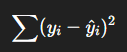
    
Kwadratowanie błędów powoduje, że:

- błędy dodatnie i ujemne się nie znoszą,

- duże błędy są mocniej karane.

OLS wybiera takie współczynniki (a, b), które minimalizują tę sumę.

-----------------------------

**Funkcje: straty, kosztu, celu**

1. Loss Function (Funkcja Straty) – Błąd na JEDNYM przykładzie

Funkcja straty oblicza błąd tylko dla pojedynczego wiersza w danych (jednego rekordu, jednego zdjęcia, jednego klienta).

- Pytanie, na które odpowiada: "Jak bardzo pomyliłem się przy przewidywaniu ceny tego konkretnego domu?"

- Zapis matematyczny: Zazwyczaj oznaczana jako $L$. Na przykład błąd kwadratowy dla jednego domu to po prostu:

![alt text](image.png)

2. Cost Function (Funkcja Kosztu) – Błąd na CAŁYM zbiorze

Funkcja kosztu to po prostu średnia (lub suma) wszystkich Funkcji Straty z całego zbioru treningowego.

- Pytanie, na które odpowiada: "Jak bardzo mój model myli się średnio na wszystkich 10 000 domów w zbiorze treningowym?"

- Zapis matematyczny: Zazwyczaj oznaczana jako $J$. To jest to MSE, o którym rozmawialiśmy wcześniej!

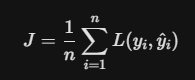

To właśnie Funkcję Kosztu algorytm stara się zminimalizować podczas treningu (np. zjeżdżając na dno "miski" za pomocą algorytmu Gradient Descent).

3. Objective Function (Funkcja Celu) – Całkowity cel modelu

To jest najszersze pojęcie. Funkcja Celu to ostateczny wzór, który model optymalizuje. Najczęściej jest to Funkcja Kosztu + Regularizacja (kary za to, że model staje się zbyt skomplikowany i grozi mu przeuczenie).Pytanie, na które odpowiada: "Jak zminimalizować błąd na całym zbiorze, ale jednocześnie upewnić się, że model pozostanie prosty i nie nauczy się danych na pamięć?"Zapis matematyczny:

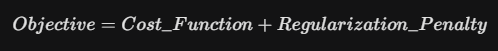

---

**Metryki - jakie, co opisują, kiedy je stosujemy**

1. Metryki Regresji (Przewidywanie wartości ciągłych)

W regresji model wypluwa konkretną liczbę. Chcemy wiedzieć, jak bardzo ta liczba różni się od rzeczywistości.

- MAE (Mean Absolute Error - Średni Błąd Bezwzględny):

    - Czym jest: Po prostu średnia z różnic między przewidywaniem a prawdą. Jeśli pomylisz się o 10 zł i o 20 zł, średni błąd to 15 zł. Wzór to
        $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$.
    
    - Kiedy stosować: Kiedy chcesz intuicyjnego wyniku i nie zależy Ci na mocnym karaniu modelu za pojedyncze, duże błędy (outliery). Dobry do prognozowania cen w standardowych warunkach.

- MSE (Mean Squared Error - Błąd Średniokwadratowy):

    - Czym jest: Różnice między przewidywaniem a prawdą są podnoszone do kwadratu przed wyciągnięciem średniej:

        $MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$.
    
    - Kiedy stosować: Kiedy duży błąd jest drastycznie gorszy niż mały. Na przykład w sterowaniu ramieniem robota – pomyłka o 1 mm jest ok, ale o 10 mm może zniszczyć sprzęt. Podniesienie do kwadratu sprawia, że model panicznie boi się dużych pomyłek.

- RMSE (Root Mean Squared Error - Pierwiastek z MSE):

    - Czym jest: To po prostu spierwiastkowane MSE.

    Kiedy stosować: Zawsze wtedy, gdy potrzebujesz zalet MSE (karanie za duże błędy), ale chcesz, żeby wynik był czytelny w oryginalnych jednostkach. MSE z ceny w złotówkach da "złotówki do kwadratu" (co jest bez sensu), a RMSE da po prostu złotówki.

2. Metryki Klasyfikacji (Szybkie uporządkowanie)

Dla przypomnienia i zebrania w jednym miejscu:

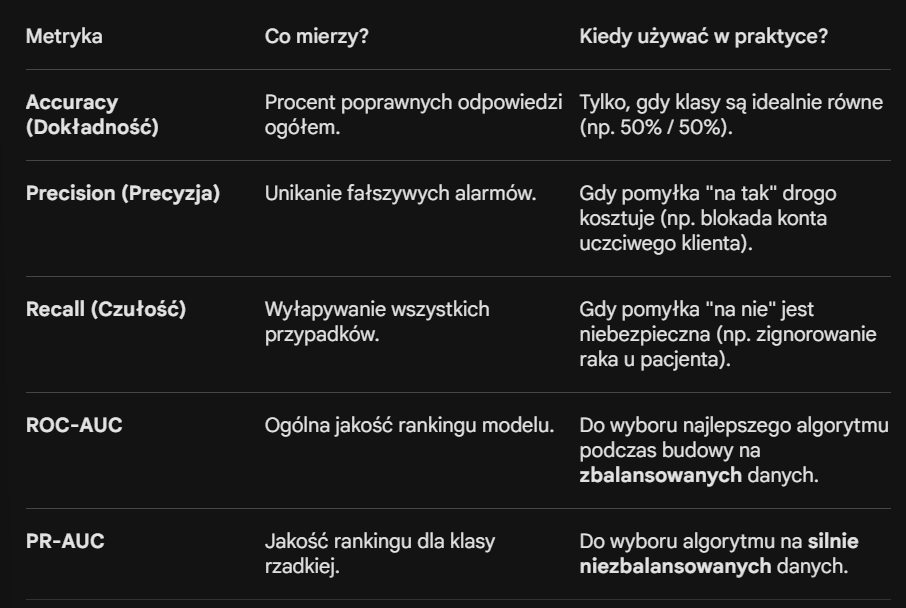

3. Co zrobić, gdy masz niezbalansowane dane?
Sama zmiana metryki (np. patrzenie na PR-AUC zamiast Accuracy) pozwala Ci tylko uczciwie ocenić problem, ale go nie rozwiązuje. Aby pomóc modelowi fizycznie nauczyć się rzadkiej klasy (np. 1% oszustw i 99% legalnych operacji), musisz zainterweniować.

Oto konkretne kroki i sytuacje:

A. Zastosuj Wagi Klas (Class Weights)
To najprostsza i często najskuteczniejsza metoda. W większości algorytmów (jak Random Forest czy XGBoost) możesz ustawić parametr, który każe modelowi zwracać większą uwagę na rzadką klasę. Model za pominięcie rzadkiego przypadku dostanie np. 100 razy większą "karę" niż za błąd na klasie dominującej.

Kiedy stosować: To powinien być Twój pierwszy krok. Działa świetnie przy proporcjach rzędu 1:10 czy 1:100. Nie wymaga zmieniania samego zbioru danych.

B. Generowanie sztucznych danych (Oversampling / SMOTE)
Technika SMOTE (Synthetic Minority Over-sampling Technique) bierze Twoje rzadkie przypadki i tworzy ich matematyczne klony (hybrydy), aby wyrównać proporcje do 50/50 przed treningiem.

Kiedy stosować: Gdy klas rzadkich jest tak mało, że model nie potrafi wyłapać żadnego wzorca, a wagi klas nie pomagają.

C. Obcięcie nadmiaru danych (Undersampling)
Losowo wyrzucasz część danych z dominującej klasy, aż zrównają się ilościowo z klasą rzadką.

Kiedy stosować: Masz miliony wierszy w bazie danych i trening modelu trwa wieczność. Wyrzucenie nadmiaru "zwykłych" przypadków przyspieszy naukę i wyrówna klasy. Wady? Tracisz dużo cennych informacji.

D. Zmiana podejścia: Detekcja Anomalii
Jeśli Twoja klasa pozytywna to 0.01% (np. ataki hakerskie na serwer), standardowa klasyfikacja zawiedzie.

Kiedy stosować: Gdy klasa jest ekstremalnie rzadka. Używasz wtedy algorytmów takich jak Isolation Forest lub One-Class SVM. Model uczy się tylko tego, jak wygląda "norma" (np. normalny ruch sieciowy), a wszystko, co od niej mocno odbiega, oflagowuje jako potencjalny atak.

**CO TO JEST GRADIENT DESCENT?**

Gradient Descent to algorytm uczenia, który służy do znajdowania minimum funkcji — czyli najlepszych 
parametrów modelu (np. regresji liniowej: $\beta_0$, $\beta_1$, itd.) 

W uczeniu maszynowym minimalizujemy funkcję kosztu (np. MSE).
Gradient Descent powoli “schodzi” po powierzchni funkcji aż znajdzie minimum.

Przykład:

$\alpha$ - wielkośc kroku

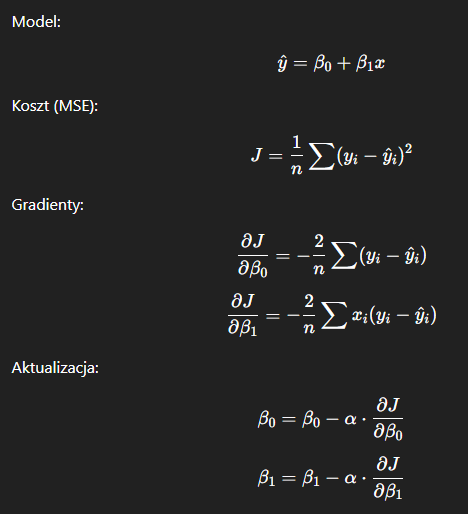

--------------------

BETA to współczynnik przy zmiennej w modelu regresji.
Określa kierunek i siłę wpływu cechy na wynik modelu.
W regresji liniowej beta mówi, o ile zmieni się y przy wzroście cechy o 1.
W regresji logistycznej opisuje wpływ cechy na log-odds, a exp(beta) interpretuje się jako zmianę szans.

✔ Interpretacja:

β > 0 → cecha zwiększa wartość y

β < 0 → cecha zmniejsza wartość y

β = 0 → cecha nie ma wpływu

✔ Przykład:

β1 = 2.5
→ wzrost x1 o 1 jednostkę zwiększa y średnio o 2.5 jednostki.

-----------------------

1. Supervised Learning (uczenie nadzorowane)

Model uczy się na danych, które mają etykiety (y).

Czyli mamy:

X -> cechy (np. wiek, cena, liczba pokoi)

y -> etykietę / odpowiedź (np. cena domu, czy klient odejdzie)

Model uczy się przewidywać y na podstawie X.

Typy supervised learning:
A) Regresja — kiedy y jest liczbą ciągłą

Przykłady:

- przewidywanie ceny domu

- przewidywanie zużycia energii

- estymacja popytu

- przewidywanie temperatury

Typowe modele:

- Linear Regression

- Random Forest Regressor

- Gradient Boosting

- Neural Networks


2. Unsupervised Learning (uczenie nienadzorowane)

Brak etykiet (brak y).
Model ma tylko zestaw danych X i sam szuka struktury.

Typy unsupervised learning:
A) Klasteryzacja

Model grupuje podobne obiekty.

Przykłady:

- segmentacja klientów (marketing)

- grupowanie dokumentów

- wykrywanie podobnych produktów

Modele:

- K-Means

- DBSCAN

- Hierarchical Clustering

B) Redukcja wymiarów

Ściśnianie danych, wizualizacja, “feature extraction”.

Przykłady:

- PCA

- t-SNE

- UMAP

C) Wykrywanie anomalii

Model uczy się “co jest normalne” i wykrywa odchylenia.

Przykłady:

- fraud detection

- wykrywanie błędów czujników

- wykrywanie nienormalnych transakcji


Podsumowanie:

Supervised learning używa danych z etykietami (X → y), np. klasyfikacja lub regresja.
Unsupervised learning nie ma etykiet — model sam szuka struktur, np. klastery czy PCA.

-------------------

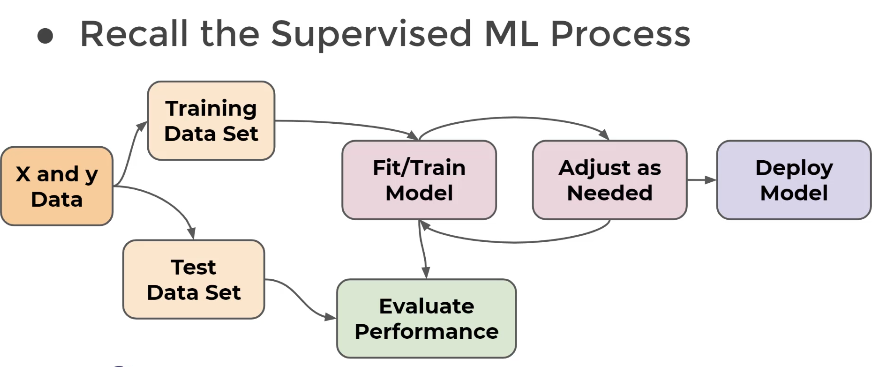

Polynomial Regression (regresja wielomianowa) to model regresji, który dopasowuje krzywą, a nie prostą linię, aby lepiej uchwycić zależność między zmienną X a y.

To rozszerzenie regresji liniowej — ale zamiast:

y = $\beta_0$ + $\beta_1$x

używa wielomianów, np. stopnia 2, 3, 4 itp.

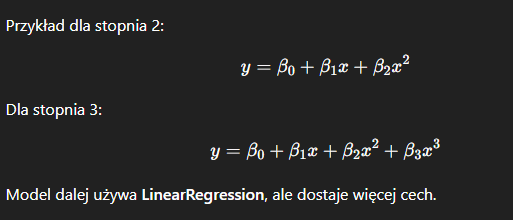

Kiedy jej używać?

- ✅ gdy dane mają nieliniowy trend
- ✅ gdy wykres X vs y wygląda jak krzywa
- ✅ przy zjawiskach fizycznych (np. czas, przyspieszenie)
- ✅ gdy model liniowy wyraźnie nie wystarcza

-------------------

Underfitting i Overfitting — najprościej jak się da
✅ UNDERFITTING (niedouczenie)

Model jest zbyt prosty i nie potrafi nauczyć się zależności w danych.

🔍 Objawy:

- słabe wyniki na danych treningowych,

- jeszcze gorsze na testowych,

- model „nie łapie” wzorców.

🧠 Metafora:

Uczeń zobaczył materiał, ale go nie zrozumiał i robi podstawowe błędy.

🔧 Typowe przyczyny:

model zbyt prosty (np. regresja liniowa do danych nieliniowych),

- za mało epok treningu,

- zbyt mocna regularizacja.

✅ OVERFITTING (przeuczenie)

Model jest zbyt skomplikowany i uczy się pamiętać dane, zamiast rozumieć ogólne zasady.

🔍 Objawy:

- świetne wyniki na danych treningowych,

- słabe wyniki na testowych,

- model reaguje „za bardzo” na przypadkowy szum.

🧠 Metafora:

Uczeń nauczył się na pamięć odpowiedzi z klucza, ale nie umie rozwiązać nowych zadań.

🔧 Typowe przyczyny:

- zbyt skomplikowany model (głęboka sieć, duże drzewo),

- za dużo epok,

- za mało danych,

---------------------

**Bias, Variance, Tradeoff**

1. Intuicja: Strzelnica: Wyobraź sobie łucznika, który oddaje serię strzałów:

Bias (Błąd systematyczny): To sytuacja, w której łucznik ma źle skalibrowany celownik. Wszystkie strzały
lądują blisko siebie, ale daleko od środka (np. zawsze w lewym górnym rogu). Model jest zbyt prosty, 
ma błędne założenia – to nazywamy Underfittingiem (niedouczeniem).

Variance (Wariancja): Łucznik ma świetny wzrok, ale trzęsą mu się ręce. Średnio trafia blisko środka, 
ale rozrzut jest ogromny. Strzały są wszędzie. Model jest zbyt czuły na szum w danych treningowych – 
to nazywamy Overfittingiem (przeuczeniem).

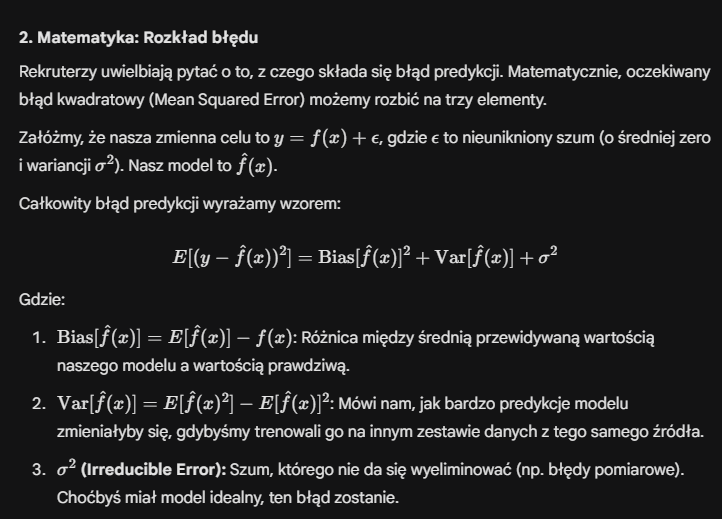

2. Tradeoff: Złoty środek
Problem polega na tym, że gdy próbujesz zmniejszyć Bias (używasz bardziej skomplikowanego modelu, np. głębszego drzewa), to zazwyczaj automatycznie rośnie Wariancja. I na odwrót.

Modele o niskiej złożoności (np. Regresja Liniowa): Wysoki Bias, Niska Wariancja. Są stabilne, ale często zbyt "sztywne", by wyłapać trendy.

Modele o wysokiej złożoności (np. Głęokie Sieci Neuronowe, KNN z k=1): Niski Bias, Wysoka Wariancja. Są bardzo elastyczne, ale "wariują" przy małej zmianie danych.

Jeśli Twój model ma słabe wyniki, musisz wiedzieć, w którą stronę iść:

- Masz High Bias (Underfitting)?

- Dodaj więcej cech (features).

- Użyj bardziej złożonego algorytmu (np. zamiast Regresji Liniowej – XGBoost).

- Zmniejsz regularyzację (L1/L2).

Masz High Variance (Overfitting)?

- Zdobądź więcej danych treningowych.

- Zastosuj regularyzację.

- Zmniejsz liczbę cech (Feature Selection).

Zastosuj Ensembling (np. Random Forest świetnie redukuje wariancję poprzez uśrednianie wyników wielu drzew).

---

**Dodatkowe pytania**

1. Dlaczego Bagging zmniejsza Wariancję?
(Przykład: Random Forest)

W Baggingu (Bootstrap Aggregating) używamy zazwyczaj silnych, głębokich drzew decyzyjnych.

Problem: Głębokie drzewa mają bardzo niski Bias (świetnie dopasowują się do danych), ale potężną Wariancję (mała zmiana w danych treningowych całkowicie zmienia strukturę drzewa).

Mechanizm: Bagging tworzy wiele takich "roztrzęsionych" drzew na różnych podzbiorach danych (bootstrap). Ponieważ każde drzewo widzi nieco inne dane, każde z nich "myli się" w nieco inny sposób i w innych miejscach.

Efekt: Kiedy uśredniamy ich wyniki (głosowanie), błędy losowe poszczególnych drzew (wariancja) wzajemnie się znoszą. Średnia z wielu niezależnych zmiennych losowych ma znacznie mniejszą wariancję niż pojedyncza zmienna.

2. Dlaczego Boosting zmniejsza Bias?
(Przykład: XGBoost, AdaBoost)

W Boostingu sytuacja jest odwrotna. Zaczynamy zazwyczaj od słabych modeli (Weak Learners), np. bardzo płytkich drzew (tzw. stumps), które mają wysoki Bias (są zbyt proste, by zrozumieć dane).

Mechanizm: Modele są budowane sekwencyjnie (jeden po drugim). Każde kolejne drzewo ma za zadanie "naprawić" to, co zepsuł jego poprzednik. W Gradient Boostingu kolejne drzewo uczy się przewidywać rezydua (różnicę między wartością prawdziwą a obecną predykcją zestawu).

Efekt: Z każdym krokiem nasza suma predykcji coraz bardziej zbliża się do wartości rzeczywistych. Systematycznie redukujemy błąd wynikający z uproszczeń modelu (Bias), "dopychając" wynik do celu.

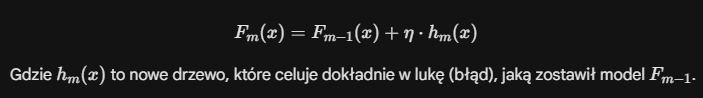

---

**Ensemble Learning i jego rodzaje**

Ensemble Learning (Uczenie Zespołowe) to potężna koncepcja, która opiera się na jednej prostej życiowej prawdzie: mądrości tłumu.

Zamiast szukać jednego, idealnego algorytmu, który rozwiąże cały Twój problem (co jest zazwyczaj niemożliwe), tworzysz grupę "ekspertów" (różnych modeli) i każesz im współpracować. Nawet jeśli każdy z ekspertów jest dość słaby i myli się w pewnych kwestiach, to ich uśredniony, wspólny głos jest niemal zawsze dokładniejszy i stabilniejszy niż głos najlepszego pojedynczego modelu.

Podzielmy Ensemble Learning na wszystkie jego główne rodziny.

1. Bagging (Bootstrap Aggregating) – "Burza mózgów"
W podejściu Bagging budujemy wiele modeli tego samego typu (np. same drzewa decyzyjne) całkowicie niezależnie i równolegle.

Jak to działa: Ponieważ nie ma sensu trenować 100 identycznych drzew na tych samych danych (dałyby ten sam wynik), używamy techniki zwanej Bootstrap. Polega ona na tym, że dla każdego z 100 drzew losujemy (ze zwracaniem) nieco inny podzbiór danych treningowych. Każde drzewo widzi świat z trochę innej perspektywy. Następnie wszystkie drzewa głosują, a my bierzemy średnią (lub większość głosów).

Główny cel: Redukcja wariancji (zabezpieczenie przed przeuczeniem / overfittingiem).

Najsłynniejszy algorytm: Random Forest (Las Losowy). Idzie on o krok dalej – losuje nie tylko rzędy danych, ale też kolumny (cechy) przy każdym podziale drzewa, aby modele były od siebie jak najbardziej niezależne.

2. Boosting – "Nauka na błędach"
To zupełne przeciwieństwo Baggingu. Zamiast budować modele niezależnie, budujemy je sekwencyjnie (jeden po drugim).

Jak to działa: Trenujemy pierwszy, bardzo prosty model. Sprawdzamy, gdzie popełnił błędy. Następnie budujemy drugi model, ale celowo zmuszamy go, aby skupił się przede wszystkim na tych przypadkach, z którymi pierwszy model sobie nie poradził (nadając im większe wagi). Trzeci model naprawia błędy drugiego, i tak dalej. Na koniec sumujemy ich wyniki.

Główny cel: Redukcja obciążenia (biasu) – tworzenie z bardzo słabych modeli (tzw. weak learners) jednego, ekstremalnie potężnego algorytmu.

Najsłynniejsze algorytmy: XGBoost, LightGBM, CatBoost, AdaBoost. To one dominują w dzisiejszych konkursach Data Science na danych tabelarycznych.

3. Stacking (Złożenie) – Budowanie hierarchii modeli
Stacking to bardzo sprytna architektura. Nie uśredniasz w niej po prostu wyników w ciemno. Używasz uczenia maszynowego do tego, aby dowiedzieć się, komu warto ufać w jakich sytuacjach.

Architektura Stackingu dzieli się na dwa poziomy:

Poziom 0 (Base Models / Modele Bazowe): Trenujesz zestaw zupełnie różnych algorytmów. Na przykład: jedno Drzewo Losowe, jedną Maszynę Wektorów Nośnych (SVM) i jedną sieć neuronową. Każdy z nich "patrzy" na dane z innej matematycznej perspektywy.

Poziom 1 (Meta-Model): Wprowadzasz nowy, nadrzędny model (zazwyczaj coś bardzo prostego, np. Regresję Logistyczną). Ten model nie patrzy już na oryginalne dane. Jego danymi wejściowymi są wyłącznie predykcje wygenerowane przez modele z Poziomu 0.

Kluczowy mechanizm Stackingu (Ochrona przed przeuczeniem):
Meta-model nie może uczyć się na predykcjach z tych samych danych, na których trenowały modele bazowe (bo modele bazowe po prostu by je zapamiętały i meta-model uznałby je za nieomylne).
Dlatego Stacking używa Kroswalidacji (Cross-Validation). Modele bazowe generują przewidywania dla części danych, których nie widziały podczas własnego treningu (tzw. out-of-fold predictions). Dopiero te "czyste" przewidywania trafiają do Meta-modelu. To skomplikowane w kodowaniu, ale niesamowicie skuteczne.

4. Blending (Mieszanie) – Młodszy, szybszy brat Stackingu
Blending opiera się dokładnie na tym samym pomyśle co Stacking (Poziom 0 i Meta-model na Poziomie 1). Różnica polega wyłącznie na tym, jak przygotowujemy dane dla Meta-modelu.

Zamiast stosować ciężką i powolną kroswalidację, Blending idzie na skróty:

Dzielisz swój zbiór danych na trzy części: Treningową, Walidacyjną (Holdout) i Testową.

Trenujesz modele bazowe tylko na części Treningowej.

Każesz im wygenerować predykcje dla części Walidacyjnej.

Używasz tych predykcji, aby wytrenować Meta-model.

Plusy i minusy: Blending jest znacznie prostszy do napisania od zera i działa szybciej. Niestety, ponieważ Meta-model trenuje tylko na wycinku danych (części Walidacyjnej), często marnujesz cenne informacje i ryzykujesz przeuczenie do tego małego, konkretnego zbioru walidacyjnego.


Regularization — o co chodzi?

Regularizacja to sposób na to, żeby model nie przeuczył się na dane treningowe.

Możesz o tym myśleć tak:

👉 Regularizacja dodaje „hamulec”, który pilnuje, żeby model nie był zbyt skomplikowany.
Dzięki temu model uczy się ogólnych zasad, a nie szczegółów i przypadkowych błędów.

Czyli:

bez regularizacji = model zapamiętuje wszystko (overfitting),

z regularizacją = model uczy się uogólniać (generalizacja).

1. L1 regularization (Lasso) — „wybiera najważniejsze cechy”

Idea w jednym zdaniu:

👉 L1 zachęca model, żeby niektóre wagi ustawił dokładnie na zero.

Prosta metafora:

masz 100 gałek,

L1 mówi: „większość wyłącz całkiem, zostaw tylko te naprawdę potrzebne”.

Efekt:

- model staje się bardziej „oszczędny”,

- używa tylko najważniejszych cech (feature selection),

- często daje bardziej interpretowalne modele.

2. L2 regularization (Ridge) — „utrzymujemy wagi małe”

Idea w jednym zdaniu:

👉 L2 zachęca model, żeby wszystkie wagi były małe, ale nie zerowe.

Prosta metafora:

Wagi to gałki w mikserze dźwięku.

L2 mówi: „nie kręć gałkami za mocno — trzymaj je blisko zera”.

Efekt:

- model jest stabilniejszy,

- nie reaguje przesadnie na pojedyncze dane,

- rzadziej przeucza.

-------------------------

Feature scaling (skalowanie cech) to przekształcenie wartości w danych tak, żeby wszystkie cechy miały podobny zakres — zamiast np.:

- jedna cecha: 0–1

- druga cecha: 0–10 000

- trzecia cecha: −50–50

Po skalowaniu wszystkie mają podobną wielkość, np.
0–1 albo średnią 0 i odchylenie 1.

Bo wiele algorytmów źle działa, jeśli cechy mają bardzo różne zakresy.
Przykłady:

- regresja liniowa, logistyczna

- SVM

- K-means

**Wielka Trójka Skalerów (i jeden bonus)**

Oto szczegółowe porównanie, które pomoże Ci zdecydować, kiedy użyć którego narzędzia:

1. StandardScaler (Z-Score Normalization)

To najpopularniejszy wybór. Przesuwa dane tak, by średnia ($\mu$) wynosiła 0, a odchylenie standardowe ($\sigma$) wynosiło 1.

Wzór:

$z = \frac{x - \mu}{\sigma}$

Dlaczego warto: Większość algorytmów (np. SVM, PCA, Regresja Logistyczna) zakłada, że dane mają rozkład normalny. Ten skaler "centruje" dane, co ułatwia optymalizację.

Wada: Jest bardzo wrażliwy na outliery. Jeden "szalony" punkt o wartości 1 000 000 drastycznie zmieni średnią i odchylenie, przez co reszta danych zostanie "ściśnięta" blisko zera.

2. MinMaxScaler

Ściska dane do zadanego zakresu (domyślnie [0, 1]).

Wzór:

$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$

Dlaczego warto: Zachowuje strukturę danych, w tym zera w rzadkich macierzach (sparse data). Jest niezbędny w sieciach neuronowych (np. przy obrazach) i tam, gdzie potrzebujemy konkretnych granic.

Wada: Podobnie jak StandardScaler, "wybucha" przy outlierach. Jeśli $x_{max}$ to błąd pomiarowy (np. 10 000 zamiast 10), wszystkie Twoje poprawne dane wylądują w przedziale $[0, 0.001]$, tracąc swoją czytelność dla modelu.

3 RobustScaler

To skaler "do zadań specjalnych". Zamiast średniej używa mediany, a zamiast odchylenia – rozstępu międzykwartylowego (IQR).

Wzór:

$x_{scaled} = \frac{x - \text{median}}{Q_3 - Q_1}$

Dlaczego warto: Jest odporny (robust) na outliery. Mediana i kwartyle nie zmieniają się drastycznie, gdy na końcu zbioru pojawi się kilka ekstremalnych wartości.

Zastosowanie: Gdy masz brudne dane, a nie chcesz (lub nie możesz) usuwać outlierów przed skalowaniem.

4. MaxAbsScaler (Bonus)

Dzieli każdą wartość przez maksymalną wartość bezwzględną w danej kolumnie.

Zastosowanie: Idealny do danych rzadkich (sparse data). Nie centruje danych (nie odejmuje średniej), dzięki czemu zera pozostają zerami. Jest to kluczowe przy analizie tekstów (np. TF-IDF).

---

** Handling Missing Values**

1. Usunięcie danych (Deletion)

Najprostsza, ale często najgorsza metoda.

- Listwise Deletion: Usuwasz cały wiersz, jeśli brakuje choć jednej wartości. Zagrożenie: Jeśli braki nie są całkowicie losowe (np. osoby o bardzo wysokich zarobkach rzadziej je podają), usunięcie tych wierszy sprawi, że Twój model nigdy nie nauczy się rozpoznawać bogatych klientów (bias).

- Pairwise Deletion: Usuwasz kolumnę, jeśli ma np. ponad 60% braków.

2. Prosta Imputacja (Simple Imputation)

Zastępowanie braku jedną statystyką obliczoną dla całej kolumny.

- Mean/Median Imputation: Wstawianie średniej (dla rozkładu normalnego) lub mediany (odporna na outliery).

- Mode Imputation: Wstawianie najczęściej występującej wartości (dla danych kategorycznych).

- Constant Value: Wstawianie konkretnej wartości, np. "Unknown" lub 0. Wada: Ta metoda drastycznie zmniejsza wariancję danych i niszczy korelacje między cechami. Model "myśli", że dane są bardziej przewidywalne, niż są w rzeczywistości.

3. Zaawansowana Imputacja Modelowa (Iterative Imputation)

Traktujemy brakującą cechę jako zmienną objaśnianą ($y$), a pozostałe cechy jako predyktory ($x$).

- KNN Imputer: Szuka $K$ najbliższych sąsiadów (rekordów najbardziej podobnych do tego z brakiem) i wstawia średnią z ich wartości.Uwaga: Wymaga wcześniejszego skalowania danych!

- MICE (Multivariate Imputation by Chained Equations): Bardzo potężna technika. Algorytm przechodzi przez każdą kolumnę z brakami kilkakrotnie, modelując ją na podstawie pozostałych, aż wartości się ustabilizują. Jest to standard w badaniach naukowych.

4. Metoda "Missing Indicator"To podejście inżynierskie, które mówi: "Sam fakt braku informacji jest informacją".

- Tworzysz nową kolumnę binarną (np. Age_is_missing), która przyjmuje wartość 1, gdy wiek był pusty, i 0 w przeciwnym razie.

- Oryginalne braki wypełniasz średnią.

- Dzięki temu model może nauczyć się, że np. osoby, które nie podały wieku, mają inne zachowania zakupowe.

5. Mechanizmy powstawania braków (Kluczowa teoria)Zanim wybierzesz metodę, musisz zrozumieć, dlaczego danych brakuje:

- MCAR (Missing Completely at Random): Brak jest czysto przypadkowy (np. błąd techniczny zapisu). Możesz bezpiecznie usuwać wiersze.

- MAR (Missing at Random): Brak zależy od innych danych (np. mężczyźni rzadziej odpowiadają na pytania o emocje). Tutaj MICE lub KNN działają najlepiej.

- MNAR (Missing Not at Random): Brak zależy od samej brakującej wartości (np. osoby z długami nie podają kwoty długów). To najtrudniejszy przypadek – wymaga wiedzy eksperckiej, a nie tylko algorytmów.

---

**Jak rodzic sobie z outlierami**

Outlier to rekord, który "nie pasuje do reszty". Może to być błąd (np. wiek = 200 lat) albo rzadkie, ale prawdziwe zjawisko (np. awaria systemu).

Jak je wykryć?

1. Metoda IQR (Interquartile Range):

Najpopularniejsza i bardzo skuteczna. Obliczamy granice: 

- Dolna granica: $Q_1 - 1.5 \cdot IQR$

- Górna granica: $Q_3 + 1.5 \cdot IQR$

Wszystko poza tym zakresem to potencjalny outlier.

2. Z-Score (odchylenie standardowe):

Jeśli dane mają rozkład normalny, przyjmuje się, że punkty, których Z-Score jest większy niż 3 (lub mniejszy niż -3), to outliery. 

Oznacza to, że są oddalone od średniej o więcej niż 3 odchylenia standardowe (to mniej niż 0.3% danych).

Zaawansowane Metody Wykrywania (Algorytmiczne)

Gdy dane mają wiele wymiarów, proste metody jak IQR czy Z-Score zawodzą, bo punkt może nie być outlierem w żadnej pojedynczej kolumnie, ale być nim w ich kombinacji.

- Isolation Forest: Działa na zasadzie drzew decyzyjnych. Idea jest genialna w swojej prostocie: outliery łatwiej "wyizolować". Algorytm losowo dzieli dane; punkty odstające potrzebują znacznie mniej podziałów, aby zostać oddzielone od reszty.

- DBSCAN (Clustering): Algorytm klasteryzacji, który nie zmusza każdego punktu do przynależności do klastra. Punkty, które znajdują się w obszarach o niskiej gęstości, są oznaczane jako szum (noise/outliers).

- Local Outlier Factor (LOF): Porównuje gęstość w otoczeniu danego punktu z gęstością otoczenia jego sąsiadów. Jeśli sąsiedzi mają gęsto upakowane punkty, a nasz punkt jest "rozmyty", zostaje uznany za outlier.

Co zrobić z wykrytym outlierem?

Wybór strategii zależy od natury danych i celu modelu:

- A. Usuwanie (Trimming): Stosujemy tylko wtedy, gdy mamy pewność, że to błąd pomiarowy lub szum, który nic nie wnosi. Ryzyko: Jeśli outlierów jest dużo, usunięcie ich drastycznie zmniejszy zbiór danych i może usunąć ważne informacje o rzadkich zdarzeniach.

- B. Winsoryzacja (Capping): Zamiast usuwać rekord, "przycinamy" go do wartości granicznych (np. 5. i 95. percentyla).Przykład: Jeśli granica IQR to 100, a mamy wartość 150, zmieniamy ją na 100. Zachowujemy rekord, ale ograniczamy jego niszczycielski wpływ na model.

- C. Transformacja danych: Zastosowanie funkcji matematycznej, która "ściśnie" rozkład: Logarytmowanie ($log(x)$): Ekstremalnie skuteczne, gdy dane mają rozkład prawostronnie skośny (np. zarobki, ceny nieruchomości). Transformacja Boxa-Coxa: Automatycznie dobiera potęgę, która najlepiej przybliża dane do rozkładu normalnego.

- D. Modele odporne (Robustness)Zamiast zmieniać dane, zmień model na taki, który "nie przejmuje się" outlierami:Zamiast regresji liniowej (czułej na $MSE$), użyj Regresji Hubera lub Regresji RANSAC. Używaj modeli opartych na drzewach (XGBoost, Random Forest) – są one znacznie bardziej odporne na outliery niż modele regresyjne czy sieci neuronowe, ponieważ operują na podziałach (thresholds), a nie na dystansach euklidesowych.

---

**Logarytmowanie danych**

1. Kiedy warto to robić? (Główne powody)

A. Skośność dodatnia (Right-Skewed Distribution)

To najczęstszy powód. Jeśli większość Twoich danych jest „stłoczona” po lewej stronie wykresu, a po prawej masz „długi ogon” (pojedyncze, bardzo wysokie wartości), to masz rozkład skośny.

Przykład: Zarobki. Większość ludzi zarabia „mało” (relatywnie), a garstka zarabia miliardy. Bez logarytmowania model skupi się na tych miliarderach, ignorując różnice między kimś, kto zarabia 3 000 zł a 5 000 zł.

Efekt: Logarytm „wpycha” ten długi ogon do środka, tworząc rozkład zbliżony do normalnego (krzywej Gaussa).

B. Relacje multiplikatywne zamieniasz w addytywneMatematycznie: $\log(a \cdot b) = \log(a) + \log(b)$.Jeśli w Twoich danych cechy oddziałują na siebie mnożnikowo (np. „każdy rok doświadczenia zwiększa pensję o 10%”, a nie o stałe 500 zł), logarytmowanie sprawi, że modele liniowe znacznie lepiej to zrozumieją.

C. Stabilizacja wariancji (Homoskedastyczność)
W regresji liniowej chcemy, aby błąd modelu był podobny dla małych i dużych wartości. Często jednak przy większych wartościach błąd „rozjeżdża się” (np. łatwiej pomylić się o 100 000 zł przy wycenie willi niż przy kawalerce). Logarytmowanie „uspokaja” te wahania.

Czy modele drzewiaste (XGBoost) tego potrzebują?Tu ciekawostka: Technicznie nie.Drzewa decyzyjne robią podziały (splity) na podstawie wartości. Czy podzielą dane w punkcie $x > 1000$, czy $\log(x) > 3$ – dla nich to ta sama informacja.ALE... czasami logarytmowanie zmiennej celu (Targetu) w XGBoost pomaga, jeśli ceny aut (Twój przykład) mają bardzo szeroki zakres. Modelowi łatwiej jest przewidywać logarytm ceny niż samą cenę, bo błędy stają się względne (procentowe), a nie bezwzględne.

---

**Wszystko o Cross Validation**

Cross-validation (walidacja krzyżowa) to technika w uczeniu maszynowym, która pozwala sprawdzić, jak dobrze model będzie działał na nowych, nieznanych danych.

Robi to poprzez wielokrotne trenowanie i testowanie modelu na różnych częściach danych — zamiast jednego podziału train/test.

Masz 100 próbek danych.

Normalnie robisz:

- 80 do trenowania

- 20 do testu

Problem: jeśli akurat te 20 trafiło się łatwe lub trudne, wynik będzie przekłamany.

Cross-validation rozwiązuje to tak:

- ➡ dzieli dane na K części (np. 5)
- ➡ model trenuje K razy
- ➡ za każdym razem jedna część jest testem, a pozostałe trenowaniem

Dzięki temu każda próbka jest raz w teście i kilka razy w treningu.

1. K-Fold Cross-Validation (K-krotna walidacja krzyżowa)

Wyobraź sobie, że masz talię 100 kart (Twój zbiór danych). Zamiast po prostu odłożyć 20 kart na bok do testu, robisz coś znacznie mądrzejszego: 

- Dzielisz cały zbiór na $K$ równych części (tzw. foldów), np. $K=5$.

- Wykonujesz 5 iteracji (rund) trenowania:

    - Runda 1: Trenujesz na foldach 2, 3, 4, 5. Testujesz na foldzie 1.

    - Runda 2: Trenujesz na foldach 1, 3, 4, 5. Testujesz na foldzie 2....i tak dalej, aż każdy fold był jeden raz zbiorem testowym.

- Na koniec wyciągasz średnią z wyników wszystkich 5 rund.

- Dlaczego to robimy: Wykorzystujemy wszystkie dane: Każdy rekord był raz w zbiorze testowym i kilka razy w treningowym.

- Stabilność: Średnia z 5 wyników mówi o modelu znacznie więcej niż jeden pojedynczy wynik. Jeśli w jednej rundzie model ma 90% celności, a w drugiej 60%, to wiesz, że model jest niestabilny (wysoka wariancja!).

2. Stratified K-Fold (Wersja „inteligentna”)

- To jest wersja K-Folda, którą zawsze powinieneś wybierać przy zadaniach klasyfikacji, zwłaszcza gdy Twoje dane są niezbalansowane.

- Problem ze zwykłym K-Foldem:

- Wyobraź sobie, że przewidujesz rzadką chorobę, która występuje u 5% pacjentów. Przy zwykłym, losowym podziale na foldy, może się zdarzyć, że do jednego folda testowego trafią sami zdrowi ludzie. Twój model nie będzie miał szansy sprawdzić, czy potrafi wykryć chorobę w tej rundzie.

- Rozwiązanie: Stratyfikacja - dba o to, by w każdym foldzie proporcje klas były takie same jak w całym zbiorze.

- Jeśli w całym zbiorze masz 5% chorych i 95% zdrowych, to StratifiedKFold dopilnuje, żeby w każdym z 5 foldów też było dokładnie 5% chorych i 95% zdrowych.

- Dlaczego to jest lepsze: Daje Ci to pewność, że każda runda testowa jest „sprawiedliwa” i reprezentatywna dla rzeczywistego problemu.

---

Ridge regression to rodzaj regresji liniowej, który dodaje karę (regularizację L2) za zbyt duże współczynniki modelu.

✅ Dzięki temu model nie uczy się „na pamięć” i nie dopasowuje się przesadnie do szumu (czyli nie overfituje).
✅ Staje się bardziej stabilny, zwłaszcza gdy cechy są skorelowane lub jest ich dużo.

W zwykłej regresji liniowej model może „wariować”, nadając bardzo duże wagi niektórym cechom, by idealnie dopasować się do danych.

Ridge mówi:

„Możesz dopasować się do danych, ale NIE pozwalam na duże wartości współczynników.”

Efekt:
- ✔️ model jest prostszy
- ✔️ bardziej stabilny
- ✔️ mniej podatny na overfitting

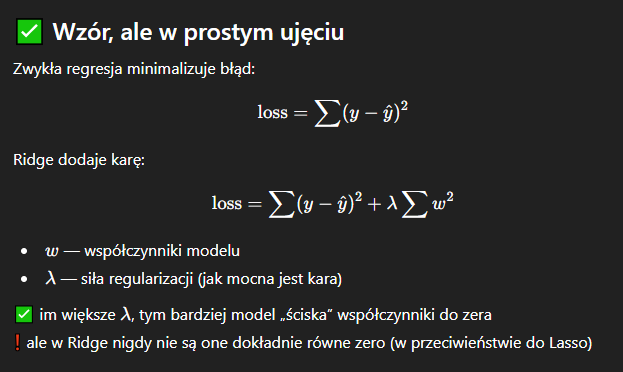

---

LASSO (Least Absolute Shrinkage and Selection Operator)
to regresja liniowa z regularizacją L1, która:

- ✅ zmniejsza współczynniki
- ✅ niektóre współczynniki ustawia dokładnie na 0 (czyli wybiera cechy!)
- ✅ zapobiega overfittingowi
- ✅ upraszcza model

W praktyce LASSO robi jednocześnie:

- regularyzację — zmniejsza zbyt duże wagi
- feature selection — usuwa nieistotne cechy

Jak to działa?

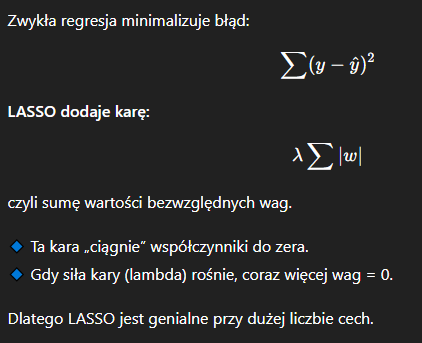

Co robi LASSO w jednym zdaniu?

LASSO to regresja liniowa z regularizacją L1, która automatycznie usuwa niepotrzebne cechy (ustawia ich wagi na 0) i zmniejsza overfitting.

---

Co to jest Feature Engineering?

Feature engineering to proces tworzenia, modyfikowania i wybierania najlepszych cech (features), czyli kolumn w danych, tak aby model uczył się lepiej i osiągał wyższą dokładność.

Innymi słowy:

To sztuka przekształcania surowych danych w takie cechy, które najlepiej opisują problem i pomagają modelowi go rozwiązać.

✅ Co obejmuje Feature Engineering?

1️⃣ Czyszczenie danych

- usuwanie braków (NaN)

- naprawa błędnych wartości

- usuwanie duplikatów

2️⃣ Tworzenie nowych cech

- BMI = waga / wzrost^2

- price_per_km = price / mileage

- engine_power_ratio = hp / weight

3️⃣ Przekształcanie istniejących cech

- standaryzacja (scaling)

- normalizacja

- log transform (np. log(cena))

4️⃣ Kodowanie danych kategorii

- One-Hot Encoding

- Label Encoding

- Target Encoding (ostrożnie)

5️⃣ Wybieranie najważniejszych cech

- usuwanie kolumn o małej wariancji

- usuwanie cech skorelowanych

- LASSO / Ridge / model feature importance

6️⃣ Łączenie cech

- "power-to-weight ratio"

- "distance_per_month"

- "car_age" z daty produkcji

---

**Rodzaje Encodingów**

1. One-Hot Encoding (OHE)
To najprostsza metoda: dla każdej kategorii tworzysz nową kolumnę, która przyjmuje wartość 1 (jeśli kategoria występuje) lub 0 (jeśli nie).

Kiedy stosować: Gdy kategorii jest mało (np. < 10) i nie mają one naturalnej kolejności (np. kolory, marki aut).

Wada (Przekleństwo wymiarowości): Jeśli masz 100 miast, OHE stworzy 100 nowych kolumn. Twoja macierz danych stanie się „rzadka” (mnóstwo zer), co spowolni model i może prowadzić do overfittingu.

2. Label Encoding / Ordinal Encoding
Przypisujesz każdej kategorii po prostu liczbę (np. Warszawa = 1, Kraków = 2, Gdańsk = 3).

Problem: Algorytmy takie jak Regresja Liniowa pomyślą, że Gdańsk (3) jest „większy” lub „ważniejszy” niż Warszawa (1), albo że średnia z Warszawy i Gdańska to Kraków. To wprowadza fałszywą hierarchię.

Kiedy stosować: Tylko gdy kategorie mają naturalną kolejność (np. wykształcenie: podstawowe = 1, średnie = 2, wyższe = 3).

3. Target Encoding (Mean Encoding)
Tu zaczyna się "wyższa szkoła jazdy". Zamiast losowych liczb, każdą kategorię zastępujesz średnią wartością celu (targetu) dla tej kategorii.

Przykład: Jeśli średnia cena Toyoty w Twoim zbiorze to 50 000 zł, to wszędzie tam, gdzie masz „Toyota”, wpisujesz 50 000.

Zaleta: Nie zwiększa liczby kolumn i przekazuje modelowi bardzo silną informację o relacji cechy z celem.

Pułapka (Data Leakage): To bardzo niebezpieczne! Model może „podglądać” odpowiedzi ze zbioru treningowego i przestać generalizować. Jeśli masz tylko jedną Toyotę w bazie i kosztuje ona 100 000 zł, model uzna, że każda Toyota tyle kosztuje.

4. CatBoost Encoding (Ordered Target Statistics)
To "target encoding na sterydach", który rozwiązuje problem wycieku danych. To właśnie ta technika sprawiła, że CatBoost stał się legendą.

Jak to działa: CatBoost nie liczy średniej z całego zbioru naraz. On „miesza” (permutuje) dane i dla każdego wiersza liczy średnią tylko z tych rekordów, które wystąpiły wcześniej w tej losowej kolejności.

Dlaczego to genialne: Dzięki temu model nie „widzi przyszłości”. Każdy rekord ma nieco inną wartość encodingu, co działa jak świetna regularyzacja.

5. Inne ważne techniki dla "Prosów"
Binary Encoding / Hashing Encoding
Dobre, gdy masz bardzo dużo kategorii (np. 5000 kodów pocztowych).

Binary: Zamienia numer kategorii na kod binarny, a potem rozdziela cyfry binarne na osobne kolumny. Zamiast 1024 kolumn (OHE) dostajesz tylko 10.

Hashing: Używa funkcji skrótu, by upchnąć kategorie w stałą liczbę kolumn. Ryzykujesz „kolizje” (różne kategorie dostaną ten sam numer), ale oszczędzasz mnóstwo pamięci.

Leave-One-Out Encoding
Podobne do Target Encodingu, ale licząc średnią dla danego wiersza, wykluczasz ten konkretny wiersz z obliczeń. To kolejny sposób na walkę z overfittingiem.

---

**Data Leakage - co to i jak zapobiegać**

Data Leakage (wyciek danych) to sytuacja, w której informacje z przyszłości lub spoza zbioru treningowego "przemycają się" do modelu podczas nauki.Efekt? Model na papierze (podczas testów) wygląda jak geniusz ($AUC = 0.99$), ale po wdrożeniu na produkcję całkowicie wykłada się na łopatki. To tak, jakbyś zdawał egzamin, mając odpowiedzi zapisane ołówkiem na ławce – wynik będzie świetny, dopóki nie pójdziesz do prawdziwej pracy, gdzie ławki są czyste.

1. Dwa główne rodzaje wycieku

A. Target Leakage (Wyciek zmiennej celu): 

Dzieje się wtedy, gdy Twoje cechy (features) zawierają dane, które są dostępne dopiero po wystąpieniu zdarzenia, które chcesz przewidzieć.

Przykład: Przewidujesz, czy klient zrezygnuje z subskrypcji (Churn). Jedną z Twoich cech jest "Data zwrotu routera".

Problem: Klient zwraca router tylko wtedy, gdy już zrezygnował. Model błyskawicznie nauczy się, że "zwrot routera = odejście". W świecie rzeczywistym nie będziesz wiedział, czy klient zwróci router, zanim to zrobi, więc model będzie bezużyteczny do wczesnego ostrzegania.

Przykład 2: Przewidywanie zapalenia płuc na podstawie cechy "Czy pacjent otrzymał antybiotyk na zapalenie płuc?".

B. Train-Test Contamination (Zanieczyszczenie zbiorów):

To błąd techniczny podczas przygotowywania danych. Informacje ze zbioru testowego wpływają na proces trenowania.

Przykład (Skalowanie): Obliczasz średnią i odchylenie standardowe dla całego zbioru danych, a potem skalujesz nim dane treningowe i testowe.

Dlaczego to wyciek? Twoje dane treningowe "wiedzą" już, jaki jest rozstęp i średnia danych testowych.

Przykład (Imputacja): Uzupełniasz braki danych średnią z całego datasetu zamiast tylko ze zbioru treningowego.

2. Jak rozpoznać, że masz wyciek?Na stażu/rozmowie zapamiętaj tę zasadę: "Jeśli wynik wygląda zbyt dobrze, żeby był prawdziwy, to prawdopodobnie jest to Data Leakage".

- Nienaturalnie wysokie metryki (np. $Accuracy = 99.8\%$) w pierwszej próbie.

- Jedna cecha ma miażdżącą przewagę w feature_importance. Jeśli np. "ID_transakcji" idealnie koreluje z oszustwem, to coś jest nie tak.

- Model działa świetnie na Cross-Validation, ale tragicznie na zupełnie nowym, zewnętrznym zbiorze danych (tzw. Out-of-Time validation).

3. Jak zapobiegać wyciekowi? (Twoja "Lista Kontrolna")

- Najpierw Split, potem reszta: Zawsze dziel dane na train i test zanim zrobisz cokolwiek innego (skalowanie, usuwanie braków, inżynieria cech).

- Używaj Pipeline’ów (np. sklearn.pipeline): To najlepszy sposób na automatyzację. Pipeline dba o to, by skaler "uczył się" tylko na foldach treningowych podczas Cross-Validation.

- Weryfikuj czasowość cech: Zadaj sobie pytanie: "Czy w momencie, gdy będę potrzebował predykcji tego modelu, ta informacja będzie już dostępna?".

- Usuwaj zmienne mocno skorelowane z celem, które są jego skutkiem: (Jak wspomniany router).

---

**Hiperparametry vs. Parametry**

Parametry – wartości, które model „uczy się” z danych (np. wagi w sieci neuronowej, współczynniki w regresji liniowej).

Hiperparametry – ustawienia, które wybierasz przed trenowaniem modelu i które mają wpływ na jego działanie (np. liczba drzew w Random Forest, głębokość drzewa, współczynnik regularizacji w regresji Lasso).

1. max_depth (Głębokość drzewa)Określa, jak bardzo skomplikowane może być pojedyncze drzewo.Wysoka wartość: Pozwala modelowi uczyć się bardzo specyficznych relacji w danych (niskie Bias, wysoka Wariancja). Jeśli dasz za dużo, drzewo zacznie tworzyć reguły typu: "Jeśli klient ma 32 lata, mieszka w Krakowie i ma kota o imieniu Filemon, to kupi produkt". To czysty overfitting.Niska wartość: Drzewa są proste (tzw. weak learners). Zmusza to boosting do szukania ogólnych trendów, a nie anomalii.Kierunek overfittingu: $\uparrow$ max_depth $\implies$ ryzyko przeuczenia.

2. n_estimators (Liczba drzew)To liczba rund boostingu, czyli ile kolejnych drzew próbujemy zbudować.Więcej znaczy lepiej? Do pewnego stopnia. W przeciwieństwie do Random Forest (gdzie po pewnym czasie błąd się stabilizuje), w Boostingu dodawanie kolejnych drzew zawsze przybliża Cię do overfittingu. Dlaczego? Bo model coraz silniej stara się naprawić nawet najmniejsze, losowe błędy z poprzednich kroków.Kierunek overfittingu: $\uparrow$ n_estimators $\implies$ ryzyko przeuczenia.

3. learning_rate (lub eta)To "krok uczenia". Określa, z jaką siłą każde kolejne drzewo koryguje błędy poprzedników.Mały learning_rate (np. 0.01): Model uczy się powoli i ostrożnie. Wymaga wtedy dużej liczby n_estimators, ale zazwyczaj prowadzi do lepszej generalizacji (lepiej radzi sobie z nowymi danymi).Duży learning_rate (np. 0.3): Model robi "wielkie kroki". Szybko znajduje rozwiązanie, ale łatwo może "przestrzelić" optimum i skupić się na szumie.Złota zasada: Zmniejszając learning_rate, powinieneś zwiększyć n_estimators.

4. subsample i colsample_bytree (Stochastyczność). Co robią? subsample bierze tylko część wierszy (np. 80%) do budowy drzewa, a colsample_bytree tylko część kolumn (cech). Dlaczego to ważne? Wprowadzają element losowości. Dzięki temu model nie polega tylko na jednej, najsilniejszej cesze, ale musi "kombinować" z innymi. To potężna broń przeciwko Wariancji.

5. Gamma (w XGBoost) lub min_split_gain Mechanizm: To minimalna redukcja straty (loss reduction) potrzebna, by zrobić kolejny podział w drzewie. Efekt: Działa jak "konserwatywny sędzia". Jeśli nowy podział poprawia wynik tylko odrobinę, gamma mówi: "Nie warto komplikować modelu, nie dzielimy tego liścia". reg_alpha (L1) i reg_lambda (L2). To czysta matematyczna regularyzacja wag liści. Lambda (L2): Sprawia, że wagi są mniejsze i bardziej "rozmyte" (zapobiega ekstremalnym predykcjom). Alpha (L1): Może wyzerować wagi cech, które nic nie wnoszą (działa trochę jak automatyczna selekcja cech).

6. min_child_weight (XGBoost) / min_data_in_leaf (LightGBM)To jeden z najważniejszych parametrów do walki z overfittingiem.Co robi: Określa minimalną "siłę" (w XGBoost sumę hesjanów, w uproszczeniu: liczbę próbek), jaka musi znaleźć się w liściu, żeby model pozwolił na podział.Dlaczego to ważne: Jeśli ustawisz go na bardzo małą wartość (np. 1), model może stworzyć liść tylko dla jednego, bardzo specyficznego auta (np. "czerwone Ferrari z 1990 roku z przebiegiem 5 km"). To niemal gwarantuje overfitting.Działanie: $\uparrow$ min_child_weight $\implies$ model staje się bardziej konserwatywny, drzewa są krótsze.

7. num_leaves (Kluczowy w LightGBM)W LightGBM to ważniejszy parametr niż max_depth.Kontekst: LightGBM rośnie "liśćmi" (leaf-wise), a nie poziomami. num_leaves określa maksymalną liczbę liści w całym drzewie.Zależność: Powinien być mniejszy niż $2^{max\_depth}$. Jeśli ustawisz num_leaves zbyt wysoko przy małym max_depth, model może stworzyć bardzo dziwne, niesymetryczne i głębokie ścieżki.Działanie: $\uparrow$ num_leaves $\implies$ wyższa złożoność, ryzyko overfittingu.

8. scale_pos_weight (Niezbędny przy braku równowagi)To parametr "ratunkowy", gdy Twoje dane są niezbalansowane (np. w Twojej bazie jest 10 000 zwykłych aut i tylko 100 aut luksusowych).Co robi: Nadaje większą wagę błędom popełnianym na klasie rzadkiej.Przykład: Jeśli przewidujesz awarię silnika (rzadkie zdarzenie), ustawienie tego parametru sprawi, że model zostanie mocniej "ukarany" za przeoczenie awarii niż za fałszywy alarm.Wzór: Zazwyczaj ustawia się go jako $\frac{\text{liczba próbek negatywnych}}{\text{liczba próbek pozytywnych}}$.

9. max_bin
Ten parametr rzadko jest zmieniany przez początkujących, a ma ogromny wpływ na prędkość i zużycie RAM.
Co robi: Modele boostingowe grupują ciągłe cechy (np. przebieg) w "koszyki" (bins), żeby nie sprawdzać każdego możliwego podziału (co trwałoby wieki). max_bin to liczba tych koszyków.
Wpływ: Mniejszy max_bin: Model jest znacznie szybszy, zajmuje mniej pamięci, ale traci na precyzji (działa jak silna regularyzacja).
Większy max_bin: Wyższa precyzja, ale wolniejsze trenowanie.

10. early_stopping_rounds (Technicznie to parametr metody .fit())
To Twoja polisa ubezpieczeniowa. Mechanizm: Mówisz modelowi: "Trenuj 1000 drzew, ale jeśli przez 50 kolejnych rund błąd na zbiorze walidacyjnym nie spadnie, przerwij zabawę". Dlaczego to genialne: Dzięki temu nie musisz zgadywać idealnego n_estimators. Model sam znajdzie punkt, w którym zaczyna się overfitting i tam się zatrzyma.

---

**Time series split**

1. Na czym polega Time-Series Split?
Zamiast losowo wybierać kawałki danych, stosujemy podejście „kroczącego okna” (Expanding Window). Wyobraź sobie, że Twój zbiór danych to oś czasu od stycznia do grudnia.

Fold 1: Trenujesz na styczniu, testujesz na lutym.

Fold 2: Trenujesz na styczniu i lutym, testujesz na marcu.

Fold 3: Trenujesz na okresie styczeń–marzec, testujesz na kwietniu.

...i tak dalej.

Zbiór treningowy „puchnie” (rozszerza się), ale zbiór testowy zawsze znajduje się chronologicznie po zbiorze treningowym.

2. Dlaczego to jest kluczowe?
Autokorelacja: Dane szeregów czasowych są ze sobą powiązane. Dzisiejsza cena akcji zależy od wczorajszej. Jeśli wymieszasz te dni (jak w K-Fold), model dostanie „ściągę” i jego wyniki będą sztucznie zawyżone (overfitting do czasu).

Trendy i sezonowość: Model musi nauczyć się wyłapywać trendy (np. wzrost sprzedaży przed świętami) na podstawie przeszłości. Tylko Time-Series Split sprawdza, czy model faktycznie „rozumie” upływ czasu.

3. Wariant: Sliding Window (Przesuwne okno)

Czasami dane sprzed 5 lat są już nieistotne (np. trendy w modzie). Wtedy zamiast rozszerzać zbiór treningowy, „przesuwamy” go:

Trenujesz na: Styczeń–Marzec $\implies$ Testujesz na: Kwietniu.

Trenujesz na: Luty–Kwiecień $\implies$ Testujesz na: Maju.

W ten sposób model zawsze uczy się na „świeżych” danych o stałej długości (np. zawsze ostatnie 3 miesiące).

---

**Grid Search i Random Search**

1. Grid Search Grid Search to podejście polegające na brutalnej sile i wyczerpaniu wszystkich możliwości.

Jak to działa?
Definiujesz siatkę (grid) wartości, które chcesz przetestować. Na przykład:

- max_depth: [3, 5, 7] (3 wartości)

- learning_rate: [0.01, 0.1] (2 wartości)

- n_estimators (liczba drzew): [50, 100] (2 wartości)

Grid Search weźmie te listy i sprawdzi absolutnie każdą możliwą kombinację. W tym przypadku stworzy 3 * 2 * 2 = 12 różnych modeli, wytrenuje je, oceni (zazwyczaj używając wybranej przez Ciebie metryki, np. PR-AUC czy F1-Score) i zwróci ten najlepszy.

Zalety:

- Wyczerpujący: Masz 100% gwarancji, że znajdziesz najlepszą kombinację z tych, które podałeś w siatce.

- Prosty w zrozumieniu: Kod jest łatwy do napisania i zinterpretowania.

Wady:

- Klątwa wymiarowości: Jeśli dodasz do siatki jeszcze jeden parametr z 5 wartościami, nagle musisz wytrenować 12 * 5 = 60 modeli. Czas obliczeń rośnie wykładniczo i przy złożonych modelach (jak XGBoost czy sieci neuronowe) może to trwać tygodniami.

2. Random Search (Przeszukiwanie Losowe) – "Sprytne Próbkowanie"

Random Search wychodzi z założenia, że sprawdzanie wszystkiego to strata czasu. Zamiast tego losuje kombinacje.

Jak to działa?

Zamiast podawać sztywne listy, często podajesz przedziały (dystrybucje), np. learning_rate w przedziale od 0.001 do 0.1. Następnie mówisz algorytmowi: "Wylosuj z tych przedziałów 50 różnych kombinacji i sprawdź tylko te".

Zalety:

- Szybkość i kontrola nad budżetem: Ty decydujesz, ile masz czasu (np. pozwalasz na dokładnie 50 iteracji).

- Wyższa skuteczność (Paradoks? Niekoniecznie): W uczeniu maszynowym często jest tak, że tylko 1 lub 2 hiperparametry mają krytyczny wpływ na wynik, a reszta to kosmetyka.

- W Grid Search, testując siatkę 3x3, sprawdzasz tylko 3 unikalne wartości ważnego parametru (bo reszta to kombinacje z parametrem nieważnym).

- W Random Search przy 9 próbach sprawdzisz 9 zupełnie różnych wartości tego ważnego parametru. Dlatego Random Search często szybciej znajduje lepszy model!

Wady:

- Brak gwarancji: Może się zdarzyć, że przez czysty pech algorytm ominie "złoty środek" i nigdy nie wylosuje optymalnej kombinacji.

---

Logistic regression (regresja logistyczna) to model, który służy do przewidywania prawdopodobieństwa, że coś należy do jednej z dwóch klas (np. „tak” / „nie”, „spam” / „nie spam”).

Działa w kilku prostych krokach:

- Zbiera dane wejściowe (cechy) – np. wiek, dochód, ilość zakupów itp.

- Oblicza kombinację liniową tych cech (czyli coś w rodzaju $z = w_1x_1 + w_2x_2 + b$

- Przepuszcza wynik przez funkcję sigmoidalną (S-kształtną), która zamienia wynik na liczbę między 0 a 1:

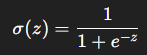

- Wynik (np. 0.8) to prawdopodobieństwo, że przypadek należy do klasy 1.

Jeśli:
- 𝑝>0.5
- p>0.5 → klasyfikujemy jako „1”

Jeśli:
- 𝑝≤0.5
- p≤0.5 → klasyfikujemy jako „0”
 
Przykład:
Model może przewidywać, czy klient kupi produkt.
Jeśli wynik = 0.9 → 90% szans, że kupi.
Jeśli 0.2 → raczej nie kupi.

Mimo że nazywa się regresją, służy głównie do klasyfikacji binarnej, a nie do przewidywania wartości liczbowych.

---

Maximum Likelihood

Algorytm, działanie:

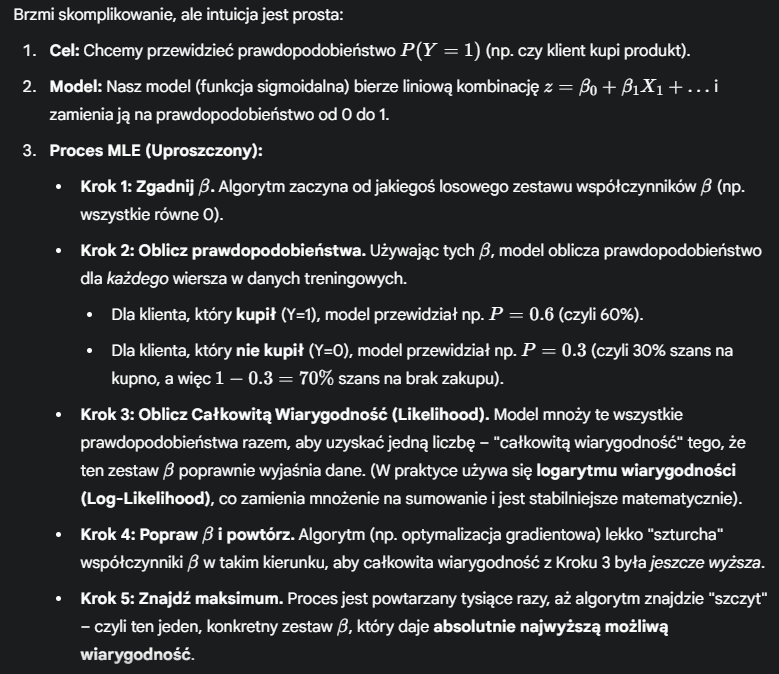

Krótko mówiąc: MLE to proces "dostrojenia" modelu, który zadaje pytanie: "Jakie muszą być wartości $\beta$, aby prawdopodobieństwo zobaczenia tych wyników, które już mam w danych, było jak największe?"



---

1) Co to jest confusion matrix (macierz pomyłek)

Dla problemu klasyfikacji binarnej (dwie klasy: pozytywna 1 i negatywna 0) macierz pomyłek to tabela 2×2 pokazująca, jak model przewidywał względem faktycznych etykiet:

                 Predicted
               |   1   |   0   |
         1  ---|  TP   |  FN   |
         0  ---|  FP   |  TN   |


TP (True Positives) — prawdziwe pozytywy: model przewidział 1, a rzeczywiście było 1.

TN (True Negatives) — prawdziwe negatywy: model przewidział 0, a rzeczywiście 0.

FP (False Positives) — fałszywe pozytywy (Type I error): model przewidział 1, a w rzeczywistości 0.

FN (False Negatives) — fałszywe negatywy (Type II error): model przewidział 0, a w rzeczywistości 1.

2) Accuracy (dokładność) — definicja i wzór

Accuracy to odsetek poprawnych przewidywań spośród wszystkich obserwacji:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

3) Kiedy accuracy jest mylące (kluczowy problem)

Jeżeli dane są nierównomiernie rozłożone (np. 99% klasy 0, 1% klasy 1), to model „przewidujący zawsze 0” osiągnie 99% accuracy, mimo że nigdy nie wykrywa klasy ważnej (1). W takim przypadku accuracy daje fałszywe poczucie dobrej jakości.

MIARY KLASYFIKACJI:

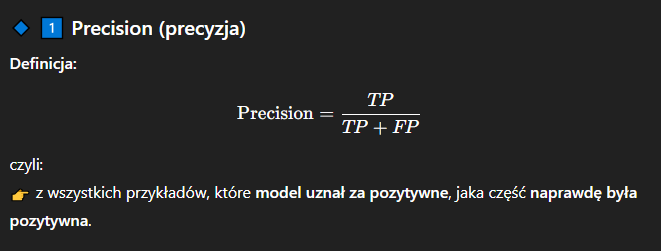

Precision mierzy dokładność pozytywnych przewidywań.

- Jeśli model wykrywa choroby i ma wysoką precision = 0.95, oznacza to, że 95% osób, które model uznał za chore, faktycznie są chore.

- Niska precision = dużo fałszywych alarmów (False Positives).

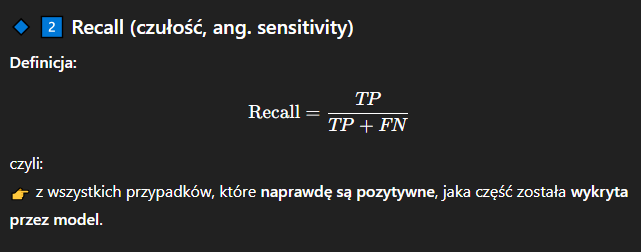

Recall mierzy kompletność wykrywania przypadków pozytywnych.

- Jeśli model medyczny ma recall = 0.90, to 90% chorych osób zostanie wykrytych.

- Niska recall = model przeocza wiele prawdziwych przypadków (False Negatives).

Kiedy recall jest ważny?

Gdy nie można przeoczyć pozytywnego przypadku (FN).
Np. wykrywanie raka, alarm pożarowy, test bezpieczeństwa.
Wolimy mieć kilka fałszywych alarmów, niż przegapić coś istotnego.

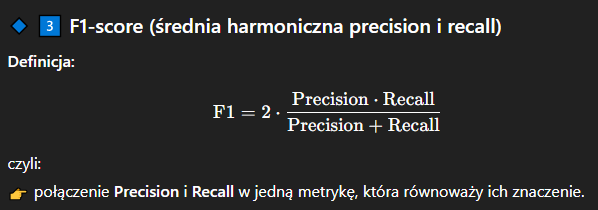

- F1-score = „średnia ważona” między precision a recall.

- Wysoki F1 tylko wtedy, gdy oba (precision i recall) są wysokie.

- Jeśli jedno z nich jest niskie — F1 mocno spada.

Gdy dane są niezrównoważone (np. 99% klasy negatywnej, 1% pozytywnej).

Gdy zależy nam zarówno na trafności wykrywania (recall), jak i dokładności wyników (precision).
Np. wykrywanie spamu, fraud detection, diagnozy chorób.

---

**Czym jest ROC curve?**

ROC curve to wykres, który pokazuje, jak dobrze model potrafi odróżniać dwie klasy (np. „chory” vs „zdrowy”), dla różnych progów decyzyjnych.

W modelu klasyfikacyjnym (np. regresja logistyczna, sieć neuronowa) wynik to prawdopodobieństwo, że dany przykład należy do klasy 1 (np. „chory”).
Przykład:

- jeśli model zwraca P = 0.9, to raczej „chory”,

- jeśli P = 0.1, to raczej „zdrowy”.

Zazwyczaj przyjmujemy próg = 0.5, czyli:

- jeśli P ≥ 0.5 → przewidujemy klasę 1,

- jeśli P < 0.5 → przewidujemy klasę 0.

Ale ROC bada wszystkie możliwe progi (od 0 do 1) i pokazuje, jak zmienia się skuteczność klasyfikacji w zależności od tego progu.

Co znajduje się na osiach ROC?

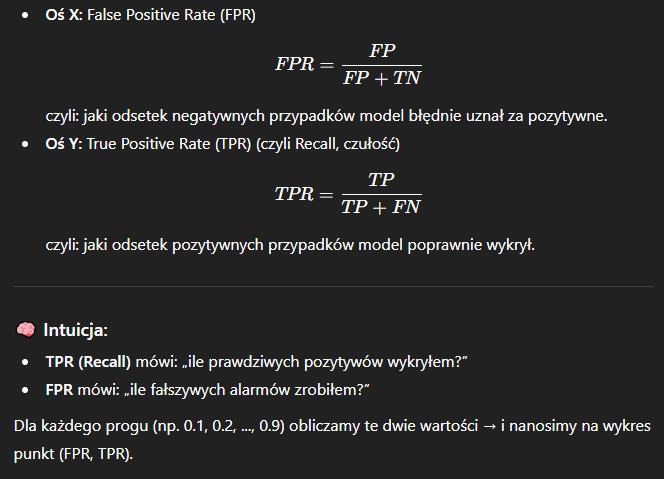

AUC – Area Under Curve (pole pod krzywą)

To liczba, która podsumowuje cały wykres ROC w jednej wartości:

AUC = pole pod krzywą ROC

- AUC = 1.0 → idealny model, perfekcyjne rozróżnianie klas

- AUC = 0.5 → model losowy (żadnego rozróżnienia)

- AUC < 0.5 → model gorszy niż losowy (może myli klasy)

**PR-AUC**

1. PR-AUC (Precision-Recall Area Under Curve) to jedna z najważniejszych miar oceny jakości klasyfikatora w uczeniu maszynowym – zwłaszcza gdy masz do czynienia z „trudnymi” danymi.

W skrócie: to liczba, która mówi Ci, jak dobrze Twój model radzi sobie z wykrywaniem klasy pozytywnej (tej, na której Ci zależy), nie generując przy tym zbyt wielu fałszywych alarmów.

2. Czym jest sama krzywa PR?

Model klasyfikacyjny zazwyczaj zwraca prawdopodobieństwo (np. 0.85), a nie twarde "tak" lub "nie". To Ty decydujesz, gdzie postawić granicę (threshold).

Jeśli ustawisz próg bardzo wysoko, wzrośnie Precision, ale spadnie Recall.

Jeśli ustawisz próg nisko, wyłapiesz prawie wszystko (Recall), ale zaczniesz się mylić (Precision spadnie).

Krzywa Precision-Recall pokazuje tę zależność dla wszystkich możliwych progów. PR-AUC to po prostu pole powierzchni pod tą krzywą.

3. Kiedy PR-AUC jest lepsze niż popularne ROC-AUC?

To kluczowe pytanie. Większość osób zaczyna od ROC-AUC, ale PR-AUC jest bezlitosne i bardziej szczere w konkretnym przypadku: niezbalansowane zbiory danych.

Wyobraź sobie wykrywanie rzadkiej choroby (1 chory na 1000 zdrowych):

ROC-AUC: Może wyglądać świetnie (np. 0.95), bo bardzo łatwo jest modelowi poprawnie przewidzieć tysiące osób zdrowych.

PR-AUC: Wykaże słabość modelu, jeśli ten nie potrafi precyzyjnie wskazać tych kilku chorych bez "strzelania na oślep".

Zasada kciuka: Jeśli Twoja klasa pozytywna jest rzadka (fraud w banku, awaria silnika, rzadka choroba), patrz na PR-AUC. Jeśli klasy są mniej więcej równe, ROC-AUC wystarczy.

---

**SHAP**

Kluczowy problem, który rozwiązuje SHAP: Wielokoliniowość (Korelacja)
Zwykłe metody (np. usuwanie cechy i sprawdzanie spadku wyniku) zawodzą, gdy cechy są skorelowane (np. Wiek i Staż pracy). Jeśli usuniesz jedną, druga przejmie jej rolę.

SHAP rozwiązuje to poprzez analizę marginalnego wkładu cechy we wszystkich możliwych kombinacjach (koalicjach).

Model trenowany jest na kombinacji cech {Wiek}.

Model trenowany jest na kombinacji {Wiek, Staż}.

Marginalny wkład Stażu to różnica w predykcji między (2) a (1).

Ten proces jest powtarzany dla Stażu dodawanego do {Dochód}, {Wiek, Dochód}, {}, itd. Wartość SHAP to ważona średnia tych wszystkich marginalnych wkładów. To gwarantuje sprawiedliwość alokacji wpływu.

2. SHAP jako Model Addytywny (Additive Feature Attribution)

Dla inżyniera ML najważniejszą techniczną właściwością SHAP jest to, że definiuje on wyjaśnienie jako model liniowy wkładów cech.

Dla konkretnej obserwacji $x$, predykcja $f(x)$ jest dekomponowana w następujący sposób:

        $$f(x) = \phi_0 + \sum_{i=1}^{M} \phi_i$$
        
Gdzie:

- $f(x)$ to ostateczna predykcja modelu (np. 0.85 prawdopodobieństwa).

- $\phi_0$ to wartość bazowa (baseline): średnia predykcja modelu na całym zbiorze treningowym (np. 0.15).

- $\phi_i$ to wartość SHAP dla cechy $i$ (może być dodatnia lub ujemna).$M$ to liczba cech.

Co to oznacza w praktyce?

Wartości SHAP dosłownie sumują się do różnicy między predykcją a średnią. Jeśli baseline to 0.15, a model przewidział 0.85, to suma wszystkich $\phi_i$ musi wynosić dokładnie 0.70.

3. Implementacja Techniczna: Rodzaje Wyjaśniaczy (Explainers)

Obliczenie dokładnych wartości Shapleya jest NP-trudne (wymaga $2^M$ kombinacji). Biblioteka shap w Pythonie używa optymalizacji i aproksymacji dedykowanych dla różnych typów modeli.

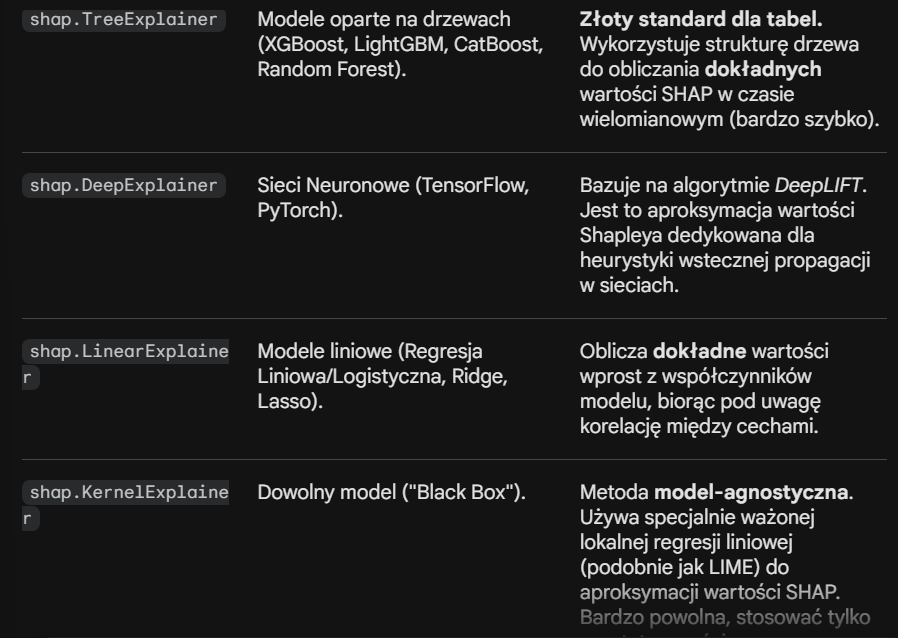

4. Techniczna Interpretacja Wykresów

Jako inżynier ML, musisz patrzeć na wykresy SHAP przez pryzmat diagnozy modelu.

A. Beeswarm Plot (Globalna Interpretacja)

- Oś Y: Cechy posortowane według całkowitego wpływu na model (średnia absolutna wartość SHAP).

- Oś X: Wartość SHAP ($\phi_i$). Punkty na prawo podnoszą predykcję, na lewo obniżają.

- Kolor: Wartość samej cechy (Czerwony = wysoka, Niebieski = niska).

- Gęstość (Pęcznienie): Pokazuje rozkład wartości.

Przykładowa diagnoza: Czerwień po prawej stronie dla cechy Dochód oznacza, że model poprawnie nauczył się, iż wysoki dochód liniowo zwiększa predykcję targetu. Jeśli widziałbyś czerwień rozproszoną po obu stronach, oznaczałoby to nieliniową, skomplikowaną zależność lub problem z interakcjami.

B. Dependence Plot (Interakcje)

To potężniejsze narzędzie niż Partial Dependence Plots (PDP).

- Oś X: Wartość jednej cechy (np. Wiek).

- Oś Y: Wartość SHAP dla tej samej cechy (Wiek).

- Kolor: Wartość drugiej cechy, z którą badamy interakcję (np. Płeć).

Przykładowa diagnoza: Widzisz, że dla Wieku < 30 wartości SHAP są ujemne (młodzi mają mniejszą szansę na target). Jednak punkty są rozbite: młode kobiety (np. czerwone) mają SHAP bliski 0, a młodzi mężczyźni (niebiescy) mają SHAP -0.5. To jawny dowód na to, że model wykrył silną interakcję między Wiekiem a Płcią, której nie zauważyłbyś na wykresie beeswarm.

---

1. LogisticRegression

To podstawowa implementacja regresji logistycznej.

Cechy:

- Nie robi automatycznej walidacji krzyżowej.

- Używa pojedynczych wartości hiperparametrów (np. C, penalty, solver).

- Trenuje jeden model.

Kiedy używać?

Gdy:

- masz już dobrane hiperparametry,

- chcesz szybko wytrenować regresję logistyczną.

2. #LogisticRegressionCV

To regresja logistyczna z wbudowaną walidacją krzyżową (CV).

Cechy:

- Automatycznie dobiera hiperparametr C (i czasem inne) używając CV.

- Używa zoptymalizowanego rozwiązania dla regresji logistycznej.

- Szybsze niż granulowany GridSearchCV, bo zoptymalizowane specjalnie pod regresję logistyczną.

Kiedy używać?

Gdy:

- chcesz automatycznie dobrać C,

- zależy ci na wydajności,

- zakres hiperparametrów jest mały.

3. #GridSearchCV

To ogólny mechanizm przeszukiwania siatki hiperparametrów z walidacją krzyżową dla dowolnego modelu (także LogisticRegression).

Cechy:

- Możesz stroić wiele hiperparametrów (np. C, penalty, solver, class_weight itd.).

- Bardziej elastyczny, ale wolniejszy.

- Umożliwia stosowanie dowolnych metryk, własnych siatek parametrów itp.

Kiedy używać?

Gdy:

- chcesz stroić wiele hiperparametrów,

- potrzebujesz pełnej kontroli nad procesem CV,

- masz bardziej skomplikowane wymagania niż tylko wybór C.

---

**KNN**

K-NN to leniwy (ang. lazy) i oparty na podobieństwie algorytm. Dla nowej obserwacji:

- znajdujesz k najbliższych przykładów w zbiorze uczącym (według wybranej metryki odległości),

- w klasyfikacji przewidujesz etykietę na podstawie głosu tych sąsiadów (np. większość),

- w regresji przewidujesz średnią (lub ważoną średnią) wartości z sąsiadów.

Nie ma etapu „treningu” w sensie uczenia parametrów modelu — jedynie przechowujesz zbiór uczący.

Matematyka — metryki i wybór k:

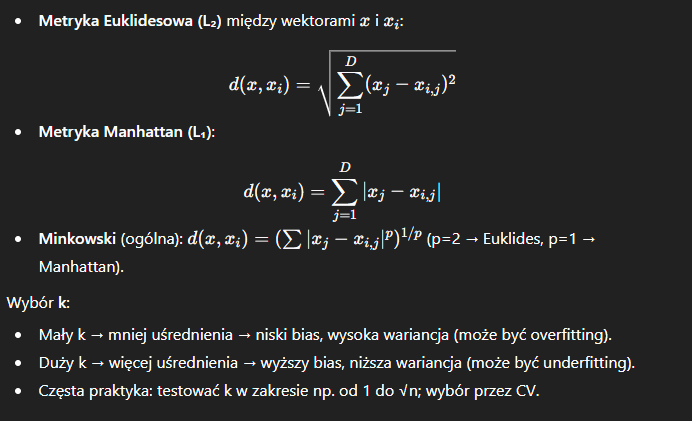

Klasyfikacja: przewidywanie i prawdopodobieństwa

- Klasa przewidziana = najczęściej występująca etykieta w k-sąsiadach (można rozwiązywać remisy np. losowo lub preferując klasę z mniejszym indeksem).

- Szacowanie prawdopodobieństw: proporcja głosów (lub sumy wag) dla każdej klasy wśród k-sąsiadów.

Normalizacja cech

BARDZO ważne: K-NN używa odległości — cechy muszą być skalowane (np. StandardScaler, MinMaxScaler). Jeśli nie, cechy o większej skali zdominują odległość.

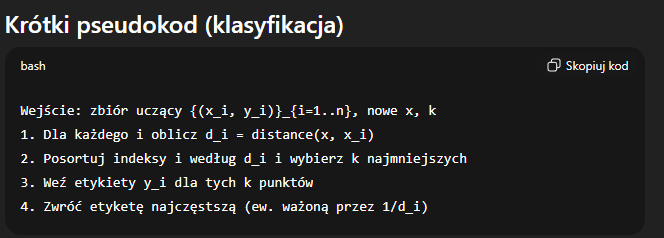

---

**Elbow method**

Metoda Elbow (łokcia) to popularna technika służąca do wyboru optymalnej liczby klastrów (k) w algorytmach grupowania, np. K-Means.

Idea:

1. Dla różnych wartości k (np. 1–10) obliczamy wszystkie sumy kwadratów odchyleń punktów od centroidów (ang. Within-Cluster Sum of Squares, WCSS).

- WCSS = suma kwadratów odległości punktów do ich centroidu.

- Mierzy „ściśnięcie” punktów w klastrze — im mniejsze WCSS, tym punkty w klastrze bliżej siebie.

2. Rysujemy wykres WCSS względem liczby klastrów k.

3. Szukamy punktu, w którym dalsze zwiększanie k daje coraz mniejszą poprawę (krzywa „złamańca” przypominającego łokieć).

- To miejsce to „elbow” (łokieć) — sugeruje optymalną liczbę klastrów.

Intuicja

- Dla małego k: WCSS duże, bo klastry są zbyt ogólne, punkty oddalone od centroidów.

- Dla dużego k: WCSS maleje, bo mamy więcej centroidów → mniejsze odległości punktów do nich.

- Elbow: punkt kompromisu między zbyt małą a zbyt dużą liczbą klastrów.


Wyjaśnienie pojęć:

1. Klaster

Klaster to grupa punktów danych, które są do siebie podobne według pewnego kryterium (najczęściej odległości w przestrzeni cech).

- Idea: punkty w tym samym klastrze są bardziej do siebie podobne niż do punktów w innych klastrach.

- Przykład intuicyjny: wyobraź sobie grupę ludzi na placu. Osoby stojące blisko siebie tworzą „klaster”, osoby daleko – inny klaster.

- W praktyce w ML: każdy klaster to podzbiór punktów w zbiorze danych.

2. Centroid

Centroid to środek ciężkości klastra, czyli punkt reprezentujący „typowy punkt” w tym klastrze.

- Oblicza się go jako średnią współrzędnych wszystkich punktów w klastrze.

- Jeśli klaster ma punkty $x_!, x_2, ..., x_n$ w D-wymiarowej przestrzeni, centroid 𝜇 to:

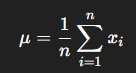

- Intuicja: centroid jest jak „środek” grupy punktów.

3. WCSS

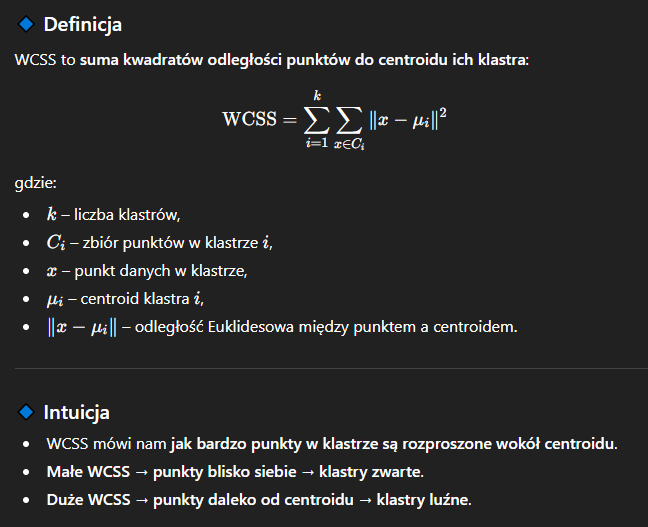

---

**SVM**

1. Co to jest SVM?

SVM (Support Vector Machine) to algorytm uczenia maszynowego do:

- klasyfikacji (binary i multiclass),

- regresji (SVR),

- detekcji anomalii (One-Class SVM).

Jego głównym celem jest znalezienie granicy decyzyjnej (hiperpłaszczyzny), która najlepiej oddziela klasy w danych.

2. Intuicja: separacja z maksymalnym marginesem

SVM szuka takiej prostej/hiperpłaszczyzny, która:

- maksymalizuje margines, czyli odległość od najbliższych punktów obu klas,

- nie patrzy na wszystkie punkty, tylko na te kluczowe – tzw. support vectors.

👉 Support vectors to punkty najbliżej granicy, które „ustawiają” granicę decyzyjną.

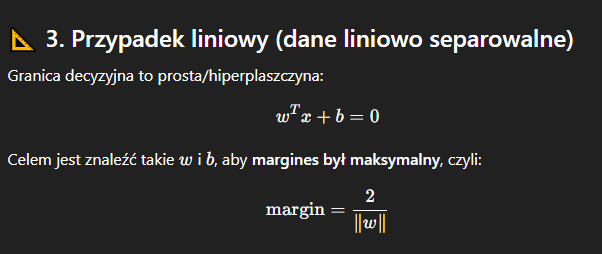

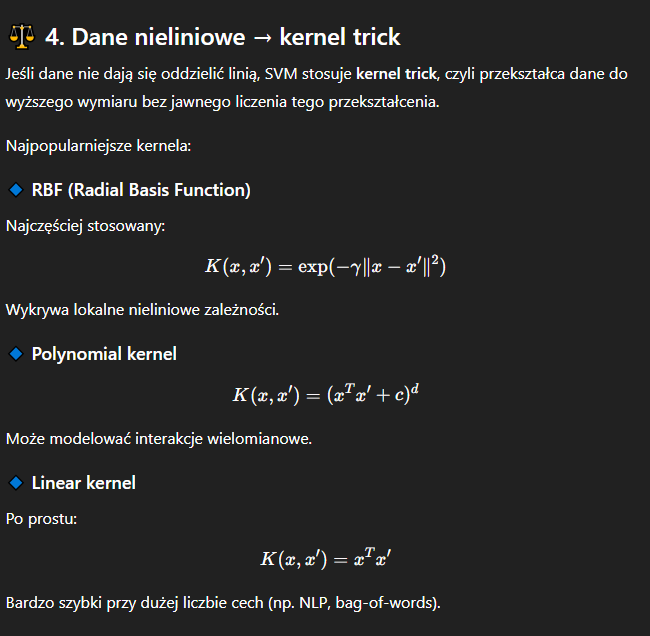

5. Parametry SVM (najważniejsze)
   
🔸 C – kara za błędną klasyfikację

- Duże C → mała regularyzacja → model stara się perfekcyjnie klasyfikować → ryzyko przeuczenia.

- Małe C → duża regularyzacja → model akceptuje pewne błędy → bardziej gładka granica.

🔸 gamma (tylko dla RBF i polynomial)

Kontroluje „zakres oddziaływania” pojedynczego punktu:

- Duże gamma → granica bardzo poszarpana → ryzyko overfitting.

- Małe gamma → zbyt gładka granica → underfitting.

🔸 kernel

- 'linear', 'poly', 'rbf', 'sigmoid'.

---

**Wyjaśnienie pojęć**

Kernel trick pozwala działać tak, jakbyśmy przenieśli dane do wysokiego wymiaru, ale bez faktycznego obliczania tych przekształceń.

Jak?

SVM potrzebuje jedynie:

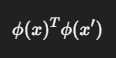

czyli iloczynu wektorów w przestrzeni cech po transformacji.

Kernel trick polega na tym, że:

⭐ można policzyć ten iloczyn bez liczenia 𝜙(𝑥)

Tylko stosując funkcję:

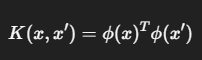

czyli kernel (jądro).

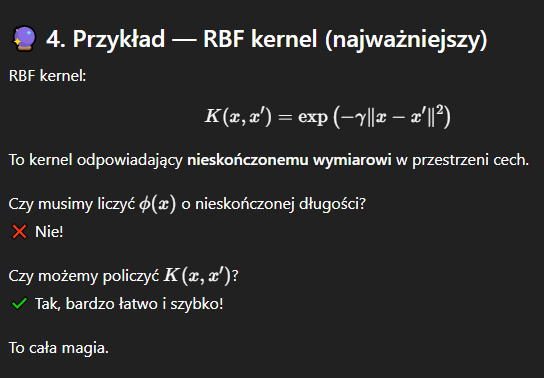

---

**Margines** to odległość między linią/hiperpłaszczyzną decyzyjną a najbliższymi punktami obu klas.

Dlaczego margines ma znaczenie?

SVM zakłada:

Im większy margines, tym lepiej model generalizuje (jest mniej wrażliwy na szum i nie przeucza się).

Granica z dużym marginesem = stabilny, pewny podział.
Granica z małym marginesem = bardzo zależna od przypadkowych punktów, ryzyko overfittingu.

Co znaczy „maksymalizować margines”?

Oznacza to:

➤ Znaleźć taką hiperpłaszczyznę, która oddziela klasy jak najszerzej, pozostawiając jak największy „pas bezpieczeństwa”.

Czyli:

- nie szukamy dowolnej linii, która rozdziela klasy,

- szukamy najlepszej — tej, która daje największą odległość od danych.

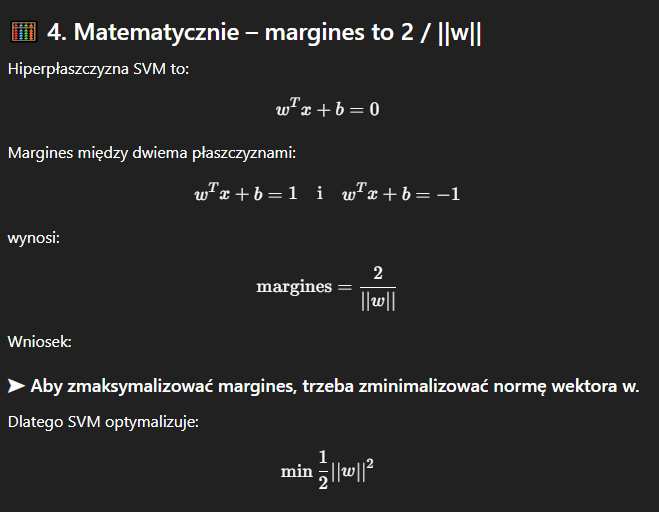

**Support vectors to punkty najbliżej granicy**.

**Tylko one wpływają na położenie hiperplaszczyny**.
Dlatego SVM dosłownie:

➤ „ustawia” granicę tak, aby była jak najdalej od tych punktów.

**Porównanie kernelów:**

| Kernel      | Typ danych                          | Zalety                         | Wady                                     |
| ----------- | ----------------------------------- | ------------------------------ | ---------------------------------------- |
| linear      | dane liniowe, dużo cech             | szybki, prosty, interpretable  | nie radzi sobie z nieliniowością         |
| poly        | nieliniowe, wielomianowe zależności | może modelować interakcje cech | wolny przy wysokim stopniu               |
| rbf         | większość nieliniowych              | uniwersalny, elastyczny        | trzeba stroić gamma, ryzyko overfittingu |
| sigmoid     | nieliniowe                          | podobny do NN                  | mniej stabilny, rzadko stosowany         |
| precomputed | dowolne                             | pełna kontrola kernelu         | wymaga macierzy podobieństw              |


---

**SVR – Support Vector Regression**

SVR to regresyjna wersja SVM (Support Vector Machine).
Modeluje dane ciągłe (np. ceny, temperatury, czas), a nie klasy.

❗ Kluczowa idea SVR

SVR stara się znaleźć funkcję (hiperpłaszczyznę), która:

- przechodzi przez dane z tolerancją błędu ε,

- a wszystkie punkty poza tą strefą karane są parametrem C.

W odróżnieniu od klasycznej regresji:

- SVR minimalizuje maksymalny błąd, nie średni,

- używa tylko support vectors, a nie wszystkich punktów.

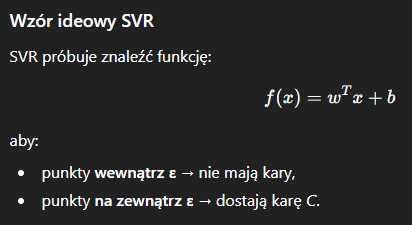

Parametry SVR, które najczęściej dostraja się:

- C – kara za błędy (większe C = bardziej skomplikowana funkcja)

- epsilon – szerokość rurki tolerancji

- gamma – wpływ punktów na granicę (rbf/poly/sigmoid)

| Cecha           | SVM                      | SVR                    |
| --------------- | ------------------------ | ---------------------- |
| Zadanie         | Klasyfikacja             | Regresja               |
| Co liczy?       | Margines między klasami  | Rurka ε wokół regresji |
| Support vectors | Punkty najbliżej granicy | Punkty poza rurką      |
| Parametry       | C, gamma                 | C, gamma, epsilon      |


---

Co to jest drzewo decyzyjne?

Decision Tree to model, który podejmuje decyzje zadając serię pytań typu „jeśli... to...”.

Wygląda jak drzewo:

                [Czy temperatura > 20°C?]
                 /                     \
              TAK                       NIE
          [Czy wilgotność > 60?]       [Pada deszcz?]
            /        \                  /         \
         TAK         NIE              TAK         NIE
     -> Klasa A   -> Klasa B       -> Klasa C   -> Klasa D

To prosty, logiczny, czytelny model, który imituje ludzkie myślenie.

Do czego służą drzewa decyzyjne?
✔️ Klasyfikacja

np.:

- czy klient odejdzie

- czy mail to spam

- czy choroba występuje

✔️ Regresja

np.:

- cena domu

- przewidywanie czasu

- prognoza popytu

**Schemat działania drzewa decyzyjnego**

1. Drzewo decyzyjne działa tak, jak człowiek podejmujący decyzje krok po kroku, zadając kolejne pytania.

Przykład:

Chcesz przewidzieć, czy klient kupi produkt.

Drzewo może stworzyć taki model:

Czy wiek > 40?
 ├── TAK → Czy dochód > 60k?
 │        ├── TAK → kupi
 │        └── NIE → nie kupi
 └── NIE → nie kupi


Drzewo samo wybiera:

- jakie pytanie zadać (np. „wiek > 40”)

- gdzie ustawić granicę (np. 40)

- jak wiele poziomów stworzyć

2. Jak drzewo decyzyjne uczy się? (mechanizm)

Dla każdego możliwego podziału:

- 1️⃣ wybiera cechę (np. „wiek”, „dochód”)
- 2️⃣ wybiera punkt podziału (np. wiek > 40)
- 3️⃣ oblicza, jak czyste są grupy po podziale
- 4️⃣ wybiera podział, który najbardziej oczyszcza dane

Pojawia się kluczowe pytanie:

Co to znaczy „czyste”?

Odpowiedź:
✔️ czysta grupa = większość próbek należy do jednej klasy
❌ nieczysta grupa = pół na pół

I tu pojawia się Gini impurity.

**Gini impurity** (nieczystość Gini’ego) to miara mówiąca,
jak bardzo mieszane są klasy w danym węźle.

Wzór:

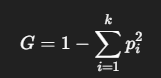

gdzie:

- $p_i$ = proporcja klasy i w węźle

- $k$ = liczba klas

| Sytuacja                | Przykład          | Gini | Co to oznacza                     |
| ----------------------- | ----------------- | ---- | --------------------------------- |
| **Czysta grupa**        | 100% jednej klasy | 0    | idealna czystość                  |
| **Mieszana pół na pół** | 50%–50%           | 0.5  | maksymalna nieczystość dla 2 klas |
| **Zupełny chaos**       | 33%–33%–33%       | 0.67 | duża nieczystość                  |

Jak drzewo używa Gini?

Dla każdego możliwego podziału drzewo:

- dzieli dane według warunku

- liczy Gini impurity w lewej i prawej grupie

- liczy ważoną średnią nieczystości

- wybiera podział z najmniejszą nieczystością

Decyzja = wybór najlepszego pytania.

**Podsumowanie w prostych słowach**

- Drzewa decyzyjne dzielą dane na mniejsze grupy.

- Chcemy, by w każdej grupie były jak najbardziej jednorodne klasy.

- Gini impurity mówi nam, jak bardzo grupy są „wymieszane”.

- Wybieramy podział, który daje najczystsze grupy.

---

**Random Forests**

1. Co to jest Random Forest?

Random Forest (Las Losowy) to algorytm uczenia maszynowego oparty na wielu drzewach decyzyjnych.

To ensemble learning, czyli metoda, która łączy wiele modeli, aby uzyskać lepszy wynik niż pojedynczy model.

Intuicja:

- Jedno drzewo = może się przeuczyć, jest „niestabilne”

- 100 drzew = uśredniony wynik → znacznie bardziej stabilny i dokładny

Random Forest = wiele (setki) drzew decyzyjnych + losowanie danych + losowanie cech

2. Jak działa Random Forest?
   
🔧 Krok 1: Bootstrap sampling (losowanie próbek)

Dla każdego drzewa losujemy z powtórzeniami próbki z danych treningowych (tzw. bootstrap).

Efekt:

- każde drzewo widzi trochę inne dane

- drzewa stają się od siebie niezależne → ważne dla dobrej generalizacji

🔧 Krok 2: Losowanie cech do podziału

W zwykłym drzewie sprawdzamy wszystkie cechy przy każdym podziale.

W Random Forest:

- sprawdzamy tylko losowy podzbiór cech (np. √n cech)

Daje to:

- większą różnorodność drzew

- mniejsze ryzyko przeuczenia

🔧 Krok 3: Budowa wielu drzew

Każde drzewo jest trenowane:

- na innych danych

- z innym zestawem cech

- ma własną strukturę

🔧 Krok 4: Agregacja wyników

Klasyfikacja:

⭐ głosowanie większościowe — najczęściej wybierana klasa wygrywa.

Regresja:

⭐ średnia z wyników wszystkich drzew.

1️⃣ **Number of Estimators** (n_estimators)
✔️ Co to jest?

n_estimators = liczba drzew w lesie (Random Forest).

Czyli ile oddzielnych drzew decyzyjnych będzie trenowanych na losowych danych i cechach.

✔️ Jak to działa w praktyce?

Random Forest:

- trenuje wiele drzew (np. 100),

- każde drzewo dostaje bootstrap sample (losowaną próbkę danych),

- każde drzewo głosuje na klasę,

finalna decyzja = głosowanie większościowe.

✔️ Jak dobrać liczbę drzew?
🔸 Mało drzew (np. 10)

- szybkie trenowanie

- duża wariancja modelu (niestabilny)

- gorsza dokładność

🔸 Średnia liczba drzew (np. 100) – domyślna

- zwykle wystarczająca

- stabilne wyniki

🔸 Bardzo dużo drzew (500–1000)

- bardziej stabilny model

- małe ryzyko przeuczenia

- wolniejszy trening

Uwaga: Random Forest prawie nigdy się nie przeucza od liczby drzew. Im więcej, tym stabilniej — tylko koszt obliczeniowy rośnie.

✔️ Ogólna zasada:

Więcej drzew = lepiej, ale wolniej.

Praktycznie używa się: 100–500 drzew.

2️⃣ **Features in Subsets** (max_features)

To liczba cech (kolumn) rozważana przy każdym podziale w drzewie.

✔️ Bardzo ważne:

W Random Forest nie używa się wszystkich cech w każdym podziale!

Dzięki temu:

- drzewa są bardziej zróżnicowane

- model jest mniej skorelowany

- skuteczność modelu rośnie

To „losowanie cech” odróżnia Random Forest od zwykłych drzew decyzyjnych.

Jak działa max_features?

Przykład:
Masz 20 cech.

Jeśli max_features="sqrt" → przy każdym podziale rozważanych jest:

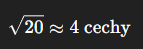

**Bootstrapping w Random Forest** (najważniejsze zastosowanie)

W Random Forest dla każdego drzewa:

- losujemy próbkową liczbę danych

- losujemy z powtórzeniami

- część danych powtarza się, część nigdy się nie pojawia

Statystycznie:
- 🔸 ok. 63% danych trafia do próbek bootstrapowych
- 🔸 ok. 37% danych nie trafia (tzw. OOB — out-of-bag samples)

Te 37% służy do:

estymacji błędu modelu bez użycia walidacji (oob_score=True)

📌 Dlaczego używamy losowania z powtórzeniem, a nie bez?

Bo chcemy, żeby:

- każde drzewo widziało inny zestaw danych,

- te zbiory się różniły,

- powstały niezależne modele.

Losowanie bez powtórzeń sprawiłoby, że każde drzewo widzi prawie ten sam zestaw, więc nie uzyskalibyśmy różnorodności.

---

**Czym jest Gini Impurity**

Gini Impurity (Nieczystość Giniego) to kluczowy wskaźnik używany przez algorytmy drzew decyzyjnych (takie jak CART – Classification and Regression Trees), aby zdecydować, w którym miejscu i na podstawie której cechy dokonać podziału danych.Mówiąc najprościej: Gini Impurity mierzy prawdopodobieństwo, że losowo wybrany element ze zbioru zostanie błędnie sklasyfikowany, jeśli przypiszemy mu etykietę zgodnie z rozkładem klas w tym zbiorze.

1. IntuicjaWyobraź sobie pudełko z kulkami:

- Jeśli w pudełku są same czerwone kulki, zbiór jest "czysty" (Gini = 0). Jeśli wyciągniesz kulkę i zgadniesz, że jest czerwona, zawsze będziesz mieć rację.

- Jeśli w pudełku jest pół kulek czerwonych i pół niebieskich, zbiór jest maksymalnie "nieczysty" (Gini = 0.5 dla dwóch klas). Ryzyko pomyłki przy losowaniu jest największe.

2. Matematyczna FormułaWzór na Gini Impurity dla węzła (zbioru) wygląda następująco:

$$G = 1 - \sum_{i=1}^{C} (p_i)^2$$

Gdzie:

- $C$ to liczba wszystkich klas.

- $p_i$ to prawdopodobieństwo (częstość występowania) klasy $i$ w danym węźle.

3. Przykład obliczeniowyZałóżmy, że mamy zbiór 10 zwierząt: 6 kotów i 4 psy.

- Obliczamy prawdopodobieństwa:$p_{kot} = 6/10 = 0.6$$p_{pies} = 4/10 = 0.4$

- Podstawiamy do wzoru:$$G = 1 - (0.6^2 + 0.4^2)$$$$G = 1 - (0.36 + 0.16)$$$$G = 1 - 0.52 = 0.48$$

- Wynik 0.48 mówi nam, że zbiór jest dość mocno wymieszany.

4. Jak Drzewo Decyzyjne wykorzystuje Gini?

Algorytm szuka takiego podziału (np. "czy zwierzę waży powyżej 5kg?"), który zminimalizuje Gini Impurity w powstałych węzłach potomnych. Proces ten nazywamy minimalizacją Weighted Gini Impurity.

Drzewo sprawdza wszystkie możliwe cechy i wszystkie możliwe punkty podziału, a wybiera ten, który daje największy spadek nieczystości (Gini Gain).

5. Gini Impurity vs EntropiaW bibliotekach takich jak Scikit-learn możesz wybrać między criterion='gini' a criterion='entropy'.

- Gini Impurity jest szybsza obliczeniowo, ponieważ nie wymaga wyliczania logarytmów (używa tylko potęgowania). Dlatego jest domyślnym wyborem w większości implementacji.

- Entropia bywa nieco bardziej czuła na zmiany w rozkładzie klas, ale w 99% przypadków oba kryteria dają niemal identyczne drzewa.

6. Kluczowe cechy techniczne

- Zakres: Dla klasyfikacji binarnej Gini mieści się w przedziale $[0, 0.5]$. Wartość $0$ oznacza idealną czystość, a $0.5$ idealne wymieszanie klas $50/50$.

- Wady: Gini Impurity ma tendencję do faworyzowania podziałów, które wyodrębniają jedną dużą klasę, co przy danych o dużej liczbie unikalnych wartości (wysoka kardynalność) może prowadzić do overfittingu.

---

**Feature Impotance**

W modelach opartych na drzewach decyzyjnych (Random Forest, XGBoost, LightGBM) Feature Importance to mechanizm, który pozwala nam zajrzeć do „czarnej skrzynki” i zrozumieć, które cechy miały największy wpływ na prognozy.

Warto jednak wiedzieć, że nie ma jednej uniwersalnej definicji "ważności". Wyróżniamy trzy główne podejścia do obliczania tej metryki:

1. Gini Importance (Mean Decrease Impurity)

To domyślna metoda w bibliotece Scikit-learn (Random Forest).

- Zasada działania: Przy każdym podziale w drzewie obliczany jest spadek "nieczystości" (Impurity), zazwyczaj mierzony indeksem Giniego lub Entropią.

- Mechanizm: Algorytm sumuje wszystkie spadki nieczystości wywołane przez daną cechę we wszystkich drzewach w lesie. Czym większy całkowity spadek wygenerowała cecha, tym jest ważniejsza.

- Wada: Silnie faworyzuje cechy o wysokiej kardynalności (np. ID użytkownika lub ciągłe liczby zmiennoprzecinkowe), nawet jeśli są one szumem.

2. Gain (Zysk) – Standard w modelach GradientowychGłównie stosowany w XGBoost i LightGBM.

- Zasada działania: Jest to techniczne rozwinięcie Gini Importance, ale dostosowane do optymalizacji funkcji straty.

- Mechanizm: Mierzy poprawę w funkcji celu (np. log-loss lub MSE) po dokonaniu podziału względem danej cechy. Jeśli podział na podstawie "Metrażu" drastycznie zmniejsza błąd modelu, to "Metraż" otrzymuje wysoki wynik Gain.

- Interpretacja: To najważniejsza metryka z punktu widzenia predykcji – mówi nam, ile informacji o celu ($y$) dostarcza dana kolumna.

3. Weight / Frequency (Częstotliwość)Najprostsza i czasem najbardziej zwodnicza metoda.

- Zasada działania: Liczy, ile razy dana cecha została użyta do wykonania podziału we wszystkich drzewach.

- Problem: Cecha może być używana bardzo często (np. binary "Płeć"), ale każdy jej podział może wnosić bardzo mało do końcowego wyniku. Z kolei inna cecha może być użyta tylko raz, ale idealnie rozdzielać dane.

4. Permutation Importance (Podejście Model-Agnostic)

To najbardziej "uczciwa" metoda, która nie zależy od wewnętrznej struktury drzewa.Zasada działania:

- Trenujemy model i mierzymy jego wynik (np. AUC).Wybieramy jedną cechę i losowo mieszamy (tasujemy) jej wartości w zbiorze testowym, niszcząc jej relację z celem, ale zachowując jej rozkład.

- Sprawdzamy, jak bardzo spadł wynik modelu.Logika: Jeśli po "zepsuciu" kolumny "Cena" wynik modelu drastycznie spadł, to znaczy, że model mocno na niej polegał. Jeśli wynik się nie zmienił – cecha była zbędna.

Pułapka: Cechy skorelowaneTo krytyczny moment dla inżyniera ML. Jeśli masz dwie cechy silnie skorelowane (np. "Metraż w m2" i "Metraż w stopach"), model może:

- Rozdzielić ważność między obie (obie będą wyglądać na średnio ważne).Przypisać całą ważność jednej, a drugą zignorować.

- Wniosek: Zanim zaczniesz analizować Feature Importance, zawsze sprawdź korelacje (Heatmap) i usuń duplikaty informacji, aby nie wyciągnąć błędnych wniosków biznesowych.

---

**Bagging = Bootstrap Aggregating**

To metoda budowy modeli, która:

- losuje wiele zestawów danych (bootstrap samples)

- trenuje na nich wiele niezależnych modeli

- łączy ich wyniki (średnia / głosowanie)

Bagging → redukuje wariancję i stabilizuje model.

🔧 Jak działa bagging krok po kroku?

Załóżmy, że masz zbiór 1000 obserwacji i chcesz zastosować bagging z 10 modelami.

KROK 1: Bootstrap sampling

- Dla każdego modelu tworzysz nowy zbiór danych, losując z powtórzeniem:

- model 1: 1000 wylosowanych próbek

- model 2: 1000 innych wylosowanych próbek

…

- model 10: kolejna wersja

Każdy model widzi inny zestaw danych, ale zawsze pełnej wielkości.

KROK 2: Trening wielu modeli

- Trenujesz 10 osobnych modeli (np. 10 drzew decyzyjnych).

Każde drzewo:

- widzi inne dane

- robi inne błędy

→ dzięki temu modele stają się niezależne.

KROK 3: Agregacja wyników

Dla klasyfikacji:

- używamy głosowania większościowego

Dla regresji:

- używamy średniej z wyników modeli

Efekt:

✔️ mniejsza wariancja

✔️ większa stabilność

✔️ mniejsza podatność na przeuczenie

**Co to jest OOB?**

Kiedy tworzysz bootstrap sample (np. 1000 obserwacji), to:

- losujesz z powtórzeniem 1000 razy

- statystycznie ok. 63% próbek trafi do losowania

- ok. 37% próbek nie zostanie nigdy wylosowane

Te niewylosowane obserwacje to właśnie:

⭐ OOB = Out-of-Bag samples

czyli dane, których dany model nie widział podczas trenowania.

🔧 Do czego służą próbki OOB?

W Random Forest i BaggingClassifier możesz ustawić:

oob_score=True

Wtedy:

- każde drzewo przewiduje etykiety dla swoich OOB samples

- model porównuje te przewidywania z prawdziwymi wartościami

- otrzymujesz OOB accuracy — dokładność ocenioną bez test setu

To działa jak wbudowana walidacja krzyżowa.

🎯 Zalety używania OOB

✔️ Nie potrzebujesz test splitu ani cross-validation

Model sam ocenia swoją skuteczność.

✔️ Bardzo oszczędne obliczeniowo

Nie trenujesz modelu wiele razy jak w cross-validation.

✔️ Dobre oszacowanie błędu generalizacji

Dokładne jak CV 5–10-fold.

📊 Intuicja działania OOB

Załóż, że trenowane jest jedno drzewo:

- Wylosowano 63% próbek → trenuje drzewo

- Pozostałe 37% → model używa ich tylko do oceny

Czyli:

To trochę tak, jakby każde drzewo miało swój własny test set.

Kiedy zbierzesz te oceny dla wszystkich drzew → dostajesz OOB accuracy.

---

**Boosting**

Boosting to proces, w którym:

👉 Modele są trenowane jeden po drugim, sekwencyjnie

👉 Każdy kolejny model uczy się naprawiać błędy poprzednich

👉 Modele mają różne wagi — lepsze dostają większą wagę w finale

👉 Wynik końcowy to zsumowane predykcje wszystkich modeli

Boosting = uczenie się na błędach.

Intuicja Boostingu

Wyobraź sobie ucznia rozwiązującego test:

- Robi test (model 1).

- Sprawdza, które zadania zrobił źle.

- Drugi raz skupia się tylko na trudnych zadaniach (model 2).

- Znowu sprawdza błędy i dopracowuje (model 3).

- Robi to wiele razy.

Efekt: uczeń robi się coraz lepszy w trudnych kwestiach.

To właśnie boosting.

📌 Główna idea

Boosting kładzie większą wagę na trudne obserwacje, te które poprzednie modele klasyfikowały źle.

---

**AdaBoost**

Jak działa AdaBoost — prosta intuicja

- Trenujesz pierwszy słaby model (zwykle małe drzewo — stump).

- Sprawdzasz, które obserwacje model przewidział źle.

- Zwiększasz wagi tych trudnych obserwacji, żeby kolejny model zwrócił na nie większą uwagę.

- Trenujesz drugi model — teraz bardziej skupiony na trudnych przykładach.

- Znowu aktualizujesz wagi.

- Budujesz trzeci model, czwarty, itd.

Na końcu wszystkie modele głosują, ale:

🔹 silniejsze modele mają większą wagę,

🔹 słabsze mają mniejszą.

AdaBoost = uczy się na błędach poprzednich.

--

**Algorytm**

Krok 1: Nadaj wszystkim próbom takie same wagi

- Każda obserwacja (przykład) ma wagę 

- $w_i = 1/N$

Na początku wszystkie przykłady są równie ważne

Krok 2: Trenuj pierwszy słaby model

- Używamy np. małego drzewa decyzyjnego (stump)

- Model uczy się danych z uwzględnieniem wag

Krok 3: Oblicz błąd ważony

- Sprawdzasz, które obserwacje model przewidział źle

- Błąd ważony = suma wag błędnych próbek

Jeśli model zrobił dużo błędów → będzie miał mniejszą wagę w końcowej decyzji

Jeśli model był dobry → jego głos będzie silniejszy

Krok 4: Oblicz wagę modelu

- Waga modelu 𝛼 zależy od jego dokładności

- Dobry model → większa waga

- Słaby model → mniejsza waga

Krok 5: Zaktualizuj wagi próbek

- Zwiększamy wagi dla przykładów, które zostały źle przewidziane

- Zmniejszamy wagi dla przykładów poprawnie przewidzianych

- Dzięki temu następny model skupi się na trudnych przypadkach

Krok 6: Powtarzaj proces

- Tworzysz kolejne słabe modele, każdy „uczący się na błędach” poprzedniego

- Zawsze aktualizujesz wagi obserwacji i przypisujesz wagę modelowi

Krok 7: Finalna predykcja

- Każdy model „głosuje” na klasę

- Głosy są ważone wagą modelu 𝛼

- Ostateczna decyzja = klasa, która wygrała w ważonym głosowaniu

---

**Gradient boosting**

Gradient boosting to potężna technika uczenia maszynowego, która buduje silny model poprzez "zespołowe" łączenie wielu prostych, "słabych" modeli, najczęściej drzew decyzyjnych.

Kluczową ideą jest to, że robi to sekwencyjnie: każdy kolejny model jest trenowany tak, aby poprawiał błędy popełnione przez poprzedników.

Wyobraź sobie, że próbujesz stworzyć system do idealnego przewidywania wagi osób na podstawie ich wzrostu, wieku i płci.

- Model 1 (Pierwsza próba): Tworzysz bardzo prosty model. Okazuje się, że jest dość niedokładny. Dla jednej osoby pomylił się o +10 kg, dla innej o -5 kg, a dla kolejnej o +3 kg. Te wartości (10, -5, 3) to błędy (nazywane w statystyce resztami).

- Model 2 (Specjalista od błędów): Teraz, zamiast budować nowy model do przewidywania wagi, budujesz model, który uczy się przewidywać... błędy pierwszego modelu. Ten model uczy się, że "dla takich osób, jak ta pierwsza, poprzedni model myli się o ok. +10 kg".

- Model 3 (Kolejny specjalista): Model 2 też nie jest idealny. Poprawił błędy, ale wygenerował nowe, mniejsze. Trzeci model uczy się więc poprawiać błędy pozostawione przez Model 2.

- Wynik końcowy: Powtarzasz ten proces wiele razy (np. 100). Aby uzyskać ostateczną prognozę, sumujesz przewidywania pierwszego modelu oraz wszystkich kolejnych "specjalistów od błędów".

Każdy kolejny model dodaje małą "cegiełkę" korygującą, aż cały zespół modeli razem staje się niezwykle precyzyjny.

Podstawą jest Gradient Descent (Prosty Spadek Gradientu). Wyobraź sobie, że stoisz na zboczu góry w gęstej mgle. Aby zejść do doliny (minimum funkcji), badasz stopą nachylenie terenu i robisz krok w stronę, gdzie spadek jest najostrzejszy.Matematycznie, aktualizacja parametrów wygląda następująco:$$\theta_{next} = \theta - \eta \cdot \nabla_\theta J(\theta)$$Gdzie:$\eta$ (eta) to Learning Rate (współczynnik uczenia) – długość kroku.$\nabla_\theta J(\theta)$ to gradient – wektor pochodnych cząstkowych, który wskazuje kierunek najszybszego wzrostu funkcji. Odejmujemy go, aby iść w stronę spadku.

**Warianty Gradient Descent**

W zależności od tego, ile danych używamy do obliczenia gradientu w jednym kroku, wyróżniamy:

- Batch Gradient Descent: Oblicza gradient na podstawie całego zbioru danych. Jest stabilny, ale przy milionach rekordów staje się niewyobrażalnie wolny i nie mieści się w pamięci RAM.

- Stochastic Gradient Descent (SGD): Oblicza gradient na podstawie jednego, losowego przykładu. Jest bardzo szybki, ale jego ścieżka do minimum jest "poszarpana" (duża wariancja), co może pomóc uciec z minimów lokalnych.

- Mini-batch Gradient Descent: Złoty środek. Oblicza gradient dla małych paczek danych (np. 32, 64, 128 próbek). Łączy stabilność Batcha z szybkością SGD i pozwala na wykorzystanie wektoryzacji obliczeń (GPU).

**Problemy Klasycznego Algorytmu**
Klasyczny spadek gradientu często zawodzi w dwóch przypadkach:

Saddle Points (Punkty siodłowe): Obszary, gdzie gradient jest bliski zeru, ale nie jesteśmy w minimum. Algorytm może tam "utknąć".

Plateaus (Płaskowyże): Bardzo małe nachylenie terenu sprawia, że nauka trwa wiecznie.

**Zaawansowane Optymalizatory (Momentum i Adaptacja)**
Aby rozwiązać powyższe problemy, wprowadzono algorytmy modyfikujące gradient:

A. Momentum (Pęd)
Zamiast patrzeć tylko na bieżący gradient, algorytm bierze pod uwagę poprzednie kroki. Działa to jak kula śnieżna staczająca się ze zbocza – nabiera prędkości w kierunkach spójnych i wygasza oscylacje w kierunkach prostopadłych.

B. AdaGrad (Adaptive Gradient)
Dostosowuje Learning Rate oddzielnie dla każdego parametru. Parametry, które otrzymują częste i duże aktualizacje, mają zmniejszany LR, a te rzadsze – zwiększany. Problem: LR z czasem maleje do zera, co zatrzymuje naukę.

C. RMSProp
Ulepszona wersja AdaGrad, która rozwiązuje problem zanikającego Learning Rate poprzez stosowanie średniej kroczącej kwadratów gradientów.

D. Adam (Adaptive Moment Estimation)
Obecnie standard w branży. Łączy koncepcję Momentum (średnia z gradientów) oraz RMSProp (średnia z kwadratów gradientów). Jest niezwykle efektywny i odporny na szum.

---

Gradient Boosting Machines (GBM) to jedna z najpotężniejszych technik w klasycznym Machine Learningu. W przeciwieństwie do Random Forest, który buduje drzewa niezależnie i wyciąga z nich średnią (Bagging), GBM buduje modele sekwencyjnie (Boosting).Oto szczegółowa analiza techniczna tego mechanizmu.

1. Intuicja: Uczenie się na błędachW GBM każde kolejne drzewo nie stara się przewidzieć bezpośrednio wartości docelowej ($y$), ale rezydua (błędy) poprzedników. Wyobraź sobie, że strzelasz do tarczy:

- Pierwszy strzał (pierwsze drzewo) trafia 10 cm od środka.

- Drugie drzewo nie celuje w środek, ale próbuje skorygować te 10 cm błędu.

- Trzecie drzewo koryguje to, co zostało po drugim strzale.

2. Matematyczny Mechanizm (Gradient Descent w przestrzeni funkcji)To tutaj pojawia się "Gradient" w nazwie. W standardowych sieciach neuronowych optymalizujemy parametry (wagi). W GBM optymalizujemy samą funkcję przewidującą.Jeśli mamy funkcję kosztu $L(y, F(x))$, to w każdym kroku $m$ chcemy dodać takie drzewo $h_m(x)$, które najlepiej przybliża ujemny gradient funkcji kosztu względem obecnych przewidywań:$$r_{im} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x)=F_{m-1}(x)}$$W przypadku błędu średniokwadratowego ($MSE$), ujemny gradient to po prostu różnica $(y_i - \hat{y}_i)$. Dlatego w regresji GBM po prostu dopasowuje kolejne drzewa do reszt (residuals).

3. Składowe algorytmu GBMAby GBM działał poprawnie i nie wpadał w overfitting, stosuje się kilka mechanizmów:

- Shrinkage (Learning Rate): Każde drzewo ma ograniczony wpływ na ostateczny wynik (zazwyczaj mnożymy jego przewidywania przez małą wartość $\eta$, np. 0.1 lub 0.01). Dzięki temu model uczy się wolniej, ale dokładniej.

- Weak Learners: Drzewa w GBM są zazwyczaj płytkie (tzw. stumps lub drzewa o głębokości 3–6). Silne, głębokie drzewa zbyt szybko dopasowałyby się do szumu.

- Loss Function: GBM jest elastyczny – możesz użyć $MSE$ dla regresji, Log-Loss dla klasyfikacji, czy MARE dla odporności na outliery.

1. XGBoost (eXtreme Gradient Boosting)

Działa w sposób poziomowy (level-wise).

Zasada: Buduje drzewo piętro po piętrze. Zanim przejdzie głębiej, musi rozwinąć wszystkie węzły na obecnym poziomie.

Klucz: Używa zaawansowanej matematyki (Hesjanu), aby bardzo precyzyjnie określić, jak silny powinien być podział w danym węźle. Jest jak architekt, który buduje solidny dom, sprawdzając dokładnie fundamenty każdego pokoju przed postawieniem dachu.

To była pierwsza biblioteka, która wprowadziła rewolucję w szybkości i precyzji. Jej kluczowe innowacje to:

- Regularyzacja ($L1$ i $L2$): W przeciwieństwie do klasycznego GBM, XGBoost ma wbudowaną funkcję celu, która zawiera kary za złożoność modelu. Pomaga to kontrolować overfitting.

- Aproksymacja gradientu drugiego rzędu: Podczas gdy klasyczny GBM używa tylko pierwszej pochodnej (gradientu), XGBoost używa rozwinięcia Taylora do drugiego rzędu (wykorzystuje Hesjan). Dzięki temu lepiej "rozumie" krzywiznę funkcji straty i szybciej zbiega do minimum.

- Algorytm Greedy (Sparse Aware): Świetnie radzi sobie z brakującymi danymi (sparse data), ucząc się domyślnego kierunku podziału dla braków w każdym węźle.

2. LightGBM (Light Gradient Boosting Machine)

Działa w sposób liściowy (leaf-wise).

Zasada: Nie buduje całego poziomu drzewa. Zamiast tego patrzy na wszystkie końcowe punkty (liście) i wybiera ten jeden, który daje największą redukcję błędu. Rozbudowuje tylko ten konkretny liść.

Klucz: Dzięki temu drzewa rosną asymetrycznie i bardzo szybko redukują błąd. Dodatkowo "skanuje" tylko najważniejsze dane (GOSS), co sprawia, że jest błyskawiczny. Jest jak sprinter, który wybiera tylko najkrótszą drogę do celu, ignorując poboczne ścieżki.

Microsoft stworzył LightGBM, aby rozwiązać problem prędkości XGBoosta na ogromnych zbiorach danych. Główne różnice:

- Leaf-wise vs. Level-wise Growth: Większość algorytmów buduje drzewa poziom po poziomie (level-wise). LightGBM wybiera liść, który daje największy spadek funkcji straty i rozwija go (leaf-wise). Może to prowadzić do większej głębokości, ale daje znacznie lepszą precyzję.

- GOSS (Gradient-based One-Side Sampling): LightGBM zachowuje wszystkie przykłady z dużymi gradientami (te, które sprawiają trudność), a losowo odrzuca część tych z małymi gradientami. Pozwala to trenować na znacznie mniejszej ilości danych przy minimalnej utracie jakości.

- EFB (Exclusive Feature Bundling): Łączy rzadkie cechy (sparse features), które rzadko występują jednocześnie, w jedną cechę, co drastycznie redukuje wymiarowość danych przed budową drzewa.

3. CatBoost (Categorical Boosting)

Działa na drzewach symetrycznych (oblivious trees).

Zasada: Na każdym poziomie drzewa używa tego samego warunku podziału (tej samej cechy) dla wszystkich węzłów. Drzewo jest idealnie zbalansowane.

Klucz: Taka struktura działa jak potężna regularyzacja – modelowi trudniej jest "nauczyć się na pamięć" szumu w danych. Dodatkowo posiada unikalny system przetwarzania kategorii (zamiana tekstu na liczby w locie), co sprawia, że "rozumie" dane tekstowe lepiej niż konkurenci.

Opracowany przez Yandex, skupia się na dwóch problemach: zmiennych kategorycznych i tzw. prediction shift.

- Ordered Boosting: Tradycyjny boosting cierpi na "wyciek danych" (leakage), ponieważ te same dane są używane do obliczenia gradientu i budowy modelu. CatBoost stosuje nowatorski mechanizm, który zapobiega overfittingowi na małych zbiorach danych.

- Native Categorical Handling: Nie musisz robić One-Hot Encodingu. CatBoost stosuje zaawansowane statystyki (Target Statistics) do zamiany kategorii na liczby, uwzględniając losowe permutacje danych, co jest o wiele skuteczniejsze niż proste metody.

- Symetryczne Drzewa (Oblivious Trees): CatBoost buduje drzewa, w których na danym poziomie zawsze używany jest ten sam warunek podziału dla wszystkich węzłów. To sprawia, że model jest bardzo stabilny i błyskawicznie wykonuje inferencję (przewidywanie).

---

**Testy w ML**

1. Testy A/B (Split Testing) – Klasyczny Pojedynek

To najprostsza metoda eksperymentalna. Polega na losowym podzieleniu ruchu na dwie grupy: jedną widzącą wersję obecną (Control) i drugą widzącą wersję ze zmianą (Treatment).

Jak to działa dokładnie?

- Izolacja zmiennej: Zmieniasz tylko jeden element (np. tylko cenę auta w ogłoszeniu, nie zmieniając zdjęć).

- Randomizacja: Użytkownik trafia do grupy A lub B całkowicie losowo (np. na podstawie ciasteczek).

- Weryfikacja statystyczna: Po zebraniu odpowiedniej liczby danych sprawdzasz, czy różnica w wynikach (np. klikalności) nie jest dziełem przypadku. Używa się tu testów statystycznych, takich jak t-test czy test chi-kwadrat.

- Zaleta: Najczystsza metoda naukową. Masz jasny dowód: „Zmiana X spowodowała wzrost Y”.

- Wada: Testuje tylko jedną rzecz na raz. Jeśli masz 10 pomysłów na poprawę strony, testowanie ich po kolei zajmie wieki.

2. Multivariate Testing (MVT) – Wielka Kombinatoryka

MVT to „A/B test na sterydach”. Zamiast testować jedną zmianę, testujesz wiele elementów i ich wzajemne interakcje jednocześnie.

Przykład: Chcesz zmienić na stronie swojego projektu dwa elementy:

- Nagłówek: (A) „Wyceń auto” vs (B) „Sprawdź wartość rynkową”.

- Kolor przycisku: (1) Niebieski vs (2) Zielony.

MVT stworzy 4 kombinacje (A1, A2, B1, B2) i podzieli ruch między nie równo.

Dlaczego to jest ważne? 

- Ponieważ może się okazać, że zielony przycisk działa świetnie z nagłówkiem B, ale tragicznie z nagłówkiem A. Testy A/B by tego nie wyłapały.

- Wada: Potrzebujesz ogromnego ruchu. Jeśli do wiarygodnego testu A/B potrzebujesz 10 000 osób, to do MVT z 4 wariantami będziesz potrzebował ich znacznie więcej, by wyniki w każdej „ćwiartce” były istotne statystycznie.

3. Multi-Armed Bandits (MAB) – Inteligentna Optymalizacja

Nazwa pochodzi od „jednorękich bandytów” w kasynie. Wyobraź sobie, że stoisz przed rzędem maszyn i chcesz wygrać jak najwięcej. Nie wiesz, która maszyna wypłaca najczęściej, więc musisz trochę pograć na każdej, żeby to sprawdzić (Exploration), ale jednocześnie chcesz jak najwięcej grać na tej, która już wydaje się najlepsza (Exploitation).

Jak to działa w IT?

- W przeciwieństwie do A/B testów, gdzie ruch jest sztywno podzielony (50/50) przez cały czas trwania testu, algorytm MAB (np. Thompson Sampling lub Epsilon-Greedy) uczy się w czasie rzeczywistym.

- Zaczynamy od podziału 50/50.

- Model widzi, że wersja B radzi sobie lepiej po pierwszej godzinie.

- Zamiast czekać do końca tygodnia, algorytm automatycznie zaczyna kierować więcej ruchu do wersji B (np. 60/40, potem 80/20).

- Zaleta: Minimalizujesz straty. Nie marnujesz 50% ruchu na gorszą wersję przez cały tydzień.

- Zastosowanie: Idealne przy krótkich kampaniach (np. Black Friday), gdzie nie masz czasu na tydzień testów, bo okazja minie.

---

**Naive Bayes**

Naive Bayes to grupa bardzo szybkich i prostych klasyfikatorów, które opierają się na twierdzeniu Bayesa oraz założeniu o niezależności cech.

Dlaczego „Naive”?

Bo model zakłada, że:

➡️ wszystkie cechy są od siebie niezależne

Na przykład:

słowo „free” i „win” występujące w mailu mogą zależeć od siebie

ale Naive Bayes zakłada, że są niezależne

To oczywiście nie jest prawdziwe — stąd nazwa naiwny.

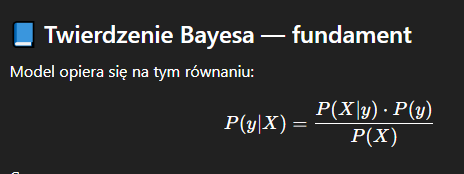

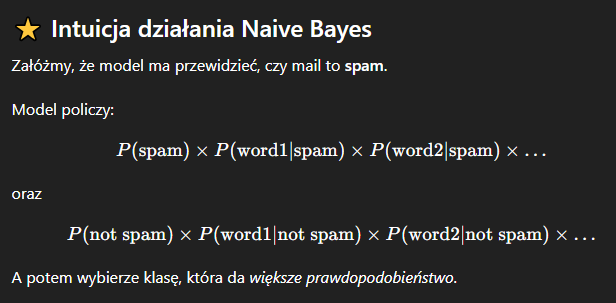

--

**NLP**

NLP (Natural Language Processing) to dziedzina sztucznej inteligencji zajmująca się przetwarzaniem i analizą języka naturalnego — czyli ludzkiego języka (tekstu lub mowy).

➜ NLP = uczenie maszynowe + język ludzki

Najpopularniejsze zastosowanie: wykrywanie SPAMu
Jak to działa:

- Zbiór maili oznaczonych jako SPAM / HAM

- Zamiana tekstu na liczby (CountVectorizer lub TF-IDF)

- Trening Naive Bayes (MultinomialNB)

- Model oblicza:

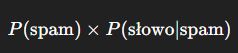

- oraz:

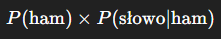

- Mail trafia do tej klasy, która daje większe prawdopodobieństwo.

--

**Feature extraction from text**

Kiedy pracujemy z tekstem (mailami, tweetami, artykułami), komputer nie rozumie słów.

Aby model ML mógł analizować tekst, musimy zamienić go na liczby — czyli cechy.

➡️ Feature extraction from text to proces zamiany tekstu na reprezentację liczbową, którą mogą wykorzystać algorytmy uczenia maszynowego.

Musimy stworzyć liczby, np.:

| słowo | wystąpienia |
| ----- | ----------- |
| free  | 1           |
| money | 1           |
| now   | 1           |
| offer | 0           |
| win   | 0           |

Metody:

1. Bag of Words (CountVectorizer)

Model liczy ile razy każde słowo występuje.

Przykład:

Teksty:

"free money now"

"win money now"

Słownik (vocabulary):
["free", "win", "money", "now"]

Macierz cech:

| free | win | money | now |
| ---- | --- | ----- | --- |
| 1    | 0   | 1     | 1   |
| 0    | 1   | 1     | 1   |

2. TF-IDF (Term Frequency – Inverse Document Frequency)

Lepsze niż Bag of Words, bo:

- częste słowa → mniejsza waga (“the”, “and”, “to”)

- rzadkie, ważne słowa → większa waga (“free”, “discount”, “urgent”)

---

**Ciąg dalszy o TF-IDF i Bag of Words i innych technologiach**

1. Bag of Words (BoW) – Worki ze słowami

To najbardziej intuicyjna metoda zamiany tekstu na liczby. Wyobraź sobie, że masz worek, do którego wrzucasz wszystkie słowa z tekstu, ignorując ich kolejność, gramatykę i kontekst. Liczy się tylko ile razy dane słowo wystąpiło.

Jak to działa?

- Tworzysz słownik (vocalubary) wszystkich unikalnych słów ze wszystkich swoich dokumentów.

- Każdy dokument reprezentujesz jako wektor o długości równej wielkości słownika.

- Wpisujesz w odpowiednie miejsce liczbę wystąpień słowa.

- Wada: BoW traktuje słowa „dom” i „domy” jako dwa zupełnie różne byty, a słowa „i”, „w”, „z” (stop-words) mają najwyższe wartości, mimo że niosą najmniej informacji.

2. N-grams (N-gramy)

To prosta modyfikacja BoW, która próbuje uratować kontekst lokalny. Zamiast wycinać pojedyncze słowa, wycinasz ich ciągi o długości $n$.

- Unigrams ($n=1$): „auto”, „jest”, „bezwypadkowe”.

- Bigrams ($n=2$): „auto jest”, „jest bezwypadkowe”.

- Trigrams ($n=3$): „auto jest bezwypadkowe”.

Dlaczego to ważne? 

W Twoim projekcie Otomoto słowo „nie” i „uszkodzony” osobno znaczą coś innego niż bigram „nie uszkodzony”. N-gramy pozwalają modelowi wyłapać takie proste związki frazeologiczne.

3. TF-IDF (Term Frequency – Inverse Document Frequency)

To „inteligentne” liczenie słów. TF-IDF nakłada na słowa wagi, dzięki czemu model wie, które wyrazy są naprawdę unikalne i ważne dla danego opisu, a które są tylko „szumem” językowym.

Matematyka za modelem:

Wynik to iloczyn dwóch składowych:

- TF (Term Frequency): Jak często słowo $t$ pojawia się w dokumencie $d$? $$TF(t, d) = \frac{\text{liczba wystąpień } t \text{ w } d}{\text{łączna liczba słów w } d}$$

- IDF (Inverse Document Frequency): Jak rzadko słowo $t$ pojawia się w całym zbiorze dokumentów $D$?$$IDF(t, D) = \log\left(\frac{|D|}{|\{d \in D : t \in d\}|}\right)$$

Intuicja: 

- Jeśli słowo „klimatyzacja” występuje w prawie każdym ogłoszeniu na Otomoto, jego IDF będzie bliskie zeru. Jeśli jednak słowo „Webasto” pojawia się tylko w kilku ogłoszeniach, jego waga TF-IDF będzie bardzo wysoka w tych konkretnych dokumentach. To sygnał dla modelu: „Hej, to auto ma coś specjalnego!”.

4. Word Embeddings (Word2Vec / GloVe)

To przeskok do „wyższej ligi”. Tutaj rezygnujemy z prostego liczenia. Zamiast tego mapujemy słowa do gęstych wektorów liczb rzeczywistych w wielowymiarowej przestrzeni (np. 300 wymiarów).

Word2Vec (Google)

- Model ten uczy się znaczenia słowa poprzez jego sąsiedztwo. Wykorzystuje do tego dwie architektury:

    - CBOW (Continuous Bag of Words): Przewiduje słowo na podstawie otaczających go słów.

    - Skip-gram: Przewiduje otaczające słowa na podstawie wybranego słowa.

GloVe (Global Vectors - Stanford)

Podczas gdy Word2Vec patrzy lokalnie na okno sąsiadujących słów, GloVe analizuje globalną macierz współwystępowania słów w całym korpusie tekstów.

Dlaczego to jest przełomowe?

- Wektory te mają właściwości semantyczne. Podobne słowa lądują blisko siebie w przestrzeni (mają wysokie Cosine Similarity).

- Możesz wykonywać na nich operacje matematyczne:$$\text{Król} - \text{Mężczyzna} + \text{Kobieta} \approx \text{Królowa}$$

---

**Podobieństwa i odległości**

1. Cosine Similarity (Podobieństwo Kosinusowe)

To miara, która mierzy kąt między dwoma wektorami, a nie ich długość.

- Zasada: Jeśli dwa wektory są identyczne, kąt między nimi wynosi $0^\circ$, a ich kosinus to 1. Jeśli są prostopadłe, kosinus wynosi 0. Jeśli są całkowicie przeciwne, wynosi -1.

Wzór:

$$\text{similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$

Dlaczego to jest genialne w NLP (tekstach)?

- Wyobraź sobie, że masz dwa artykuły o samochodach. Jeden ma 100 słów, drugi 5000 słów. Wersja 5000 słów będzie miała znacznie większe wartości w wektorze (bo słowo „silnik” występuje tam częściej). Zwykły dystans (Euklidesowy) uznałby, że te teksty są od siebie bardzo dalekie. Kosinus to zignoruje – skupi się na tym, że oba teksty używają słów o samochodach w podobnych proporcjach.

2. Euclidean Distance (Dystans Euklidesowy)

To „zwykła” odległość w linii prostej między dwoma punktami, którą znasz z lekcji geometrii.

- Zasada: Wylicza pierwiastek z sumy kwadratów różnic między współrzędnymi.

Wzór:

$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

Kiedy używać?

- Gdy wielkość (skala) ma znaczenie. Na przykład w Twoim projekcie Otomoto: jeśli porównujesz dwa auta, przebieg 10 000 km a 300 000 km to gigantyczna różnica fizyczna, której nie chcesz ignorować „kątem”.

3. Manhattan Distance (L1 / Taxicab)

Nazywany dystansem taksówkarza, bo przypomina poruszanie się po siatce ulic Manhattanu – nie możesz przejść „na skróty” przez budynek, musisz iść wzdłuż osi (prawo/lewo, góra/dół).

- Zasada: Suma wartości bezwzględnych różnic między współrzędnymi.

Kiedy używać?

- Często w systemach rekomendacyjnych lub gdy Twoje dane mają bardzo dużo wymiarów (tzw high-dimensional data), gdzie dystans euklidesowy zaczyna tracić sens przez „przekleństwo wymiarowości”.

4. Jaccard Similarity (Podobieństwo Jaccarda)

To miara używana głównie do zbiorów (np. słów w tekście lub tagów).

- Zasada: Dzieli liczbę elementów wspólnych dla obu zbiorów przez liczbę wszystkich unikalnych elementów w obu zbiorach.

Wzór:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

- Przykład:

    - Zbiór 1: {klima, skóra, automat}

    - Zbiór 2: {klima, szyberdach, automat}

    - Jaccard: 2 elementy wspólne / 4 unikalne łącznie = 0.5.

5. Pearson Correlation (Korelacja Persona)

To w zasadzie wyśrodkowane podobieństwo kosinusowe.

- Zasada: Zanim policzy kąt między wektorami, odejmuje od nich średnią.

- Zastosowanie: Świetne w systemach rekomendacyjnych (np. Netflix). Jeśli Ty oceniasz filmy w skali 1-5, a Twój kolega 4-10, korelacja Persona zrozumie, że obaj lubicie te same filmy, mimo że macie inne skale oceniania.

---

**Odległości i Silhouette score**

1. Odległość Minkowskiego (Minkowski Distance)

Odległość Minkowskiego to nie jedna miara, ale uogólniony wzór matematyczny, z którego wywodzą się inne, najpopularniejsze odległości.

Wzór ogólny: $$d(x, y) = \left( \sum_{i=1}^n |x_i - y_i|^p \right)^{1/p}$$

Wartość parametru $p$ decyduje o tym, jaką „geometrię” przyjmujemy:

A. Odległość Manhattańska ($p = 1$)

- Nazywana też L1 lub Taxicab distance. Nazwa pochodzi od siatki ulic Manhattanu – aby dostać się z punktu A do B, taksówka nie może przejechać na wskroś przez budynki, musi jechać wzdłuż osi (prawo/lewo, góra/dół).

- Wzór: Suma wartości bezwzględnych różnic: $d = |x_1 - y_1| + |x_2 - y_2| + \dots$

- Kiedy stosować? Świetna dla danych o bardzo wielu wymiarach oraz danych, w których występują outliery (wartości odstające), ponieważ nie podnosi różnic do kwadratu, więc nie „wyolbrzymia” dużych błędów.

B. Odległość Euklidesowa ($p = 2$)

- Nazywana L2. To klasyczna odległość „w linii prostej”, którą znasz ze szkoły (twierdzenie Pitagorasa).

- Wzór: Pierwiastek z sumy kwadratów różnic: $d = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \dots}$

- Kiedy stosować? To standard w większości algorytmów. Najlepiej sprawdza się, gdy dane są zagęszczone w „kulkach” lub sferach.

C. Odległość Czebyszewa ($p \to \infty$)

- Wyobraź sobie króla na szachownicy. Może on przejść na dowolne sąsiednie pole (pionowo, poziomo lub na skos) w jednym ruchu. Odległość Czebyszewa to po prostu największa różnica na dowolnej z osi.

- Wzór: $d = \max(|x_i - y_i|)$2. 

2. Silhouette Score (Współczynnik Sylwetki)

Kiedy używasz algorytmów grupujących (np. K-Means), potrzebujesz miary, która powie Ci: „czy te klastry mają sens?”. Silhouette Score to jedna z najlepszych metryk do tego celu.

Jak to działa?

- Dla każdego punktu w zbiorze danych obliczamy dwie wartości:

    - $a(i)$ (Cohesion): Średnia odległość punktu do wszystkich innych punktów w tym samym klastrze. Chcemy, aby ta wartość była jak najmniejsza (punkty blisko siebie).

    - $b(i)$ (Separation): Średnia odległość punktu do punktów z najbliższego sąsiedniego klastra. Chcemy, aby ta wartość była jak największa (klastry daleko od siebie).

- Wzór dla jednego punktu: $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

- Interpretacja wyniku (od -1 do 1): 

    - Blisko 1: Punkt jest świetnie przypisany. Leży głęboko w swoim klastrze i daleko od innych.

    - Około 0: Punkt leży na granicy dwóch klastrów. Decyzja o przypisaniu była „na styku”.

    - Blisko -1: Punkt prawdopodobnie trafił do złej grupy – jest bliżej sąsiedniego klastra niż swojego własnego.

---

1. Jak działa Optymalizacja Bayesowska? (Metafora z grzybami)
Wyobraź sobie, że szukasz grzybów w wielkim, nieznanym lesie:

Grid Search: Dzielisz las na kwadraty 1x1 metr i sprawdzasz każdy po kolei. Zmarnujesz tygodnie.

Random Search: Teleportujesz się w 50 losowych miejsc w lesie. Znajdziesz coś, ale może pominiesz najlepszą polanę.

Optymalizacja Bayesowska: Idziesz w 5 losowych miejsc. Zauważasz, że w dwóch z nich – tam gdzie jest wilgotno i rosną dęby – znalazłeś prawdziwki. Twój mózg tworzy matematyczną mapę prawdopodobieństwa (tzw. model zastępczy / surrogate model). Następny krok zrobisz tam, gdzie mapa podpowiada największą szansę na sukces, ale od czasu do czasu sprawdzisz zupełnie nowy teren, żeby upewnić się, że nie omijasz czegoś lepszego.

Algorytm nieustannie balansuje między dwoma celami:

Eksploatacja (Exploitation): Szukanie parametrów blisko tych, które już dały świetne wyniki.

Eksploracja (Exploration): Sprawdzanie zupełnie nowych obszarów na wypadek, gdyby ukrywał się tam jeszcze lepszy wynik.

2. Czym jest Optuna?
Optuna to obecnie najpopularniejsza, najpotężniejsza i najnowocześniejsza biblioteka w Pythonie, która wykonuje dla Ciebie tę Optymalizację Bayesowską (i nie tylko). Zastąpiła starsze narzędzia (jak np. Hyperopt).

Optuna pod maską domyślnie używa konkretnego, bardzo skutecznego algorytmu o nazwie TPE (Tree-structured Parzen Estimator), który sprytnie kategoryzuje parametry na te "dające dobre wyniki" i "dające złe wyniki".

3. Dlaczego Optuna to absolutny "Game Changer"?
Poza samym byciem "mądrzejszą" od Grid/Random Search, Optuna ma funkcje, które ratują życie i budżet chmurowy w projektach ML:

Pruning (Przycinanie / Wczesne zatrzymywanie): To najważniejsza funkcja Optuny. Wyobraź sobie, że trenujesz sieć neuronową. Już po 5 epokach z 100 Optuna widzi, że błąd (loss) jest ogromny i ten model nie ma szans dogonić najlepszego z poprzednich prób. Co robi? Zabija ten proces w trakcie. Grid/Random Search bezmyślnie doliczyłyby do 100 epok, marnując Twój czas i prąd.

Architektura "Define-by-run": Możesz budować dynamiczne przestrzenie poszukiwań przy użyciu zwykłych instrukcji if w Pythonie. Na przykład: "Optuno, najpierw wylosuj, czy używamy algorytmu Random Forest, czy SVM. Jeśli wylosujesz Random Forest, szukaj najlepszej głębokości drzewa. Jeśli wylosujesz SVM, szukaj najlepszego parametru C".

Łatwość wznawiania: Przerwało Ci zasilanie po 3 godzinach szukania parametrów? Żaden problem. Optuna zapisuje całą historię do bazy danych (np. pliku SQLite) i potrafi wznowić poszukiwania od miejsca, w którym skończyła.

**MultinomialNB**

To odmiana algorytmu Naive Bayes, która zakłada, że dane wejściowe są:

✔ liczbami całkowitymi

✔ najczęściej zliczeniami słów

✔ np. z macierzy CountVectorizer lub TF-IDF

Jak działa MultinomialNB?

1. Liczy częstość słów w dokumentach

np. CountVectorizer zmienia tekst na liczby:

| słowo | dokument1 | dokument2 |
| ----- | --------- | --------- |
| good  | 2         | 0         |
| bad   | 0         | 3         |
| movie | 1         | 1         |

2. Dla każdej klasy oblicza prawdopodobieństwo słów
np.

- P(word="good" | positive) = 0.3

- P(word="good" | negative) = 0.01

3. Dla nowego tekstu oblicza:

Jak bardzo prawdopodobne, że tekst należy do każdej klasy

4. Wybiera klasę z najwyższym prawdopodobieństwem.

---

**PCA**

1. Przekleństwo wymiarowości (Curse of Dimensionality)

„Przekleństwo wymiarowości” to termin określający zestaw problemów, które pojawiają się, gdy analizujemy dane w przestrzeniach o bardzo dużej liczbie wymiarów (cech/kolumn). Intuicja podpowiada, że im więcej cech podamy modelowi, tym lepiej powinien on rozumieć obiekt. W rzeczywistości jest odwrotnie.

Główne problemy:

- Rzadkość danych (Sparsity): W miarę dodawania wymiarów, objętość przestrzeni rośnie wykładniczo, a liczba dostępnych danych zazwyczaj pozostaje stała. Powoduje to, że punkty danych stają się od siebie niesamowicie oddalone.

- Przykład: Jeśli masz 10 punktów na linii o długości 10 m, są one blisko. Jeśli te same 10 punktów rozrzucisz w sześcianie 10x10x10 m, będą od siebie bardzo daleko. W 100 wymiarach przestrzeń jest niemal pusta.

- Zniekształcenie odległości: W wysokich wymiarach różnica między odległością do najbliższego sąsiada a odległością do najdalszego sąsiada staje się minimalna. Wszystkie punkty wydają się być „tak samo daleko”. To sprawia, że algorytmy oparte na dystansie (np. KNN czy K-średnie) przestają działać, bo nie potrafią odróżnić punktów podobnych od niepodobnych.

- Ryzyko przeuczenia (Overfitting): Przy ogromnej liczbie cech model łatwo znajduje „przypadkowe” korelacje, które nie istnieją w rzeczywistości, a są jedynie szumem statystycznym. Model „wykuwa dane na pamięć”, zamiast się ich uczyć.

2. PCA – Analiza Składowych Głównych (Principal Component Analysis)

PCA to najpopularniejsza technika redukcji wymiarowości. Jej celem jest „ściśnięcie” danych z np. 100 wymiarów do 2 lub 3, zachowując przy tym jak najwięcej informacji (czyli zmienności/wariancji).

Jak działa PCA „na chłopski rozum”?

Wyobraź sobie, że masz chmurę punktów w 3D (kształt cygara). PCA próbuje znaleźć taki kąt patrzenia, z którego ta chmura jest najlepiej widoczna – czyli taki, gdzie punkty są najbardziej rozproszone.

Techniczne kroki PCA:

- Standaryzacja: Dane muszą mieć średnią 0 i odchylenie 1, aby cechy o większych liczbach (np. cena) nie zdominowały cech o małych liczbach (np. wiek).

- Obliczenie macierzy kowariancji: Sprawdzamy, jak poszczególne cechy zmieniają się względem siebie (czy rosną razem, czy na odwrót).

- Wyznaczenie wektorów i wartości własnych (Eigenvectors & Eigenvalues):

    - Wektory własne wskazują nowe kierunki (osie), zwane Składowymi Głównymi (PC). Pierwsza składowa (PC1) to kierunek, w którym dane „rozciągają się” najbardziej.

    - Wartości własne określają, ile informacji (wariancji) niesie dany wektor.

- Sortowanie i wybór: Szeregujemy składowe od najważniejszej do najmniej ważnej. Możemy np. zostawić tylko dwie pierwsze, które tłumaczą 90% zmienności danych.

- Projekcja: Przerzucamy oryginalne dane na nowe, wybrane osie.

Dlaczego używamy PCA?

- Walka z przekleństwem wymiarowości: Usuwamy szum i cechy mało istotne.

- Wizualizacja: Możemy narysować dane 50-wymiarowe na zwykłym wykresie 2D.

- Przyspieszenie modeli: Modele uczą się znacznie szybciej na 5 składowych niż na 500 surowych cechach.

- Kompresja: Oszczędzamy miejsce w pamięci.

3. t-SNE (t-distributed Stochastic Neighbor Embedding)To algorytm typu Manifold Learning. Nie dba o wariancję, ale o zachowanie lokalnych sąsiedztw.

- Jak to działa: Próbuje dopasować punkty w 2D lub 3D tak, aby te, które były blisko siebie w 1000D, pozostały blisko siebie w niskim wymiarze. Używa rozkładu t-Studenta, aby zapobiegać "stłoczeniu" punktów w środku mapy.

- Zastosowanie: Głównie wizualizacja. Świetnie pokazuje klastry (np. grupy cyfr w zbiorze MNIST).

- Wada: Nie zachowuje struktury globalnej (odległości między odległymi klastrami są przypadkowe). Jest też wolne i niedeterministyczne (każdy run może wyglądać inaczej).

4. UMAP (Uniform Manifold Approximation and Projection)Obecnie uważany za następcę t-SNE. Opiera się na zaawansowanej topologii (teoria symplicjalna).

- Dlaczego jest lepszy? Jest znacznie szybszy niż t-SNE i, co najważniejsze, zachowuje strukturę globalną. Jeśli masz dwa klastry danych, które w rzeczywistości są do siebie podobne, na mapie UMAP będą one blisko siebie, podczas gdy w t-SNE mogłyby być po przeciwnych stronach wykresu.

- Stabilność: Jest bardziej powtarzalny i pozwala na rzutowanie nowych, niewidzianych wcześniej danych na stworzoną już mapę (czego t-SNE nie potrafi).

---

### Teoria i praktyka - szeregi czasowe

#### ARIMA & SARIMA

1. ARIMA: Rozbicie na czynniki pierwsze

ARIMA to tak naprawdę „składak” trzech różnych mechanizmów. Każda litera w nazwie odpowiada za inny sposób patrzenia na przeszłość danych.

- AR (AutoRegressive) – Parametr $p$Model „autoregresyjny” zakłada, że przyszłość zależy od przeszłości. Jeśli wczoraj i przedwczoraj sprzedaż rosła, to dzisiaj pewnie też będzie wysoka. Intuicja: Wykorzystujemy poprzednie wartości (lags) jako cechy (features) do przewidzenia obecnej wartości. Wzór: $Y_t$ jest funkcją $Y_{t-1}, Y_{t-2}, \dots, Y_{t-p}$.

- I (Integrated) – Parametr $d$Większość modeli statystycznych wymaga, aby dane były stacjonarne (czyli ich średnia i wariancja nie zmieniały się w czasie). Większość realnych danych (np. ceny akcji) ma trend – idą w górę lub w dół.Intuicja: „Integracja” to odejmowanie poprzedniej wartości od obecnej ($Y_t - Y_{t-1}$), aby pozbyć się trendu i sprawić, by dane stały się płaskie (stacjonarne). $d$ to liczba takich operacji (różnicowań) potrzebnych do uspokojenia wykresu.

- MA (Moving Average) – Parametr $q$Nie mylić ze zwykłą średnią kroczącą! W ARIMA model MA patrzy na błędy prognozy z przeszłości.Intuicja: Jeśli wczoraj model mocno się pomylił (np. nagły skok popytu), MA bierze ten błąd pod uwagę, aby „skorygować” dzisiejszą prognozę.Wzór: $Y_t$ zależy od błędów $\epsilon_{t-1}, \epsilon_{t-2}, \dots, \epsilon_{t-q}$.

2. SARIMA: Dodajemy Sezonowość ($S$)

Zwykła ARIMA gubi się, gdy dane mają cykle (np. sprzedaż lodów rośnie co lato, a zniczy co listopad). Tu wkracza SARIMA (Seasonal ARIMA).

SARIMA dodaje drugi zestaw parametrów $(P, D, Q, s)$, które działają identycznie jak te powyżej, ale na interwałach sezonowych. $s$: Długość sezonu (np. 12 dla danych miesięcznych z cyklem rocznym).

Przykład: Model SARIMA przewidując sprzedaż w grudniu 2025, patrzy nie tylko na listopad 2025 (ARIMA), ale też na grudzień 2024 (Seasonal AR).

3. Jak to działa w praktyce (Workflow)

Jako Data Scientist nie strzelasz parametrami na oślep. Proces zazwyczaj wygląda tak:

- Analiza stacjonarności: Robisz test Dickeya-Fullera. Jeśli dane nie są stacjonarne – różnicujesz je (ustalasz $d$).

- Identyfikacja rzędów ($p$ i $q$): Patrzysz na dwa kluczowe wykresy:

    - ACF (Autocorrelation Function): Pomaga ustalić $q$ (część MA).

    - PACF (Partial Autocorrelation Function): Pomaga ustalić $p$ (część AR).

- Estymacja parametrów: Model dopasowuje wagi (współczynniki) tak, aby zminimalizować błąd.

- Diagnostyka reszt: Sprawdzasz, czy błędy, które zostały (reszty), są „białym szumem” (czyli są całkowicie losowe). Jeśli w błędach wciąż widać jakiś wzorzec – model jest do poprawki.

---

#### Jak działa Prophet

Prophet to biblioteka stworzona przez zespół Data Science Facebooka (teraz Meta), która zrewolucjonizowała podejście do prognozowania w biznesie. Podczas gdy ARIMA opiera się na matematycznych zależnościach między kolejnymi punktami (opóźnienia, błędy), Prophet traktuje szereg czasowy jak zadanie dopasowania krzywej (curve-fitting).

1. Fundament: Model AdytywnyProphet rozbija szereg czasowy na cztery główne komponenty, które po prostu sumuje ze sobą. Matematycznie wygląda to tak:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

Gdzie: $g(t)$ (Trend): Modeluje zmiany długoterminowe (wzrost lub spadek). $s(t)$ (Seasonality): Odpowiada za okresowe wzorce (dzień tygodnia, miesiąc, rok). $h(t)$ (Holidays): Uwzględnia nieregularne wydarzenia, jak święta czy Black Friday. $\epsilon_t$ (Error): Szum, którego model nie potrafi wyjaśnić.

2. Co sprawia, że Prophet jest wyjątkowy?

- Punkty zmiany (Changepoints): W przeciwieństwie do sztywnej regresji, Prophet automatycznie wykrywa momenty, w których trend nagle się zmienia (np. wejście nowego konkurenta na rynek lub zmiana algorytmu). Model "pozwala" linii trendu załamać się w tych punktach, co sprawia, że jest niesamowicie elastyczny.

- Sezonowość oparta na szeregach Fouriera: Zamiast sztywnych reguł, Prophet używa sumy funkcji sinus i cosinus, aby przybliżyć skomplikowane cykle sezonowe. Dzięki temu świetnie radzi sobie z danymi, gdzie np. w weekendy dzieje się coś zupełnie innego niż w dni powszednie.

- Odporność na braki i błędy: Prophet jest "pancerny". Jeśli w Twoich danych brakuje miesiąca albo masz nagły, nielogiczny skok (outlier), model po prostu to zignoruje i będzie dalej dopasowywał krzywą do reszty punktów. ARIMA w takiej sytuacji często "wyrzuca błąd" lub daje absurdalne wyniki.

- Wzrost logistyczny (Saturacja): Możesz ustawić modelowi "sufit" (Cap) i "podłogę" (Floor). Jeśli wiesz, że rynek ma ograniczoną pojemność i Twoja sprzedaż nie może rosnąć w nieskończoność, Prophet wyhamuje trend w odpowiednim momencie.

---

1. Lagi (Lags) – Pamięć szeregu

Lagi (opóźnienia) to po prostu wartości z przeszłości przesunięte do przodu. To najprostszy sposób, by powiedzieć modelowi: "to, co dzieje się dzisiaj, zależy od tego, co działo się wczoraj".

- Lag 1 ($y_{t-1}$): Wartość z wczoraj.

- Lag 7 ($y_{t-7}$): Wartość sprzed tygodnia (kluczowa, jeśli masz cykle tygodniowe).

Przykład w Twoim projekcie Otomoto: Jeśli chcesz przewidzieć cenę Volkswagena Golfa dzisiaj, jednym z Twoich "predyktorów" (kolumn) może być średnia cena tego modelu sprzed miesiąca. To jest właśnie Lag 30.

2. Window Functions – Statystyki kroczące

Funkcje okna (inaczej Rolling Statistics) polegają na przesuwaniu "okna" o określonej szerokości nad danymi i wyliczaniu dla niego statystyki (średniej, sumy, odchylenia).

- Rolling Mean (Średnia krocząca): Wygładza wykres, eliminując chwilowy szum. Pozwala modelowi zobaczyć lokalny trend.

- Rolling Std (Odchylenie kroczące): Mówi modelowi o zmienności (woaltylności). Jeśli odchylenie rośnie, na rynku dzieje się coś nerwowego.

Dlaczego to jest lepsze niż zwykły Lag?Pojedynczy Lag jest bardzo podatny na błędy (np. wczoraj ktoś wystawił auto za bezcen przez pomyłkę). Rolling Mean z 7 dni bierze pod uwagę cały ostatni tydzień, dając modelowi znacznie stabilniejszy sygnał.

3. Fourier Terms – Sezonowość w falach

To najbardziej techniczne pojęcie. Szeregi Fouriera służą do modelowania skomplikowanej sezonowości za pomocą funkcji sinus i cosinus. Zamiast tworzyć 365 kolumn typu "czy to 1 stycznia?", "czy to 2 stycznia?", tworzymy kilka par fal (sinusów i cosinusów) o różnej częstotliwości. Suma tych fal potrafi idealnie odzwierciedlić np. to, że sprzedaż aut rośnie na wiosnę, lekko spada w wakacje i znów rośnie przed końcem roku.

Dlaczego to jest ważne?

- Dla modelu Prophet: To jego główny silnik do liczenia sezonowości rocznej.

- Oszczędność miejsca: Zamiast dziesiątek kolumn kategorycznych (miesiące, kwartały), masz np. 4 lub 10 kolumn z falami Fouriera, które niosą tę samą informację w sposób ciągły.

---

#### Time Series Split

Time Series Split (często nazywany Walk-Forward Validation lub Rolling Origin Validation) to specjalny sposób dzielenia danych na zbiór treningowy i testowy, który jest absolutnie kluczowy, gdy pracujesz z czasem.

W zwykłym uczeniu maszynowym (np. rozpoznawanie kotów na zdjęciach) kolejność danych nie ma znaczenia. W szeregach czasowych kolejność jest wszystkim.

1. Dlaczego zwykły K-Fold Cross-Validation tu nie działa?

- W standardowej walidacji krzyżowej (K-Fold) dane są mieszane losowo i dzielone na $k$ części. Jedna część to test, reszta to trening.

- Problem: Jeśli losowo przemieszasz dane czasowe, Twój model może uczyć się na danych z przyszłości (np. z grudnia 2025), aby "przewidzieć" to, co stało się w przeszłości (np. w marcu 2025).W świecie rzeczywistym to niemożliwe.

- W nauce nazywa się to Data Leakage (wyciek danych). Model będzie miał genialne wyniki podczas testów, ale całkowicie polegnie w produkcji, bo "podglądał" przyszłość.

2. Jak działa Time Series Split?

Zamiast losowo wybierać punkty, Time Series Split tworzy "kaskadę" zbiorów, zachowując naturalny kierunek czasu. W każdym kolejnym kroku (foldzie) zbiór treningowy się powiększa, a zbiór testowy zawsze znajduje się bezpośrednio po nim.

Wyobraźmy sobie 4 kroki (foldy) walidacji:

- Fold 1: * Trening: [Styczeń]Test: [Luty]

- Fold 2: * Trening: [Styczeń, Luty]Test: [Marzec]

- Fold 3: * Trening: [Styczeń, Luty, Marzec]Test: [Kwiecień]

- Fold 4: * Trening: [Styczeń, Luty, Marzec, Kwiecień]Test: [Maj]

3. Dwa warianty oknaMożesz podejść do tego na dwa sposoby:

- A. Okno rozszerzające się (Expanding Window): To standardowy sposób (jak w przykładzie powyżej). Model z każdym krokiem staje się "mądrzejszy", bo ma dostęp do coraz dłuższej historii. Jest to najlepsze, gdy cała historia ma znaczenie dla przyszłości.

- B. Okno przesuwne (Sliding Window): Ustalasz stałą długość treningu, np. zawsze ostatnie 3 miesiące.

    - Fold 1: Trening: [Sty-Mar], Test: [Kwi]

    - Fold 2: Trening: [Lut-Kwi], Test: [Maj]

    - Fold 3: Trening: [Mar-Maj], Test: [Cze]

To podejście jest lepsze, jeśli Twoje dane szybko się starzeją i np. sprzedaż sprzed 2 lat tylko "myli" model, bo rynek całkowicie się zmienił.

---

#### Metryki które warto znać

1. Metryki zależne od skali (Scale-dependent)

Wyrażone są w tych samych jednostkach co dane (np. w złotówkach, sztukach, litrach). Są świetne do oceny jednego konkretnego modelu.

- MAE (Mean Absolute Error): Średnia z wartości bezwzględnych błędów. Prosta w interpretacji – mówi, o ile średnio jednostek myli się prognoza.

- RMSE (Root Mean Squared Error): Pierwiastek z błędu średniokwadratowego. Ponieważ błędy są podnoszone do kwadratu przed wyciągnięciem pierwiastka, RMSE bardzo mocno karze duże pomyłki. Wskazówka: Jeśli Twój model raz na jakiś czas „przestrzeliwuje” o ogromną wartość i chcesz tego uniknąć, optymalizuj pod RMSE.

2. Metryki procentowe (Niezależne od skali)

Pozwalają porównywać błędy między różnymi produktami (np. błąd w sprzedaży chleba vs błąd w sprzedaży drogich zegarów).

- MAPE (Mean Absolute Percentage Error): To najpopularniejsza metryka biznesowa. Wyraża błąd jako procent rzeczywistej wartości. Wzór: $\text{MAPE} = \frac{100\%}{n} \sum \left| \frac{\text{Actual} - \text{Forecast}}{\text{Actual}} \right|$: Problem: Jeśli rzeczywista wartość wynosi 0 (brak sprzedaży), metryka wybucha (dzielenie przez zero). Dodatkowo MAPE faworyzuje prognozy, które niedoszacowują (under-forecasting).

- sMAPE (Symmetric MAPE): Poprawia błąd asymetrii MAPE. Traktuje niedoszacowanie i przeszacowanie w podobny sposób, dzieląc błąd przez średnią prognozy i rzeczywistości. Zastosowanie: Gdy Twoje dane mają niskie wartości, sMAPE jest stabilniejsza niż zwykłe MAPE.

3. Metryki wagowe – „Król Logistyki”

- WAPE (Weighted Absolute Percentage Error): W biznesie nie każdy błąd jest tak samo ważny. Jeśli pomylisz się o 10 sztuk w produkcie, który sprzedaje się w milionach, to żaden problem. Jeśli pomylisz się o 10 sztuk w produkcie, który sprzedaje się w dziesięciu – masz katastrofę. Zasada: Sumuje wszystkie błędy bezwzględne i dzieli je przez sumę wszystkich rzeczywistych sprzedaży.Zastosowanie: Kluczowe w zarządzaniu zapasami (Inventory Management). Mówi o ogólnym „zdrowiu” prognozowania w całym magazynie.

4. MASE – Statystyczny „Złoty Standard”

- MASE (Mean Absolute Scaled Error): To metryka, która budzi największy szacunek na rozmowach kwalifikacyjnych. Porównuje ona błąd Twojego modelu do błędu prognozy naiwnej (gdzie dzisiejsza prognoza = wczorajsza sprzedaż).Interpretacja:$\text{MASE} < 1$: Twój model jest lepszy niż „zgadywanie”, że jutro będzie jak dzisiaj.$\text{MASE} > 1$: Twój model jest gorszy niż prognoza naiwna – równie dobrze mógłbyś nic nie robić i po prostu kopiować ostatnią wartość.

---

#### Czym jest STL

STL to skrót od Seasonal-Trend decomposition using Loess. Jeśli szeregi czasowe to pacjent na stole operacyjnym, to STL jest precyzyjnym skalpelem, który pozwala oddzielić od siebie trzy fundamentalne warstwy danych.

Metoda ta opiera się na Loess (Locally Estimated Scatterplot Smoothing), czyli technice wygładzania danych za pomocą regresji lokalnych.

1. Anatomia STL: Trzy składowe

Zgodnie z modelem adytywnym, STL zakłada, że Twoja obserwowana wartość ($Y_t$) to suma trzech komponentów: $$Y_t = T_t + S_t + R_t$$

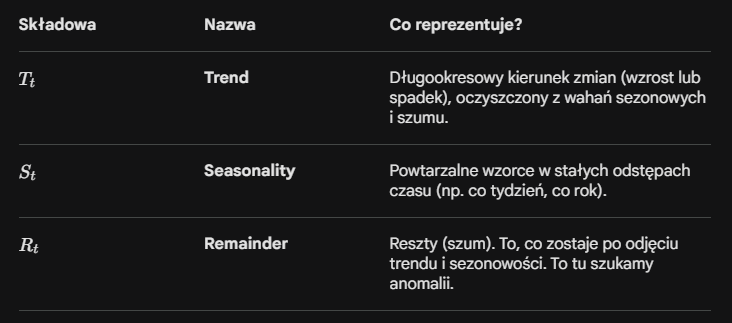

2. Dlaczego STL jest „lepszy” niż zwykła dekompozycja?

Istnieje klasyczna dekompozycja (metoda średnich kroczących), ale STL wygrywa z nią na kilku polach:

- Obsługa zmieniającej się sezonowości: Klasyczne metody zakładają, że sezonowość jest stała (np. w każdym grudniu sprzedaż rośnie o dokładnie tyle samo). STL pozwala sezonowości ewoluować w czasie.

- Odporność na wartości odstające (Outliers): Dzięki Loess, STL potrafi zignorować nagły, nienaturalny skok w danych, dzięki czemu nie "wykrzywia" on linii trendu.

- Elastyczność: Możesz kontrolować, jak "gładki" ma być trend i jak szybko ma reagować na zmiany w sezonowości.

3. Jak działa "Loess" pod maską?

Wyobraź sobie, że zamiast dopasowywać jedną prostą do wszystkich danych (jak w zwykłej regresji), przesuwasz małe okno nad wykresem. Dla każdego punktu w tym oknie model dopasowuje lokalną linię regresji, nadając większą wagę punktom bliższym środka okna. To sprawia, że linia jest bardzo płynna i idealnie "oddaje" kształt danych.

4. Po co to robić? (Zastosowanie biznesowe)

Jako analityk użyjesz STL w trzech sytuacjach:

- Czyszczenie danych (Deseasonalization): Chcesz wiedzieć, czy sprzedaż w Twoim sklepie z autami (PriceMyRide) naprawdę rośnie, czy to tylko "efekt wiosny", gdy wszyscy kupują kabriolety. Odejmujesz $S_t$ i patrzysz na sam trend.

- Detekcja anomalii: Patrzysz na komponent $R_t$ (reszty). Jeśli nagle pojawia się tam ogromna wartość, to znaczy, że wydarzyło się coś, czego nie da się wyjaśnić trendem ani kalendarzem (np. awaria strony Otomoto albo nagła zmiana przepisów podatkowych).

- Wybór modelu: Jeśli STL pokazuje, że sezonowość jest bardzo silna i stabilna, SARIMA będzie świetnym wyborem. Jeśli sezonowość "pływa" – lepiej sprawdzi się Prophet.

---

#### ACF i PACF

1. ACF (Autocorrelation Function) – Autokorelacja

ACF mierzy korelację między szeregiem czasowym a jego opóźnioną wersją (lagiem). Mówi nam: „Jak bardzo dzisiejsza wartość zależy od wartości sprzed $k$ dni?”.

- Kluczowa cecha: ACF uwzględnia zarówno efekty bezpośrednie, jak i pośrednie.

- Wyobraź sobie łańcuch: Poniedziałek wpływa na Wtorek, a Wtorek wpływa na Środę.

- ACF pokaże silną korelację między Poniedziałkiem a Środą, ponieważ Poniedziałek wpłynął na Środę "poprzez" Wtorek.

2. PACF (Partial Autocorrelation Function) – Częściowa Autokorelacja

PACF jest bardziej precyzyjna (stąd nazwa "częściowa"). Mierzy korelację między dzisiejszą wartością a lagiem $k$ po usunięciu wpływu wszystkich pośrednich lagów.

- Kluczowa cecha: PACF izoluje bezpośredni związek.

- W naszym przykładzie z łańcuchem: PACF między Poniedziałkiem a Środą sprawdzi, czy Poniedziałek ma jakiś dodatkowy, własny wpływ na Środę, którego nie da się wyjaśnić tym, co działo się we Wtorek.

3. Zastosowanie w modelu ARIMA (Reguły kciuka)

To jest moment, w którym teoria zamienia się w praktykę. Patrząc na wykresy ACF i PACF (tzw. korelogramy), możesz od razu zgadnąć, jakie parametry $p$ (część AR) i $q$ (część MA) powinieneś ustawić.

4. Jak czytać te wykresy

- Szukamy modelu AR(p): Patrzysz na PACF. Jeśli widzisz dwa wysokie słupki, a trzeci i kolejne są już w granicach błędu (niebieskie pole), to prawdopodobnie masz model AR(2). Na ACF zobaczysz wtedy powolne wygaszanie.

- Szukamy modelu MA(q): Patrzysz na ACF. Jeśli widzisz jeden wysoki słupek, a reszta "leży", to masz model MA(1). Na PACF zobaczysz wtedy powolne wygaszanie.

---

#### Test ADF

Test ADF (Augmented Dickey-Fuller) to w świecie szeregów czasowych „wykrywacz kłamstw” dla stacjonarności. Jest to najczęściej stosowany test statystyczny, który pozwala matematycznie potwierdzić, czy Twoje dane „stoją w miejscu” (średnia i wariancja są stałe), czy też „odpływają” w jakimś kierunku (mają trend lub unit root). Bez tego testu modelowanie ARIMA to błądzenie po omacku.

1. Dlaczego stacjonarność jest taka ważna?

Większość modeli statystycznych (jak AR czy MA) zakłada, że właściwości statystyczne danych nie zmieniają się w czasie. Jeśli masz trend (np. ceny aut na Otomoto rosną z powodu inflacji), to średnia z przeszłości nie mówi nic o średniej z przyszłości.

- Test ADF sprawdza obecność tzw. pierwiastka jednostkowego (unit root). Jeśli szereg ma pierwiastek jednostkowy, jest niestacjonarny – zachowuje się jak „błądzenie losowe” (random walk), gdzie każdy kolejny krok zależy od poprzedniego plus losowy szum.

2. Hipotezy testu ADFW teście ADF musisz bardzo uważać na to, co jest hipotezą zerową, bo jest ona „odwrócona” w stosunku do tego, czego zazwyczaj szukamy w testach statystycznych.

- $H_0$ (Hipoteza zerowa): Szereg czasowy posiada pierwiastek jednostkowy (jest niestacjonarny).

- $H_1$ (Hipoteza alternatywna): Szereg czasowy jest stacjonarny.

- Zasada Juniora: Chcemy „odrzucić” $H_0$, czyli cieszymy się, gdy nasze $p-value$ jest małe!

3. Jak interpretować wynik?

Kiedy uruchomisz test w Pythonie (np. adfuller z biblioteki statsmodels), otrzymasz dwie kluczowe liczby:

- A. ADF Statistic: To wartość testowa. Porównujemy ją z wartościami krytycznymi (dla 1%, 5%, 10%).Jeśli statystyka ADF jest bardziej ujemna (mniejsza) niż wartość krytyczna (np. $-3.5$ przy krytycznej $-2.8$), odrzucasz $H_0$.

- B. P-value: To najprostszy wskaźnik dla analityka.

- $p-value \le 0.05$: Mamy dowód na stacjonarność. Możemy budować model AR/MA.

- $p-value > 0.05$: Szereg jest niestacjonarny. Musisz go zróżnicować (odjąć poprzednią wartość) i wykonać test ponownie.

4. Co oznacza „Augmented” (Rozszerzony)?

Podstawowy test Dickeya-Fullera był prosty, ale gubił się, gdy dane miały skomplikowaną strukturę (np. dzisiejsza wartość zależała od tej sprzed 3 dni). Wersja Augmented dodaje do równania opóźnione różnice (lags), co pozwala „oczyścić” dane z autokorelacji i skupić się na samym problemie pierwiastka jednostkowego.

- Uproszczone równanie testu wygląda tak:$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \delta_1 \Delta y_{t-1} + \dots + \delta_p \Delta y_{t-p} + \epsilon_t$$

- Test sprawdza, czy współczynnik $\gamma = 0$. Jeśli tak, mamy niestacjonarność.

5. Zastosowanie w Twoim procesie (Workflow)

Jako Junior Data Scientist powinieneś stosować ADF w następującej pętli:

- Wykonaj test ADF na surowych danych.

- Jeśli $p > 0.05$: Zróżnicuj dane (df.diff().dropna()).

- Wykonaj test ADF ponownie na zróżnicowanych danych.

- Powtarzaj, aż $p \le 0.05$. Liczba wykonanych różnicowań to Twój parametr $d$ w modelu ARIMA(p, d, q).

---

#### Modelowanie - strategie multi-step

1. Modelowanie: Strategie Multi-Step

Kiedy chcesz przewidzieć więcej niż jeden krok w przód (np. sprzedaż na całe następne 7 dni), musisz wybrać strategię:

- Recursive Forecasting: Model przewiduje $t+1$, potem bierze tę prognozę jako „prawdę” i na jej podstawie przewiduje $t+2$. Błąd narasta jak kula śnieżna.

- Direct Forecasting: Trenujesz osobny model dla każdego dnia (jeden dla $t+1$, drugi dla $t+2$ itd.). Brak narastania błędu, ale dużo więcej pracy dla komputera.

- MIMO (Multi-Input Multi-Output): Model (zazwyczaj sieć neuronowa) wypluwa cały wektor (np. 7 dni) na raz.

---

#### Heteroskedastyczność, Test KPSS, Kointegracja

1. Heteroskedastyczność (Heteroscedasticity)

W klasycznej regresji zakładamy homoskedastyczność – czyli, że błąd (szum) naszego modelu ma stałą wariancję, niezależnie od czasu czy wartości zmiennych. Heteroskedastyczność to sytuacja, w której ten rozrzut (wariancja) się zmienia.

Intuicja: „Efekt lejka”: Wyobraź sobie, że przewidujesz wydatki ludzi na wakacje na podstawie ich zarobków:

- Osoby zarabiające mało wydają mało i ich wydatki są bardzo przewidywalne (mała wariancja).

- Osoby zarabiające bardzo dużo mogą wydać mało (bo są oszczędne) albo ogromne kwoty (bo kupują jacht). 

Rozrzut ich wydatków jest gigantyczny (duża wariancja). Na wykresie zobaczysz charakterystyczny kształt otwierającego się wachlarza lub lejka.

Dlaczego to problem?

Jeśli Twój model ignoruje heteroskedastyczność:

- P-values są niewiarygodne: Możesz uznać jakąś zmienną za istotną, choć wcale taka nie jest.

- Przedziały ufności są błędne: Twoja prognoza może mówić „$\pm 100$ zł”, podczas gdy dla dużych wartości błąd wynosi faktycznie „$\pm 5000$ zł”.

Jak to naprawić? 

- Logarytmowanie zmiennej zależnej (Log-transform) lub użycie modeli klasy ARCH/GARCH.

2. Test KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

Test KPSS to „lustrzane odbicie” testu ADF. Służy do sprawdzania stacjonarności, ale ma odwrócone hipotezy. Hipotezy:

- $H_0$ (Hipoteza zerowa): Szereg jest stacjonarny (lub stacjonarny wokół trendu).

- $H_1$ (Hipoteza alternatywna): Szereg jest niestacjonarny (ma pierwiastek jednostkowy).Po co stosować oba (ADF + KPSS)?

3. Kointegracja (Cointegration)

To jedno z najbardziej fascynujących pojęć w statystyce czasu. Kointegracja zachodzi wtedy, gdy dwa (lub więcej) szeregi czasowe są niestacjonarne (każdy „pływa” sobie losowo), ale ich kombinacja liniowa jest stacjonarna.

Intuicja: „Pijak i jego pies” To klasyczna analogia w statystyce:

- Pijak idzie przez park błądzeniem losowym (niestacjonarność). Jego pies też biega chaotycznie w różnych kierunkach (niestacjonarność). Jednak pijak trzyma psa na smyczy. Mimo że obaj poruszają się nieprzewidywalnie, odległość między nimi (smycz) jest ograniczona i stabilna. Ta smycz to właśnie kointegracja.

- Przykład biznesowy: Cena ropy naftowej i cena benzyny. Obie ceny skaczą chaotycznie, ale nie mogą od siebie zbyt daleko uciec, bo są ze sobą powiązane fundamentalnie. Cena tej samej akcji na giełdzie w Londynie i w Nowym Jorku (po przeliczeniu walut).

---

#### Transformacje dla szeregów czasowych

1. Log-Transform (Transformacja logarytmiczna)

To najprostsza, a zarazem jedna z najpotężniejszych metod przygotowania danych. Polega na zastąpieniu wartości $y$ jej logarytmem (zazwyczaj naturalnym), czyli $\ln(y)$.

Po co to robić?

- Stabilizacja wariancji: Jeśli Twój "lejek" (heteroskedastyczność) się rozszerza, logarytm go "prostuje".

- Zmiana skali: Zamienia relacje multiplikatywne (wzrost o $10\%$) na adytywne (wzrost o stałą wartość). Dla modelu ML łatwiej jest przewidzieć, że coś wzrośnie o "0.1", niż że wzrośnie o "10% z niewiadomo jakiej bazy".

- Normalizacja: "Ściąga" wartości odstające (outliers) bliżej centrum, sprawiając, że rozkład staje się bardziej zbliżony do normalnego.

Ważne: Możesz logarytmować tylko liczby dodatnie ($y > 0$). Jeśli masz zera, stosuje się logarytmowanie $ln(y + 1)$.

2. Transformacja Box-Cox

Jeśli Log-Transform to młotek, to Box-Cox to cały zestaw kluczy nastawnych. Jest to rodzina transformacji potęgowych, która automatycznie szuka najlepszego sposobu na "ucywilizowanie" Twoich danych.

Jak to działa?

Model Box-Cox szuka optymalnego parametru $\lambda$ (lambda), który najlepiej przekształci dane w rozkład normalny według wzoru:$$y(\lambda) = \begin{cases} \frac{y^\lambda - 1}{\lambda} & \text{jeśli } \lambda \neq 0 \\ \ln(y) & \text{jeśli } \lambda = 0 \end{cases}$$

- Jeśli $\lambda = 1$, dane zostają bez zmian.

- Jeśli $\lambda = 0$, Box-Cox staje się zwykłym logarytmem.

- Jeśli $\lambda = 0.5$, robi pierwiastkowanie.

Dlaczego to jest lepsze? Nie musisz zgadywać. Algorytm (np. w scipy.stats.boxcox) sam obliczy taką lambdę, która najskuteczniej usunie heteroskedastyczność z Twoich danych.

3. Backtesting

Backtesting to proces sprawdzania, jak Twój model lub strategia poradziłaby sobie w przeszłości. W szeregach czasowych to coś więcej niż tylko "test set" – to historyczna symulacja.

Jak to wygląda w praktyce?

Wyobraź sobie, że jest 1 stycznia 2025 roku.

- Trenujesz model na danych do tego dnia.

- Robisz prognozę na tydzień w przód.

- Sprawdzasz, o ile się pomyliłeś (porównujesz z rzeczywistymi danymi z przyszłości, które już znasz).

- Przesuwasz się o tydzień (do 8 stycznia) i powtarzasz cały proces.

Dlaczego to jest kluczowe?

- Realizm: Backtesting symuluje realne warunki pracy modelu (uczenie na tym, co było "wtedy" wiadome).

- Stabilność: Pozwala sprawdzić, czy model nie miał "szczęścia" tylko w jednym miesiącu. Jeśli w 10 kolejnych "przesunięciach" (backtestach) błąd MAPE jest stabilny, to model jest godny zaufania.

- Zarządzanie ryzykiem: W finansach backtesting mówi Ci, ile najwięcej mogłeś stracić w najgorszym historycznym scenariuszu (Maximum Drawdown).

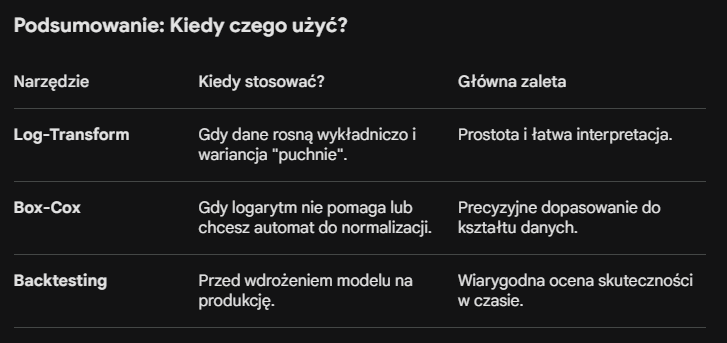

---

#### Modele lokalne i modele globalne

1. Modele Lokalne (Traditional Approach)

W podejściu lokalnym tworzysz osobny model dla każdego szeregu czasowego.

- Jak to działa: Jeśli masz 1000 różnych modeli samochodów na Otomoto, trenujesz 1000 osobnych modeli ARIMA lub Prophet. Każdy z nich widzi tylko historię "swojego" auta.

- Główna filozofia: Każdy szereg jest unikalny i ma własną dynamikę.

Zalety:

- Precyzja dla specyficznych danych: Jeśli dany model auta zachowuje się bardzo dziwnie, lokalna ARIMA idealnie się do niego dopasuje.

- Interpretowalność: Łatwo sprawdzić, dlaczego model dla VW Golfa przewiduje spadek (np. widać to w jego parametrach).

Wady:

- Problem "zimnego startu" (Cold Start): Jeśli na Otomoto pojawia się nowy model auta, który ma tylko 3 ogłoszenia, model lokalny nie ma na czym się uczyć i polegnie.

- Koszty utrzymania: Zarządzanie 1000 modeli, monitorowanie ich błędów i ponowne trenowanie to koszmar operacyjny.

2. Modele Globalne (Modern ML Approach)

Model globalny to jeden model wytrenowany na wszystkich szeregach jednocześnie.

- Jak to działa: Wrzucasz wszystkie ogłoszenia z Otomoto do jednego wielkiego XGBoost-a, LightGBM-a lub sieci neuronowej (np. N-BEATS). Jako cechy (features) podajesz Marka_ID, Model_ID, a model uczy się wzorców od wszystkich aut naraz.

- Główna filozofia: Istnieją wspólne wzorce (cross-learning), które łączą wszystkie dane.

Zalety:

- Transfer wiedzy (Cross-learning): To największa zaleta. Model widzi, że ceny Toyoty Yaris spadają w określonym tempie i może wykorzystać tę wiedzę, by przewidzieć cenę nowej marki, o której ma mało danych.

- Skalowalność: Trenujesz i wdrażasz tylko jeden model zamiast tysięcy.

- Obsługa braków: Świetnie radzi sobie z rzadkimi danymi, bo "pożycza" wzorce od podobnych, częściej występujących szeregów.

Wady:

- Dominacja większości: Jeśli 90% Twoich danych to popularne Passaty, model może słabo radzić sobie z rzadkimi autami kolekcjonerskimi, bo będzie próbował "nagiąć" je do ogólnego wzorca rynkowego.

- Złożoność cech: Musisz bardzo przyłożyć się do feature engineeringu, aby model wiedział, czym różni się jeden szereg od drugiego.

---

### Transformacje i kodowania

1. Transformacja Yeo-Johnsona

To zaawansowana metoda przekształcania danych, która ma na celu przybliżenie ich rozkładu do rozkładu normalnego oraz ustabilizowanie wariancji. Jest to bezpośrednie rozwinięcie transformacji Box-Coxa.

Dlaczego jest lepsza od Box-Coxa?

Box-Cox wymaga, aby wszystkie wartości były ściśle dodatnie ($y > 0$). Yeo-Johnson rozwiązuje ten problem – działa dla liczb dodatnich, zer, a nawet liczb ujemnych.

Matematyka (uproszczona):

- Transformacja używa parametru $\lambda$ (lambda). W zależności od tego, czy wartość $y$ jest dodatnia czy ujemna, stosuje się nieco inne wzory potęgowe:

    - Jeśli $y \ge 0$, wzór przypomina Box-Coxa.

    - Jeśli $y < 0$, stosuje się specjalne przekształcenie, które „odbija” logikę potęgowania dla wartości ujemnych.

- Zastosowanie: Gdy Twoje dane (np. zyski i straty lub zmiany cen) mają „ciężkie ogony” (wiele skrajnych wartości) i chcesz, aby model regresji działał stabilniej.

2. Cyclic Encoding (Kodowanie Cykliczne)

To technika inżynierii cech, która pozwala modelom ML „zrozumieć”, że czas jest kołem, a nie linią.

Problem:

- Jeśli zakodujesz godziny jako 0, 1, 2... 23, to dla modelu matematycznego godzina 23:00 i 00:00 są od siebie bardzo daleko (różnica 23 jednostki). W rzeczywistości dzieli je tylko godzina.

Rozwiązanie:

- Mapujemy czas na współrzędne $(\sin, \cos)$ na okręgu jednostkowym. Każda cecha czasowa (np. dzień tygodnia, miesiąc, godzina) zostaje rozbita na dwie kolumny:

    - $x_{sin} = \sin\left(\frac{2\pi \cdot \text{value}}{\text{max\_value}}\right)$

    - $x_{cos} = \cos\left(\frac{2\pi \cdot \text{value}}{\text{max\_value}}\right)$

- Efekt: Dzięki temu model „widzi”, że po 23:00 następuje 00:00, bo ich punkty na okręgu leżą tuż obok siebie. Jest to kluczowe dla modeli takich jak XGBoost czy Las Losowy.

### Metoda Crostona i Modele VAR

3. Metoda Crostona

To specjalistyczny model statystyczny stworzony do prognozowania tzw. popytu przerywanego (intermittent demand).

Problem:

- Wiele produktów (np. drogie części zamienne do aut) sprzedaje się rzadko. Większość dni w szeregu to zera, a raz na jakiś czas pojawia się sprzedaż (np. 5 sztuk). Klasyczne modele (jak ARIMA) widząc same zera, będą „zaniżać” prognozę prawie do zera lub gwałtownie reagować na pojedynczą sprzedaż.

Jak to działa?

Croston rozbija szereg na dwa osobne procesy, które prognozuje niezależnie przy użyciu wygładzania wykładniczego:

- Wielkość popytu: Ile sztuk kupiono, gdy już doszło do transakcji?

- Częstotliwość popytu: Ile czasu upłynęło od ostatniej transakcji?

- Wynik: Prognoza Crostona to stosunek tych dwóch wartości. Daje ona stabilną, niezerową wartość, która mówi: „średnio w każdym okresie potrzebujemy X sztuk, by być gotowym na rzadkie zamówienia”.

4. Modele VAR (Vector Autoregression)

VAR to potężne rozszerzenie modeli AR (autoregresyjnych) na wiele zmiennych jednocześnie. To model typu multivariate.

Zasada działania:

- W zwykłym AR przewidujemy $Y$ na podstawie jego przeszłości. W VAR mamy system kilku zmiennych (np. cena auta, kurs waluty, inflacja) i zakładamy, że każda z nich wpływa na każdą inną.

- Każda zmienna w systemie jest równaniem, w którym predyktorami są opóźnione wartości wszystkich zmiennych w tym systemie.

- Przykład równania dla dwóch zmiennych ($Y_1$ i $Y_2$):

    - $$Y_{1,t} = \alpha_1 + \beta_{1,1} Y_{1,t-1} + \beta_{1,2} Y_{2,t-1} + \epsilon_{1,t}$$

    - $$Y_{2,t} = \alpha_2 + \beta_{2,1} Y_{1,t-1} + \beta_{2,2} Y_{2,t-1} + \epsilon_{2,t}$$

Kluczowe zastosowanie:

- Analiza przyczynowości Grangera: Czy $Y_1$ naprawdę pomaga przewidzieć $Y_2$?

- Impulse Response Function (IRF): Pozwala sprawdzić, co stanie się z całym systemem, jeśli nagle „szokowo” zmieni się tylko jedna zmienna (np. „o ile wzrosną ceny aut na Otomoto, jeśli kurs Euro nagle skoczy o 20 groszy?”).

---

### Dynamiczne regresory i interpretowalność SHAP

1. Dynamiczne Regresory (Lead-Lag Relationship)

Większość początkujących zakłada, że jeśli zmienna $X$ wpływa na $Y$, to dzieje się to w tym samym momencie ($t$). W rzeczywistości świat ma opóźnienia. To właśnie są dynamiczne regresory.

Lead vs. Lag (Wyprzedzenie vs. Opóźnienie)

- Lag (Opóźnienie): Zdarzenie $X$ wpływa na $Y$ po pewnym czasie.

- Przykład: Wzrost stóp procentowych dzisiaj wpłynie na spadek sprzedaży aut na Otomoto dopiero za 3–6 miesięcy.

- Lead (Wyprzedzenie): Zdarzenie $X$ zmienia się zanim zmieni się $Y$.

- Przykład: Wzrost wyszukiwań hasła „jak sprzedać auto” w Google Trends może z wyprzedzeniem sygnalizować zwiększoną podaż na portalach ogłoszeniowych za 2 tygodnie.

Jak znaleźć „złoty moment”? (CCF)

Do wykrywania tych relacji służy CCF (Cross-Correlation Function). To wykres podobny do ACF, ale pokazuje korelację między dwoma różnymi szeregami dla różnych przesunięć (lagów).

- Jeśli najwyższy słupek na CCF jest przy lag = -5, oznacza to, że Twoja zmienna egzogeniczna $X$ najlepiej przewiduje $Y$, gdy przesuniesz ją o 5 jednostek wstecz.

2. Interpretowalność: SHAP dla Szeregów Czasowych

Modele Machine Learning (XGBoost, Random Forest, LightGBM) świetnie radzą sobie z szeregami czasowymi, ale są „czarnymi skrzynkami”. SHAP (SHapley Additive exPlanations) to metoda z teorii gier, która pozwala rozbić każdą prognozę na czynniki pierwsze.

Jak SHAP „rozmawia” z czasem?

Zamiast ogólnej informacji „przebieg jest ważny”, SHAP powie Ci dokładnie, co wpłynęło na prognozę dla konkretnego dnia:

- Wartość bazowa: Średnia cena auta w Twoim zbiorze (np. 40 000 zł).

- Wpływ cech: * Lag_1 (cena z wczoraj): +2 000 zł (bo rynek rośnie).

- Rolling_Mean_7 (średnia z tygodnia): -500 zł.

- Is_Weekend: +300 zł (większy ruch).

- Fourier_Term: -1 000 zł (sezonowy dołek w listopadzie).

- Prognoza końcowa: 40 800 zł.

Dlaczego to jest przełomowe?

- Zaufanie: Możesz pokazać klientowi dashboardu PriceMyRide, dlaczego jego auto zostało wycenione niżej (np. „widzimy, że modele o podobnym przebiegu gwałtownie potaniały w ostatnim tygodniu”).

- Debugowanie: Jeśli model nagle „wariuje”, SHAP pokaże Ci, która cecha (np. błędnie zeskrapowany kurs waluty) psuje wynik.

- Wykrywanie Sezonowości: SHAP pokaże, czy model faktycznie nauczył się wzorców rocznych, czy tylko „zgaduje” na podstawie ostatniego dnia.

---

### Wnioskowanie Przyczynowe i Projektowanie Eksperymentów

1. Wnioskowanie Przyczynowe (Causal Inference)

Większość modeli Machine Learningu szuka korelacji. Wnioskowanie przyczynowe szuka mechanizmu. Chodzi o zrozumienie efektu kontrfaktycznego (counterfactual): co stałoby się z obiektem A, gdybyśmy NIE podjęli działania B?

Kluczowe metody:

- Difference-in-Differences (DiD):

    - Wyobraź sobie, że Warszawa wprowadza zakaz wjazdu starych diesli (Twoje Otomoto!), a Kraków nie. 

    - Porównujesz trend cen aut przed i po zakazie w obu miastach.$$\delta = (Y_{Wawa, po} - Y_{Wawa, przed}) - (Y_{KrK, po} - Y_{KrK, przed})$$

    - Jeśli ceny w Warszawie spadły mocniej niż wynikałoby to z ogólnego trendu (Kraków), to mamy dowód na wpływ zakazu.

- Propensity Score Matching (PSM):

    - Jeśli nie masz grupy kontrolnej (bo np. wszyscy użytkownicy sami wybierają, czy chcą kupić konto Premium), używasz PSM. 

    - Szukasz „bliźniaków” statystycznych: dobierasz użytkownika Premium i zwykłego, którzy mają identyczny staż, wiek i historię wyszukiwań. Porównujesz ich zachowanie.

- Regression Discontinuity Design (RDD):

    - Wykorzystujesz „sztywne progi”. Przykład: Na Otomoto auta powyżej 10 lat mają inną stawkę za ogłoszenie. Porównujesz auta mające 9 lat i 11 miesięcy z tymi, które mają 10 lat i 1 miesiąc. Są niemal identyczne, ale różni je jedna zmienna (cena ogłoszenia). To pozwala zmierzyć wpływ tej ceny na liczbę ofert.

2. Projektowanie Eksperymentów (Design of Experiments - DoE)

To sztuka planowania testów tak, aby ich wyniki były wiarygodne, a nie dziełem przypadku. W świecie online to głównie A/B Testing.

Filary udanego eksperymentu:

- Hipoteza (H0 vs H1): Nie testuj „czy to zadziała”. Testuj: „Czy zmiana koloru przycisku 'Kup teraz' zwiększy CTR o co najmniej 2%?”.

- Wielkość Próbki i Power Analysis: To najczęstszy błąd. Zanim zaczniesz, musisz wyliczyć $n$ (liczbę użytkowników). Zależy ona od:

    - Baseline Conversion: Jaki jest obecny wynik? (np. 5%).

    - MDE (Minimum Detectable Effect): Jaka najmniejsza zmiana nas interesuje? (np. wzrost o 0.5%).

    - Statistical Power ($1-\beta$): Zazwyczaj 0.8. Szansa, że wykryjemy efekt, jeśli on faktycznie istnieje.

    - Significance Level ($\alpha$): Zazwyczaj 0.05. Szansa, że ogłosimy sukces, choć zmiana była przypadkowa.

- Randomizacja i SRM (Sample Ratio Mismatch):Użytkownicy muszą być przydzieleni losowo. Jeśli na koniec testu widzisz, że w grupie A masz 10 000 osób, a w grupie B 12 000 (choć miało być 50/50), to masz SRM. Twój test jest skażony i prawdopodobnie wyniki są błędne.

---

---
---
---

### Teoria Statystyczno-Matematyczna ML

#### Percentyle i Kwartyle

1. Percentyle – Podział na 100 części

Percentyl rzędu $k$ ($P_k$) to taka wartość, poniżej której znajduje się $k\%$ obserwacji.

- Intuicja: Jeśli Twój wynik z egzaminu jest na 90. percentylu, oznacza to, że napisałeś go lepiej niż 90% pozostałych studentów.

- P99 (99. percentyl): Bardzo ważny w IT. Jeśli P99 czasu odpowiedzi API wynosi 200ms, oznacza to, że tylko 1% użytkowników czeka dłużej niż 200ms. Średnia może wynosić 20ms, ale P99 mówi Ci o "najgorszych przypadkach".

2. Kwartyle – Podział na 4 części

Kwartyle to specyficzne percentyle, które dzielą posortowany zbiór danych na cztery równe grupy pod względem liczby obserwacji.

- $Q_1$ (Pierwszy kwartyl): 25. percentyl. Odcina 25% najniższych wartości.

- $Q_2$ (Drugi kwartyl / Mediana): 50. percentyl. Dzieli zbiór idealnie na pół.

- $Q_3$ (Trzeci kwartyl): 75. percentyl. Odcina 75% niższych wartości (lub 25% najwyższych).

3. IQR – Rozstęp ćwiartkowy (Interquartile Range)

To najważniejsza miara rozproszenia oparta na kwartylach. Obliczamy ją jako różnicę między trzecim a pierwszym kwartylem:

$$IQR = Q_3 - Q_1$$

Dlaczego IQR jest lepszy od zwykłego zakresu (Max - Min)?

- Ponieważ ignoruje wartości skrajne. $IQR$ skupia się na "środkowych 50%" danych, co daje nam obraz tego, gdzie leży "serce" rozkładu bez wpływu pojedynczych błędów pomiarowych.

4. Wykrywanie outlierów (Metoda Tukeya)

Jako programista ML będziesz często pisał funkcje usuwające szum. Standardowa reguła kciuka mówi, że wartość jest outlierem (punktem odstającym), jeśli leży poza zakresem:Dolna granica: $Q_1 - 1.5 \cdot IQR$Górna granica: $Q_3 + 1.5 \cdot IQR$

5. Wizualizacja: Wykres Pudełkowy (Boxplot)Wszystkie te pojęcia spotykają się na jednym wykresie – Boxplocie. Gdy go widzisz, czytasz go następująco:

- Linia wewnątrz pudełka: Mediana ($Q_2$).

- Krawędzie pudełka: $Q_1$ oraz $Q_3$.

- Wąsy (whiskers): Zazwyczaj sięgają do najdalszych punktów niebędących outlierami (zgodnie z zasadą $1.5 \cdot IQR$).

- Kropki poza wąsami: To Twoi kandydaci do usunięcia lub zbadania (outliery).

---

#### **Rozkłady statystyczne**

1. Rozkład Normalny (Gaussa)

Rozkład normalny opisuje dane, które skupiają się wokół średniej ($\mu$), a im dalej od niej, tym rzadziej występują.

Kluczowe cechy:

- Symetria: Średnia, mediana i moda są sobie równe i znajdują się w samym centrum.

- Parametry: Jest zdefiniowany przez dwa parametry: średnią ($\mu$) – określa centrum – oraz odchylenie standardowe ($\sigma$) – określa "szerokość" lub "rozpiętość" dzwonu.

- Reguła Trzech Sigm (68-95-99.7):

    - 68% danych leży w odległości $1\sigma$ od średniej.

    - 95% danych leży w odległości $2\sigma$ od średniej.

    - 99.7% danych leży w odległości $3\sigma$ od średniej.

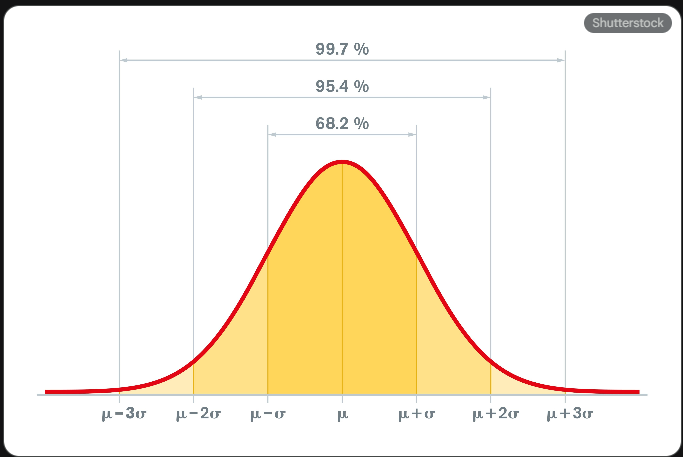

Dlaczego jest tak ważny w ML?
Wiele algorytmów (np. Regresja Liniowa, LDA, Gausowskie procesy) zakłada, że błędy lub cechy mają rozkład normalny. Jeśli Twoje dane są "krzywe" (np. ceny nieruchomości, gdzie kilka bardzo drogich domów psuje średnią), musisz je transformować (np. logarytmem), aby przypominały rozkład normalny – inaczej model będzie działał gorzej.

---

2. Rozkład Bernoulliego

To najprostszy możliwy rozkład prawdopodobieństwa. Opisuje on pojedyncze doświadczenie, które ma tylko dwa możliwe wyniki: sukces (zazwyczaj oznaczany jako $1$) lub porażkę (oznaczaną jako $0$).

- Prawdopodobieństwo:

    - Sukces: $P(X=1) = p$

    - Porażka: $P(X=0) = 1 - p$ (często oznaczane jako $q$)

- Przykład: Jeden rzut monetą (orzeł to sukces), jedno kliknięcie w reklamę, jedno wystąpienie awarii w danej sekundzie.

- Zastosowanie w ML: To model teoretyczny dla pojedynczej obserwacji w klasyfikacji binarnej. Funkcja kosztu Log-Loss (Binary Cross-Entropy) jest wyprowadzona bezpośrednio z funkcji wiarygodności rozkładu Bernoulliego.

3. Rozkład Dwumianowy

Rozkład dwumianowy to "rozszerzona wersja" Bernoulliego. Opisuje on liczbę sukcesów w serii $n$ niezależnych prób Bernoulliego, gdzie każda próba ma to samo prawdopodobieństwo sukcesu $p$.

Aby rozkład był dwumianowy, muszą być spełnione cztery warunki (tzw. BINS):

- Binary: Wynik każdej próby musi być binarny (sukces/porażka).

- Independent: Próby muszą być od siebie niezależne (wynik pierwszego rzutu monetą nie wpływa na drugi).

- Number: Liczba prób ($n$) musi być ustalona z góry.

- Same: Prawdopodobieństwo sukcesu ($p$) musi być takie samo dla każdej próby.

Wzór na prawdopodobieństwo uzyskania dokładnie $k$ sukcesów:

$$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Gdzie $\binom{n}{k}$ to symbol Newtona, który mówi nam, na ile sposobów możemy wybrać $k$ sukcesów w $n$ próbach.

---

4. Rozkład Poissona

Rozkład Poissona to rozkład dyskretny. Używamy go do modelowania liczby zdarzeń, które wystąpią w określonym przedziale czasu lub przestrzeni, pod warunkiem, że te zdarzenia występują ze znaną średnią częstotliwością i są od siebie niezależne.

Kluczowe cechy:

- Zdarzenia rzadkie: Często nazywany „prawem zdarzeń rzadkich”. Używamy go, gdy mamy dużą liczbę prób, ale prawdopodobieństwo pojedynczego sukcesu jest bardzo małe.

- Parametr $\lambda$ (Lambda): To jedyny parametr tego rozkładu. Reprezentuje on średnią liczbę zdarzeń w danym przedziale. Co ciekawe, w tym rozkładzie średnia jest równa wariancji ($E(X) = Var(X) = \lambda$).

- Brak pamięci: Zdarzenia muszą być niezależne – to, że autobus przyjechał przed chwilą, nie zmienia prawdopodobieństwa, że kolejny przyjedzie za minutę (w idealnym modelu Poissona).

Wzór:

$$P(X=k) = \frac{e^{-\lambda} \cdot \lambda^k}{k!}$$

Zastosowanie w ML i Data Science:

- Predictive Maintenance: Przewidywanie liczby awarii maszyn w ciągu miesiąca.

- Analiza ruchu: Liczba użytkowników wchodzących na stronę w ciągu minuty.

- Biometria: Liczba mutacji w danym fragmencie DNA.

5. Rozkład t-Studenta

Rozkład t-Studenta wygląda bardzo podobnie do rozkładu normalnego (jest symetryczny i ma kształt dzwonu), ale ma „grubsze ogony” (heavy tails).

Skąd się wziął?

Został opracowany przez Williama Gosseta (piszącego pod pseudonimem „Student”), który pracował w browarze Guinness. Musiał on wyciągać wnioski o jakości piwa na podstawie bardzo małych próbek, dla których rozkład normalny dawał zbyt optymistyczne (błędne) wyniki.

Kluczowe cechy:

- Stopnie swobody ($\nu$ lub $df$): To główny parametr. Im mniejsza liczba stopni swobody (mniejsza próba), tym ogony rozkładu są wyższe i grubsze.

- Zbieżność: W miarę jak liczba obserwacji rośnie (zazwyczaj powyżej 30), rozkład t-Studenta staje się niemal identyczny z rozkładem normalnym.

- Niepewność: Grubsze ogony oznaczają, że rozkład t-Studenta „dopuszcza” więcej wartości oddalonych od średniej. Jest więc bardziej konserwatywny – trudniej o pomyłkę przy małej ilości danych.

Zastosowanie w ML i Data Science:

- Testy istotności (t-test): Kiedy porównujemy średnie z dwóch grup (np. w testach A/B), a mamy małą liczbę użytkowników.

- Przedziały ufności: Obliczanie marginesu błędu dla małych zbiorów danych.

- Robust Regression: Modele oparte na rozkładzie t-Studenta są bardziej odporne na outliery (wartości odstające właśnie „chowają się” w tych grubych ogonach).

---

6. Rozkład Log-Normalny

Rozkład log-normalny występuje wtedy, gdy logarytm naturalny Twojej zmiennej losowej $X$ ma rozkład normalny.

Intuicja techniczna:

- W rozkładzie normalnym dane powstają przez dodawanie wielu małych, niezależnych czynników (zgodnie z CLT). W rozkładzie log-normalnym dane powstają przez mnożenie wielu małych czynników. Ponieważ iloczyn liczb dodatnich nigdy nie jest ujemny, rozkład ten zaczyna się od 0 i ciągnie się w prawą stronę.

Matematyka:

- Jeśli $Y = \ln(X)$ i $Y \sim N(\mu, \sigma^2)$, to $X$ ma rozkład log-normalny.

Charakteryzuje się on prawostronną skośnością (long right tail). Większość wartości jest mała, ale zdarzają się wartości ekstremalnie duże (np. zarobki najbogatszych ludzi świata).

Zastosowanie w ML:

- Modelowanie cen: Ceny nieruchomości, akcji czy dochodów.

- Wizualizacja: Jeśli na histogramie widzisz „ogórkowaty” kształt przyklejony do lewej osi, spróbuj zlogarytmować tę cechę (np.log(df['feature'])). Jeśli po tym zabiegu zobaczysz dzwon rozkładu normalnego – gratulacje, to był rozkład log-normalny.

7. Rozkład Wykładniczy

Rozkład wykładniczy to rozkład ciągły, który opisuje czas między zdarzeniami w procesie Poissona.

Intuicja techniczna:

- Jeśli rozkład Poissona mówi nam, ile osób wejdzie do sklepu w ciągu godziny, to rozkład wykładniczy mówi nam, ile czasu upłynie, zanim wejdzie kolejna osoba. Jest to rozkład „bez pamięci” (memoryless property). Oznacza to, że prawdopodobieństwo, iż zdarzenie nastąpi w ciągu najbliższych 5 minut, jest takie samo, niezależnie od tego, czy czekasz już godzinę, czy dopiero zacząłeś.

Matematyka:

- Zależy od jednego parametru $\lambda$ (lambda), który oznacza intensywność (np. średnio 2 klientów na minutę). Funkcja gęstości prawdopodobieństwa (PDF) wygląda tak:$$f(x; \lambda) = \lambda e^{-\lambda x} \quad \text{dla } x \ge 0$$ Najwyższe prawdopodobieństwo jest zawsze przy $x=0$ (najkrótszy czas oczekiwania) i spada wykładniczo w miarę upływu czasu.

Zastosowanie w ML:

- Reliability Engineering (Niezawodność): Przewidywanie czasu do awarii komponentu (Mean Time Between Failures - MTBF).

- Systemy kolejkowe: Czas obsługi żądania przez serwer (request latency).

- Analiza przeżycia (Survival Analysis): Czas, jaki upłynie do wystąpienia określonego zdarzenia (np. rezygnacji klienta – churn).

---

#### Przedziały Ufności

1. Intuicja techniczna

- Wyobraź sobie, że chcesz obliczyć średni czas odpowiedzi Twojego serwera. Wykonujesz 100 zapytań i średnia wynosi 150ms. Czy to znaczy, że serwer zawsze i dla każdego użytkownika odpowiada w 150ms? Oczywiście, że nie. Przedział ufności mówi Ci: „Na podstawie tych 100 prób jestem na 95% pewien, że prawdziwa średnia dla wszystkich możliwych zapytań mieści się między 145ms a 155ms”.

2. Definicja matematyczna

- Przedział ufności to zakres wartości, w którym z określonym prawdopodobieństwem (zwanym poziomem ufności, np. 95%) znajduje się nieznany parametr populacji (np. średnia $\mu$). Wzór na przedział ufności dla średniej (przy dużym $n$) wygląda tak:

$$CI = \bar{x} \pm z \cdot \frac{\sigma}{\sqrt{n}}

$$Gdzie:

- $\bar{x}$: Średnia z Twojej próby (punktowy estymator).

- $z$: Wartość krytyczna z rozkładu normalnego (dla 95% wynosi ona około 1.96).

- $\sigma$: Odchylenie standardowe.

- $n$: Wielkość próby (liczba rekordów).

- $\frac{\sigma}{\sqrt{n}}$: To tzw. błąd standardowy (Standard Error).

3. Co wpływa na szerokość przedziału?

- Jako inżynier masz wpływ na to, jak "pewny" jest Twój wynik:Wielkość próby ($n$): Im więcej danych zbierzesz, tym mniejszy będzie mianownik we wzorze, a co za tym idzie – przedział będzie węższy (dokładniejszy).

- Zmienność danych ($\sigma$): Jeśli Twoje dane są bardzo "rozstrzelone" (duży szum), przedział będzie szerszy.

- Poziom ufności: Jeśli chcesz być pewny na 99% zamiast 95%, musisz użyć większego $z$, co rozszerzy przedział. Większa pewność kosztuje nas mniejszą precyzję zakresu.

4. Najczęstszy błąd w interpretacji (Uważaj na to na rozmowach!)

- Wielu studentów mówi: „Jest 95% szans, że średnia populacji znajduje się w tym przedziale”. To technicznie błąd.

- Prawidłowa interpretacja (częstościowa) brzmi: „Jeśli powtórzylibyśmy ten eksperyment 100 razy i za każdym razem obliczyli przedział ufności, to 95 z tych przedziałów zawierałoby prawdziwą średnią populacji, a 5 by jej nie zawierało”.Różnica jest subtelna: to przedział jest losowy (zależy od próbki), a nie prawdziwa średnia (która jest stałą, ale nieznaną wartością).

5. Zastosowanie w Machine Learningu

- Ewaluacja modeli: Zamiast mówić, że accuracy wynosi 0.85, powinieneś podawać $0.85 \pm 0.02$. Jeśli przedziały dwóch modeli się pokrywają, nie możesz stwierdzić, że jeden jest lepszy od drugiego.

- Wykrywanie anomalii: Jeśli nowa obserwacja wpada daleko poza 99% przedział ufności Twoich historycznych danych, prawdopodobnie jest to outlier.

- Regresja: Modele regresji liniowej potrafią wygenerować tzw. prediction intervals – pokazują one zakres, w którym z dużym prawdopodobieństwem znajdzie się Twoja prognoza.

---

#### Estymatory i Błąd Standardowy

1. Estymatory: Twoje „przepisy” na prawdę

W statystyce prawie nigdy nie znamy prawdziwej wartości dla całej populacji (np. średniego czasu sesji wszystkich użytkowników internetu). Mamy tylko próbkę. Estymator to statystyka (wzór), która służy do szacowania nieznanego parametru populacji na podstawie danych z tej próbki.

Rodzaje estymatorów:

- Punktowe: Podają jedną, konkretną wartość.Przykład: Średnia z próbki ($\bar{x}$) jest estymatorem średniej w populacji ($\mu$).

- Przedziałowe: Podają zakres, w którym z pewnym prawdopodobieństwem znajduje się szukana wartość.Przykład: Przedział ufności (np. „Konwersja wynosi $5\% \pm 0.5\%$”).

Cechy dobrego estymatora:

Aby estymator był wiarygodny, powinien być:

- Nieobciążony: Średnio rzec biorąc, trafia w punkt (nie zawyża ani nie zaniża systematycznie wyniku).

- Efektywny: Ma jak najmniejszą zmienność (wyniki z różnych próbek są blisko siebie).

- Zgodny: W miarę zwiększania liczby danych ($n$), wynik coraz bardziej zbliża się do prawdziwej wartości populacji.

2. Błąd Standardowy (Standard Error – SE)

Błąd standardowy to kluczowy koncept w testach A/B. Mówi nam on, jak bardzo wynik z Twojej próbki różniłby się, gdybyś powtórzył badanie na innej, losowej grupie osób.

Wzór na błąd standardowy średniej:

$$SE = \frac{\sigma}{\sqrt{n}}$$

Gdzie:$\sigma$ – odchylenie standardowe w próbce (jak bardzo zróżnicowani są Twoi użytkownicy).$n$ – wielkość próbki (liczba użytkowników).

Co nam mówi ten wzór?

- Więcej danych = mniejszy błąd: Ponieważ $n$ jest w mianowniku pod pierwiastkiem, zwiększenie liczby użytkowników czterokrotnie zmniejsza błąd o połowę.

- Duży rozrzut danych = większy błąd: Jeśli Twoi użytkownicy zachowują się bardzo różnie (duże $\sigma$), trudniej o precyzyjną estymację.

---

#### p-value oraz t-test i poziom istotności

1. P-value to wynik t-testu (i każdego innego testu statystycznego) wyrażony w formie prawdopodobieństwa. To najbardziej nadużywana i źle rozumiana liczba w nauce, więc skupmy się na precyzji.

Definicja techniczna:

- P-value to prawdopodobieństwo, że otrzymalibyśmy taki wynik (lub bardziej ekstremalny), zakładając, że Hipoteza Zerowa ($H_0$) jest prawdziwa.$H_0$: "Nie ma żadnej różnicy, wszystko jest dziełem przypadku".

- Jak to interpretować (Próg istotności $\alpha$):Zazwyczaj przyjmujemy próg $\alpha = 0.05$ (5%).$p < 0.05$: Wynik jest "istotny statystycznie". Odrzucamy hipotezę o przypadku. Mówimy: "Mało prawdopodobne (mniej niż 5%), żeby taki wynik wyszedł przez przypadek".$p \ge 0.05$: Nie mamy podstaw do odrzucenia przypadku. Mówimy: "Różnica może być dziełem przypadku, nie mamy dowodów na sukces".

2. T-test służy do sprawdzania, czy różnica między średnimi dwóch grup jest statystycznie istotna, czy mogła wystąpić przez przypadek.

Przykład biznesowy: 

- Mamy dwie wersje algorytmu rekomendacji.Grupa A: średni czas spędzony w aplikacji = 15 min. Grupa B: średni czas spędzony w aplikacji = 17 min. Pytanie: Czy te 2 minuty różnicy to efekt lepszego algorytmu, czy po prostu w grupie B trafiło się akurat kilku bardziej aktywnych użytkowników?

Matematyka "pod maską": 

- Statystyka $t$ obliczana jest ze wzoru:$$t = \frac{\text{Różnica średnich}}{\text{Błąd standardowy różnicy}}$$ W liczniku mamy sygnał (różnicę), a w mianowniku szum (zmienność danych). Jeśli $t$ jest duże, oznacza to, że sygnał dominuje nad szumem – różnica prawdopodobnie jest prawdziwa. Jeśli $t$ jest małe, szum zagłusza różnicę – nie możemy ufać wynikowi.

Związek t-testu z p-value

- Proces myślowy wygląda tak: Zbierasz dane z dwóch grup. Obliczasz statystykę $t$ (miara tego, jak bardzo średnie się różnią w stosunku do rozrzutu danych). Na podstawie wartości $t$ i liczby obserwacji odczytujesz p-value. Porównujesz p-value z progiem 0.05 i podejmujesz decyzję.

- Jako przyszły programista/badacz musisz uważać na to, co mówisz szefowi: To nie jest szansa na to, że model jest dobry. To tylko szansa na to, że wynik nie jest przypadkiem. Niskie p-value nie oznacza dużej różnicy. Przy milionach danych (Big Data) nawet mikroskopijna, nieistotna biznesowo różnica (np. wzrost o 0.0001%) może mieć $p < 0.05$. To zjawisko nazywamy istotnością statystyczną kontra istotnością praktyczną.

3. Poziom Istotności

Definicja techniczna

- Poziom istotności to ustalone z góry prawdopodobieństwo popełnienia Błędu I rodzaju (False Positive).Innymi słowy: to szansa na to, że odrzucisz hipotezę zerową ($H_0$), mimo że jest ona prawdziwa. 

- Wybierając $\alpha$, mówisz: „Zgadzam się na to, że w $X\%$ przypadków mój test ogłosi sukces (wykryje różnicę), mimo że tak naprawdę to był tylko czysty przypadek”.

Relacja z p-value (Logika decyzji)

- To jest najważniejszy punkt dla praktyka. Poziom istotności to stała, którą wybierasz przed badaniem. $p$-value to wynik, który otrzymujesz po badaniu.

Wizualizacja: Obszar krytyczny

- Jeśli wyobrazisz sobie rozkład prawdopodobieństwa (ten słynny dzwon), to $\alpha$ reprezentuje pole powierzchni na jego krańcach (tzw. ogony).

- Jeśli Twój wynik (statystyka testowa) wyląduje w tym małym obszarze wyznaczonym przez $\alpha$, uznajesz, że jest on tak ekstremalny, że mało prawdopodobne, by był dziełem przypadku.

- Im mniejsze $\alpha$, tym mniejszy obszar „sukcesu” i tym trudniej udowodnić, że coś faktycznie działa.

Standardowe wartości $\alpha$

- Dlaczego wybieramy konkretne liczby? To kwestia balansu między ostrożnością a skutecznością:

    - $\alpha = 0.05$ (5%): Złoty standard. Akceptujemy 1 szansę na 20, że się pomylimy. Stosowany w większości badań społecznych i biznesowych (np. testy A/B stron WWW). 

    - $\alpha = 0.01$ (1%): Większy rygor. Stosowany, gdy pomyłka jest kosztowna (np. przy wprowadzaniu nowych leków).

    - $\alpha = 0.10$ (10%): Bardziej liberalny. Używany w badaniach eksploracyjnych, gdzie nie chcemy przegapić żadnego potencjalnego trendu, nawet kosztem większej liczby fałszywych alarmów.

Co się dzieje, gdy zmieniasz $\alpha$?

- To klasyczne zadanie typu „przeciąganie liny”:

    - Zmniejszasz $\alpha$ (np. z 0.05 na 0.01):Stajesz się bardziej sceptyczny. Zmniejszasz ryzyko False Positive (Błąd I rodzaju). Cena: Trudniej będzie Ci wykryć prawdziwy efekt (rośnie ryzyko Błędu II rodzaju – False Negative). Potrzebujesz wtedy znacznie więcej danych, żeby „przebić się” przez ten próg.

    - Zwiększasz $\alpha$ (np. z 0.05 na 0.10):Jesteś bardziej otwarty na nowe odkrycia.Zwiększasz moc testu (łatwiej wykryć różnice). Cena: Będziesz częściej ogłaszać „sukcesy”, które przy powtórzeniu badania okażą się zwykłym fuksem.

---

#### Błędy I i II rodzaju

1. Kontekst: 

Hipoteza Zerowa ($H_0$)

- Aby zrozumieć te błędy, musimy najpierw zdefiniować, co testujemy:$H_0$ (Hipoteza Zerowa): Stan "domyślny" lub "brak efektu" (np. pacjent jest zdrowy, system nie został zhakowany, nowa wersja strony nie jest lepsza).

$H_1$ (Hipoteza Alternatywna): 

- To, co próbujemy udowodnić (np. pacjent jest chory, mamy włamanie, nowa strona działa lepiej).

2. Błąd I rodzaju (Type I Error / False Positive)

- Występuje wtedy, gdy odrzucamy hipotezę zerową, mimo że jest ona prawdziwa.

- Intuicja: "Fałszywy alarm". Ogłaszamy sukces lub problem tam, gdzie go nie ma.

- Oznaczenie: Prawdopodobieństwo popełnienia tego błędu nazywamy poziomem istotności i oznaczamy grecką literą $\alpha$ (alfa). Zazwyczaj ustawiamy ją na $0.05$ (5%).

- Przykład: System antyplagiatowy oznacza Twoją pracę jako skopiowaną, mimo że napisałeś ją samodzielnie.

3. Błąd II rodzaju (Type II Error / False Negative)

- Występuje wtedy, gdy nie odrzucamy hipotezy zerowej, mimo że jest ona fałszywa.

- Intuicja: "Przegapiona szansa" lub "Niewykryty problem". Nie zauważamy efektu, który faktycznie istnieje.

- Oznaczenie: Prawdopodobieństwo tego błędu oznaczamy literą $\beta$ (beta).

- Moc testu ($1 - \beta$): To prawdopodobieństwo, że wykryjemy efekt, jeśli on faktycznie istnieje. Im mniejszy błąd II rodzaju, tym większa moc modelu.

- Przykład: Test medyczny mówi, że pacjent jest zdrowy, podczas gdy w rzeczywistości rozwija się u niego choroba.

4. Trade-off: Przeciąganie liny

To najważniejszy aspekt techniczny dla inżyniera ML: 

- Zmniejszenie ryzyka jednego błędu zazwyczaj zwiększa ryzyko drugiego.

- Jeśli ustawisz bardzo rygorystyczne progi wykrywania (np. model musi być na 99.9% pewny, żeby oznaczyć transakcję jako oszustwo):

    - Zminimalizujesz Błąd I rodzaju (mało niewinnych klientów zostanie zablokowanych).

    - Zwiększysz Błąd II rodzaju (przepuścisz mnóstwo prawdziwych oszustów, bo model nie był "wystarczająco pewny").

5. Jak to wygląda w Machine Learningu?

W ML te błędy przekładają się bezpośrednio na metryki, które już znasz:

- Błąd I rodzaju ($\alpha$) jest powiązany z metryką Precision (Precyzja). Jeśli masz dużo FP, Twoja precyzja spada.

- Błąd II rodzaju ($\beta$) jest powiązany z metryką Recall (Czułość). Jeśli masz dużo FN, Twój recall spada.

---

#### Podstawowe Twierdzenia i Prawdopodobieństwa jakie warto znać

1. Prawdopodobieństwo Warunkowe (Conditional Probability)

To fundament wszystkiego. Odpowiada na pytanie: "Jakie jest prawdopodobieństwo zdarzenia $A$, jeśli wiemy, że zdarzenie $B$ już wystąpiło?".

Matematyka:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

Intuicja programistyczna:

- Wyobraź sobie, że filtrujesz bazę danych (Sample Space). Zamiast patrzeć na wszystkich użytkowników, robisz WHERE has_clicked_ad = True. Prawdopodobieństwo warunkowe to obliczanie statystyk tylko na tym "przefiltrowanym" podzbiorze.

2. Prawo Prawdopodobieństwa Całkowitego (Law of Total Probability)

Często nie znamy bezpośrednio $P(B)$, ale znamy szanse na $B$ w różnych scenariuszach.

Matematyka:Jeśli zdarzenia $A_1, A_2, ..., A_n$ dzielą całą przestrzeń (są rozłączne i sumują się do 1), to:

$$P(B) = \sum_{i=1}^{n} P(B|A_i)P(A_i)$$

Przykład:

- Chcesz obliczyć szansę, że użytkownik kupi produkt ($B$). Wiesz, jak kupują użytkownicy z Facebooka ($A_1$), Google ($A_2$) i Direct ($A_3$). Sumujesz ich szanse ważone ich udziałem w ruchu. To jest mianownik we wzorze Bayesa!

3. Twierdzenie Bayesa (Bayes' Theorem)

To "Święty Graal" wnioskowania. Pozwala nam odwrócić prawdopodobieństwo warunkowe. W ML używamy go, by przejść od danych do hipotezy.

Wzór (wersja dla inżyniera):

$$P(\text{Hipoteza}|\text{Dane}) = \frac{P(\text{Dane}|\text{Hipoteza}) \cdot P(\text{Hipoteza})}{P(\text{Dane})}$$

Terminologia, którą musisz znać:

- Prior ($P(A)$): Nasza wiedza "przed" zobaczeniem danych (np. wiemy, że ogólnie 1% maili to spam).

- Likelihood ($P(B|A)$): Jak prawdopodobne są te dane, jeśli nasza hipoteza jest prawdziwa (np. jak 
często słowo "Kup" występuje w spamie).

- Posterior ($P(A|B)$): To, co chcemy obliczyć (np. szansa, że ten konkretny mail to spam).

4. Prawo Wielkich Liczb (Law of Large Numbers - LLN)

Dla programisty to dowód na to, że więcej danych = lepszy model.

Teoria:

- W miarę jak liczba prób ($n$) rośnie, średnia z próby ($\bar{X}_n$) zbiega się do prawdziwej wartości oczekiwanej ($\mu$) populacji.

$$\bar{X}_n \to \mu \quad \text{dla} \quad n \to \infty$$

Dlaczego to ważne?

- Jeśli Twój model testuje się na 10 rekordach, wynik jest dziełem przypadku. Jeśli testujesz na 10 000, Prawo Wielkich Liczb gwarantuje Ci, że wynik jest bliski rzeczywistości.

5. Niezależność Zdarzeń (Independence)

Dwa zdarzenia są niezależne, jeśli wystąpienie jednego nie zmienia szansy na wystąpienie drugiego.

Matematyka:

$$P(A \cap B) = P(A) \cdot P(B)$$

Dlaczego to "naiwne"?

- W klasyfikatorze Naive Bayes zakładamy, że wszystkie cechy (np. słowa w tekście) są od siebie niezależne. Wiemy, że to nieprawda (słowo "Szanowny" często występuje obok "Panie"), ale to uproszczenie sprawia, że obliczenia są błyskawiczne, a model... i tak działa zaskakująco dobrze.

6. Prawdopodobieństwo a Funkcja Logarytmiczna (Log-Likelihood)

W ML rzadko mnożymy prawdopodobieństwa bezpośrednio. Dlaczego? Bo iloczyn wielu małych liczb (np. $0.001 \cdot 0.001 \cdot ...$) szybko doprowadzi do błędu niedomiaru (underflow) w komputerze.

- Rozwiązanie:Używamy logarytmów! $\log(A \cdot B) = \log(A) + \log(B)$. Zamieniamy mnożenie prawdopodobieństw na dodawanie ich logarytmów. To dlatego większość funkcji kosztu w Deep Learningu ma "Log" w nazwie.

---

#### Testy

1. Testy t-Studenta (Parametryczne)

- Używamy ich, gdy chcemy porównać średnie w grupach. Zakładają one, że dane mają rozkład zbliżony do normalnego.

- t-test dla jednej próby: Czy średnia z moich danych różni się od jakiejś konkretnej wartości? (Np. czy średni czas ładowania strony różni się od założonych 200ms?).

- t-test dla prób niezależnych: Czy średnie w dwóch różnych grupach są inne? (Np. czy użytkownicy iOS wydają średnio więcej niż użytkownicy Androida?).

- t-test dla prób zależnych (sparowany): Czy średnia w tej samej grupie zmieniła się po jakimś zdarzeniu? (Np. czas reakcji tych samych osób przed i po wypiciu kawy).

Matematyka "pod maską":

- Szukamy wartości $t$, która jest stosunkiem różnicy średnich do błędu standardowego:

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

Gdzie $s^2$ to wariancja, a $n$ to liczebność grupy. 

Im większa różnica między grupami i im mniejszy "szum" (wariancja), tym większe $t$ i mniejsze $p-value$.

2. Testy nieparametryczne (Plan B)

Co zrobić, gdy Twoje dane nie mają rozkładu normalnego (są np. bardzo skośne) lub próba jest bardzo mała? Wtedy t-test może kłamać. Używamy wtedy testów nieparametrycznych, które nie patrzą na wartości, ale na rangi (kolejność).

- Test Manna-Whitneya (U): Odpowiednik t-testu dla grup niezależnych. Zamiast liczyć średnią zarobków, sprawdza, czy zarobki w grupie A są zazwyczaj "wyżej w rankingu" niż w grupie B. Jest bardzo odporny na outliery.

- Test Wilcoxona: Odpowiednik t-testu sparowanego. Analizuje kierunek i wielkość zmian w parach obserwacji.

- Test Kruskala-Wallisa: Rozszerzenie Manna-Whitneya dla więcej niż dwóch grup (taka nieparametryczna ANOVA).

Pamiętaj: Testy te mają nieco mniejszą moc niż t-testy (trudniej im wykryć subtelną różnicę), ale są znacznie bezpieczniejsze, gdy dane są "brudne".

3. Testy Chi-kwadrat ($\chi^2$)

Te testy nie zajmują się średnimi, lecz liczebnościami i kategoriami. Operujemy tu na zmiennych nominalnych (np. Kolor: Czerwony, Niebieski).

- Test Zgodności (Goodness of Fit): Czy rozkład kategorii w mojej próbce pasuje do rozkładu teoretycznego? (Np. czy mój generator liczb losowych faktycznie wyrzuca każdą cyfrę z prawdopodobieństwem 10%?).

- Test Niezależności: Czy dwie cechy kategoryczne są ze sobą powiązane? (Np. czy płeć użytkownika ma wpływ na to, czy wybiera on subskrypcję Premium, czy Free?).

- Matematyka "pod maską":Porównujemy wartości obserwowane ($O$) z wartościami oczekiwanymi ($E$), gdyby nie było żadnej zależności:$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$Jeśli różnica między tym, co widzimy, a tym, czego się spodziewaliśmy, jest duża – odrzucamy hipotezę o niezależności.

---

#### Wartość oczekiwana i Wariancja

1. Wartość Oczekiwana (Expected Value - $E[X]$)

Wartość oczekiwana to "teoretyczna średnia" z ogromnej liczby powtórzeń doświadczenia. Nie musi to być wartość, która faktycznie może wystąpić (np. średnia liczba oczek w rzucie kostką to $3.5$, mimo że na kostce nie ma takiej liczby).

Definicja matematyczna (dla zmiennej dyskretnej):

- To suma wszystkich możliwych wartości pomnożonych przez prawdopodobieństwo ich wystąpienia:

$$E[X] = \sum_{i=1}^{n} x_i \cdot P(X = x_i)$$

Przykład programistyczny: 

- Wyobraź sobie funkcję, która zwraca nagrodę: 100 zł z prawdopodobieństwem 10% i 0 zł z prawdopodobieństwem 90%.

$$E[X] = (100 \cdot 0.1) + (0 \cdot 0.9) = 10 \text{ zł}$$

To oznacza, że jeśli uruchomisz tę funkcję milion razy, średni zysk na jedno uruchomienie wyniesie 10 zł.

2. Wariancja (Variance - $Var(X)$)

Wariancja mierzy rozrzut wartości wokół średniej. Mówi nam, jak bardzo wyniki "pływają" – czy są blisko środka, czy są skrajnie różne.

Definicja matematyczna:

- To oczekiwany kwadrat odchylenia zmiennej od jej wartości oczekiwanej:

$$Var(X) = E[(X - E[X])^2]$$

Intuicja dla programisty: Dlaczego podnosimy do kwadratu? 

- Aby pozbyć się minusów (odległość -5 i +5 od średniej powinna tak samo zwiększać wariancję).

- Aby mocniej "karać" duże odchylenia (outliery). To dlatego w ML często używamy Mean Squared Error (MSE) jako funkcji błędu – wariancja jest matematycznym sercem tego podejścia.

3. Odchylenie Standardowe ($\sigma$)

Wariancja ma jedną wadę: jej jednostka jest kwadratem jednostki oryginalnej (np. $zł^2$). Aby wrócić do ludzkich jednostek, wyciągamy pierwiastek kwadratowy:

$$\sigma = \sqrt{Var(X)}$$

Jeśli średnia zarobków to 5000 zł, a odchylenie standardowe ($\sigma$) to 500 zł, to wiesz, że większość ludzi zarabia w przedziale 4500-5500 zł. Gdyby wariancja była ogromna, średnia 5000 zł mogłaby oznaczać, że połowa zarabia 0, a druga połowa 10 000.

4. Dlaczego to kluczowe w ML? (Bias-Variance Tradeoff)

Jako przyszły inżynier ML spotkasz się z tym pojęciem na każdej rozmowie o pracę. Błąd modelu składa się z trzech części:

- Bias (Obciążenie): Błąd wynikający ze złych założeń (model jest za prosty, np. linia prosta do danych krzywych).

- Variance (Wariancja): Błąd wynikający z nadmiernego dopasowania do szumu (model jest za czuły, "ułomny" na punkcie danych treningowych).

- Irreducible Error: Szum w danych, którego nie da się usunąć.

Twoim zadaniem jest znalezienie balansu:

- Niska wariancja = model stabilny, ale może być mało dokładny (underfitting).

- Wysoka wariancja = model bardzo dokładny na treningu, ale "wariuje" na nowych danych (overfitting).

---

1. Kowariancja (Covariance - $Cov(X, Y)$)Kowariancja mierzy kierunek liniowej zależności między dwiema zmiennymi.Matematyka:Obliczamy ją jako wartość oczekiwaną iloczynu odchyleń obu zmiennych od ich średnich:$$Cov(X, Y) = E[(X - E[X])(Y - E[Y])]$$Intuicja techniczna:Dodatnia kowariancja: Gdy $X$ rośnie, $Y$ też ma tendencję do wzrostu (np. metraż mieszkania i jego cena).Ujemna kowariancja: Gdy $X$ rośnie, $Y$ spada (np. liczba godzin grania w gry i oceny z egzaminu).Bliska zeru: Brak wyraźnej liniowej zależności.Problem programistyczny: Kowariancja ma jedną wielką wadę – zależy od skali. Jeśli zmienisz jednostkę z metrów na milimetry, kowariancja drastycznie wzrośnie, choć zależność między danymi się nie zmieniła. To sprawia, że trudno ją interpretować „na surowo”.

2. Korelacja (Correlation - $\rho$)Korelacja to po prostu zeskalowana (znormalizowana) kowariancja. Rozwiązuje ona problem skali, dzięki czemu wynik zawsze mieści się w czytelnym przedziale od -1 do 1.Matematyka (Współczynnik Pearsona):Dzielimy kowariancję przez iloczyn odchyleń standardowych obu zmiennych:$$\rho_{X,Y} = \frac{Cov(X, Y)}{\sigma_X \sigma_Y}$$Interpretacja wyniku:1: Idealna korelacja dodatnia (punkty układają się w idealną linię rosnącą).-1: Idealna korelacja ujemna (idealna linia opadająca).0: Całkowity brak liniowej zależności.

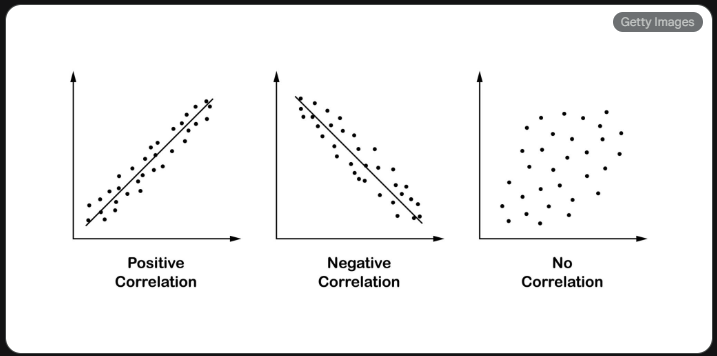

3. Dlaczego to jest kluczowe w ML?

Jako przyszły programista ML będziesz używał korelacji niemal codziennie w dwóch celach:

- A. Feature Selection (Selekcja cech)Jeśli cecha $X$ ma korelację bliską 0 ze zmienną celu $Y$, to prawdopodobnie jest nieprzydatna do modelu. Z kolei jeśli dwie cechy wejściowe ($X_1$ i $X_2$) mają korelację bliską 1 (np. temperatura w Celsjuszach i Fahrenheitach), to mamy do czynienia z multikolinearnością.Dlaczego to boli? Dublowanie informacji nie pomaga modelowi, a może sprawić, że będzie niestabilny i trudny do interpretacji (szczególnie w regresji liniowej).

- B. Macierz Korelacji (Heatmap)To zazwyczaj pierwszy wykres, jaki robisz w projekcie. Pozwala on błyskawicznie "zeskanować" wzrokiem dziesiątki zmiennych i zobaczyć, które z nich "trzymają się razem".4. Ważne rozróżnienie: Pearson vs SpearmanNa rozmowach o staż mogą Cię zapytać: "A co jeśli zależność jest nieliniowa?".

Korelacja Pearsona: Szuka tylko linii prostych. Jeśli dane układają się w kształt litery "U", Pearson może pokazać 0.Korelacja Spearmana: Opiera się na rangach (kolejności), a nie na wartościach. Wykrywa każdą zależność monotoniczną (czyli taką, gdzie $Y$ rośnie wraz z $X$, nawet jeśli nie po linii prostej).

#### Korelacje

1. Korelacja Pearsona ($r$)

To najpopularniejszy współczynnik korelacji. Mierzy on siłę i kierunek liniowego związku między dwiema zmiennymi ilościowymi.

- Zasada: Sprawdza, jak blisko punkty na wykresie znajdują się idealnej prostej.Zakres: Od $-1$ do $1$.$1$: Idealna korelacja dodatnia (jedna rośnie, druga rośnie proporcjonalnie).$0$: Brak związku liniowego (chaos).$-1$: Idealna korelacja ujemna (jedna rośnie, druga spada).

- Wzór:$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

- Kiedy stosować: Gdy Twoje dane są "grzeczne": mają rozkład normalny, nie mają dużych wartości odstających (outliers) i spodziewasz się, że zależność jest prostoliniowa (np. wzrost vs. waga).

2. Korelacja Spearmana ($\rho$)

To współczynnik oparty na rangach (kolejności), a nie na surowych wartościach. Jest to metoda nieparametryczna.

- Zasada: Zamiast brać pod uwagę, że "zarobiłeś 10 000 zł", Spearman widzi tylko, że "jesteś 1. na liście płac". Mierzy zależność monotoniczną (czy gdy jedna zmienna rośnie, to druga też – nieważne, czy w linii prostej, czy "schodkami").

- Zalety: * Odporna na wartości odstające (jeden miliarder nie zepsuje Ci korelacji zarobków w grupie).Działa dla danych porządkowych (np. oceny w szkole, stopnie zadowolenia).

- Wzór (uproszczony):$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$(gdzie $d$ to różnica między rangami, a $n$ to liczba obserwacji)

- Kiedy stosować: Gdy Twoje dane mają "dziwne" skoki, wartości skrajne lub gdy badasz np. korelację między pozycją w Google a liczbą kliknięć.

3. Regresja Liniowa (Podstawy)Podczas gdy korelacja mówi tylko "czy istnieje związek", regresja pozwala przewidywać przyszłość. Pozwala ona opisać zależność za pomocą równania prostej.

Model regresji prostej:

$$Y = \beta_0 + \beta_1 X + \epsilon$$

- $Y$: Zmienna zależna (to, co chcemy przewidzieć, np. sprzedaż).

- $X$: Zmienna niezależna (to, co zmieniamy, np. wydatki na reklamy).

- $\beta_0$: Intercept (punkt przecięcia z osią Y – ile sprzedajemy, gdy reklamy wynoszą 0).

- $\beta_1$: Współczynnik nachylenia (o ile wzrośnie sprzedaż, jeśli wydamy o 1 zł więcej na reklamy).

- $\epsilon$: Błąd losowy (to, czego model nie potrafi wyjaśnić).

Dlaczego to jest ważne?

Regresja pozwala wyliczyć Współczynnik Determinacji ($R^2$). Mówi on, w ilu procentach Twoje $X$ wyjaśnia zmienność $Y$. Jeśli $R^2 = 0.8$, to znaczy, że w 80% Twoja sprzedaż zależy od reklam, a reszta to inne czynniki (pogoda, humor klientów).

---

#### Centralne Twierdzenie Graniczne (CTG)

To najważniejsze twierdzenie w statystyce. Wyjaśnia ono, dlaczego Rozkład Normalny jest wszędzie, nawet jeśli oryginalne dane wcale go nie przypominają.

O co w tym chodzi?

Wyobraź sobie, że badasz czas spędzony w Twojej aplikacji. Większość ludzi wchodzi na 5 sekund, a nieliczni siedzą 2 godziny. Rozkład jest bardzo "brzydki" i niesymetryczny. CTG mówi tak:

- Jeśli zaczniesz pobierać z tej grupy wiele losowych próbek (np. po 100 osób każda) i dla każdej próbki obliczysz średnią, to te średnie – ułożone na wykresie – zawsze stworzą idealny, symetryczny Rozkład Normalny.

Dlaczego to jest "magiczne"?

- Niezależność od kształtu: Nie musisz wiedzieć, jaki rozkład ma Twoja populacja (czy jest skośna, czy dziwna).

- Przewidywalność: Skoro średnie z próbek zawsze tworzą dzwon, możemy użyć matematyki rozkładu normalnego, aby obliczyć prawdopodobieństwo błędu.

- Wymóg: Im większa próbka ($n$), tym bardziej dzwon jest "idealny". W statystyce przyjmuje się, że magiczną barierą jest zazwyczaj $n \ge 30$.

Jak to się łączy w A/B testach?

Gdy prowadzisz test A/B, tak naprawdę porównujesz dwie średnie (np. średni koszyk w grupie A i B).Dzięki Centralnemu Twierdzeniu Granicznemu wiemy, że te średnie "zachowują się" zgodnie z rozkładem normalnym. To pozwala nam obliczyć, czy różnica między grupami jest wynikiem Twojej genialnej zmiany, czy po prostu statystycznym szumem.Przykład z życia:Jeśli rzucisz kostką raz, masz rozkład płaski (każda liczba ma taką samą szansę). Ale jeśli rzucisz 100 razy i wyciągniesz średnią z tych rzutów, a potem powtórzysz to ćwiczenie 1000 razy – Twoje wyniki średnich skupią się wokół 3.5, tworząc piękny dzwon Gausa.

---

#### Symulacje Monte Carlo

Aby przeprowadzić symulację Monte Carlo w biznesie lub nauce, postępujemy według schematu:

1. Określenie modelu
Budujesz matematyczne równanie Twojego procesu. Na przykład:
Zysk = (Liczba klientów * Konwersja * Średni koszyk) - Koszty stałe.

2. Przypisanie rozkładów prawdopodobieństwa
To jest kluczowy moment. Zamiast wpisywać jedną wartość (np. "konwersja wyniesie 3%"), przyznajesz, że nie wiesz dokładnie, ile ona wyniesie. Definiujesz ją jako zakres:

- Konwersja: Rozkład normalny o średniej 3% i odchyleniu 0.5%.

- Średni koszyk: Rozkład log-normalny (bo większość kupuje mało, nieliczni bardzo dużo).

3. Wielokrotne powtarzanie (Symulacja)
Komputer losuje jedną wartość z każdego Twojego rozkładu i oblicza wynik. Następnie powtarza to 10 000, 100 000 lub milion razy. Każde powtórzenie to jeden "scenariusz" przyszłości.

4. Analiza wyników
Zamiast jednej liczby, otrzymujesz rozkład prawdopodobieństwa wyników.

Co nam to daje w praktyce?
Dzięki tej metodzie nie mówisz szefowi: „Zarobimy milion złotych”. Mówisz:

- „Mamy 90% szans, że zarobimy od 800 tys. do 1,2 mln zł”.

- „Istnieje tylko 5% ryzyka, że poniesiemy stratę”.

Zastosowania:

- Finanse: Wycena skomplikowanych instrumentów pochodnych lub ocena ryzyka portfela inwestycyjnego.

- Zarządzanie projektami: Szacowanie czasu zakończenia budowy (uwzględniając, że każda faza może się opóźnić).

- A/B Testing (Podejście Bayesowskie): Symulacje Monte Carlo służą do obliczenia prawdopodobieństwa, że wersja B jest lepsza od wersji A, biorąc pod uwagę dotychczas zebrane dane.

---

#### Metoda Bootstrap

Jak działa Bootstrapping? (Krok po kroku)

Wyobraź sobie, że masz próbkę $n$ użytkowników (np. 100 osób) i chcesz poznać średni czas ich sesji. Zamiast liczyć tylko jedną średnią i zgadywać, jaki jest błąd standardowy, robisz tak:

- Losujesz ze zwracaniem: Z Twojej oryginalnej grupy 100 osób losujesz nową grupę 100 osób. Ponieważ losujesz ze zwracaniem, ta sama osoba może trafić do nowej próbki kilka razy, a inna może nie trafić wcale.

- Liczysz statystykę: Obliczasz średnią dla tej nowej, „sztucznej” próbki.

- Powtarzasz to tysiące razy: Robisz tak np. 10 000 razy. Za każdym razem dostajesz nieco inną średnią.

- Budujesz rozkład: Teraz masz 10 000 średnich. Tworzysz z nich histogram.

Kluczowe pojęcie: Losowanie ze zwracaniem (With Replacement)

To najważniejszy techniczny aspekt. Gdybyś losował bez zwracania, każda Twoja próbka byłaby identyczna z oryginałem. Dzięki temu, że zwracasz elementy, każda „bootstrapowa” próbka jest nieco inna – to symuluje zmienność, jaką napotkałbyś w prawdziwym świecie, pobierając dane z natury.

Dlaczego to jest genialne?

1. Nie wymaga założeń o rozkładzie (Non-parametric)

- Tradycyjne wzory na błąd standardowy często zakładają, że dane mają rozkład normalny. Bootstrapping ma to gdzieś. Jeśli Twoje dane mają dwa garby, są skośne albo mają dziwne wartości odstające – bootstrapping i tak zadziała poprawnie.

2. Działa dla trudnych statystyk

- Bardzo łatwo jest wyprowadzić wzór na błąd standardowy dla średniej. Ale spróbuj to zrobić dla mediany, wariancji albo współczynnika korelacji. Matematyka staje się wtedy piekielnie trudna. Bootstrapping rozwiązuje to brutalną siłą obliczeniową – po prostu symulujesz to 10 000 razy i patrzysz, co wyszło.

3. Szacowanie przedziałów ufności

- Mając 10 000 wyników z symulacji, możesz łatwo powiedzieć: „95% moich wyników mieści się między X a Y”. To jest Twój 95-procentowy przedział ufności.

Przykład praktyczny (Data Science)

Wyobraź sobie, że trenujesz model regresji liniowej. Chcesz wiedzieć, jak stabilny jest współczynnik nachylenia ($\beta_1$).

- Zamiast ufać jednemu modelowi, robisz bootstrap: trenujesz 1000 modeli na różnych próbkach bootstrapowych.

- Dostajesz 1000 różnych wartości $\beta_1$.

- Jeśli te wartości są do siebie bardzo zbliżone, Twój model jest stabilny. Jeśli skaczą od Sasa do Lasa – Twoje dane są zbyt szumiące, by wyciągać wnioski.

Kiedy Bootstrapping zawodzi?

Choć to potężne narzędzie, ma swoje ograniczenia:

- Bardzo małe próbki: Jeśli w Twoim oryginale jest tylko 5 osób, bootstrapping nie wyczaruje informacji, której tam nie ma. Błąd będzie ogromny.

- Dane zależne (szeregi czasowe): W danych giełdowych czy pogodowych dzisiejszy wynik zależy od wczorajszego. Zwykły bootstrapping (losowe mieszanie dni) zniszczy tę strukturę. Stosuje się wtedy specjalny Block Bootstrapping.

---

---
---
---

### Wszystkie najważniejsze informacje o wykresach

